# Phase 3B — Topological Graph Analysis of NaPi2b
**Version:** 2.0 | **Date:** 2026-04  
**Input:** `phase3a_exports/`  
**Output:** `phase3b_outputs/`

## Pipeline
1. Load & validate Phase3A exports  
2. Build consensus `nx.Graph` (normal / tumor)  
3. QC of the graph  
4. Global centrality metrics  
4b. Regional subgraph analysis (ECD & epitope: contact profiles, contact maps, hotspots)  
5. Statistical tests (MWU, FDR-BH, Cohen's d, Bootstrap CI)  
6. Community detection (Louvain, NMI, ARI, Fisher enrichment)  
7. Allosteric pathways  
8. Protein–lipid & protein–glycan proximity  
9. Publication-quality visualisations (ECD + epitope, z-score heatmap)  
10. Export all artefacts  


In [ ]:
import sys, subprocess
PACKAGES = ["networkx>=3.0","scipy","statsmodels","scikit-learn","seaborn","matplotlib","pandas","numpy","tqdm"]
for pkg in PACKAGES:
    try:
        import importlib; importlib.import_module(pkg.split('>=')[0].replace('-','_')); print(f'OK  {pkg}')
    except ImportError:
        print(f'Installing {pkg}...'); subprocess.run([sys.executable,'-m','pip','install','-q',pkg],check=False)
print('\nDependencies ready.')

OK  networkx>=3.0
Installing python-louvain...
OK  scipy
OK  statsmodels
Installing scikit-learn...
OK  seaborn
OK  matplotlib
OK  pandas
OK  numpy
OK  tqdm

Dependencies ready.


In [ ]:
import json, warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import seaborn as sns, networkx as nx
from scipy.stats import mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({"font.family":"sans-serif","font.size":11,"axes.titlesize":12,"axes.labelsize":11,"figure.dpi":150})
print('Imports OK.')

Imports OK.


In [ ]:
# Cell X. Auto-download Phase3A exports from Yandex Disk

import os, sys, time
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

# ---- Install / import yadisk (pin to stable 2.x) ----------------------------
try:
    import yadisk
    _ver = tuple(int(x) for x in yadisk.__version__.split('.')[:2])
    if _ver < (2, 0):
        raise ImportError('too old')
except (ImportError, AttributeError):
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'yadisk>=2.0,<3.0'], check=False)
    import yadisk

print(f'yadisk version: {yadisk.__version__}')

# ---- Yandex Disk settings ---------------------------------------------------
YADISK_BASE         = 'NAPI2B-ST-GNN'
YADISK_PHASE3A_ROOT = f'disk:/{YADISK_BASE}/results/phase3A'    # disk:/ prefix!
YADISK_EXPORTS_DIR  = f'{YADISK_PHASE3A_ROOT}/phase3aexports'

PROJECT_ROOT = Path('/content/NAPI2B-ST-GNN/results/phase3A')
EXPORT_DIR   = PROJECT_ROOT / 'phase3a_exports'

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Token ------------------------------------------------------------------
YANDEX_TOKEN = os.environ.get('YANDEX_TOKEN', None)

if IN_COLAB and not YANDEX_TOKEN:
    try:
        from google.colab import userdata
        YANDEX_TOKEN = userdata.get('YANDEX_TOKEN')
        print('YANDEX_TOKEN loaded from Colab Secrets.')
    except Exception:
        print('YANDEX_TOKEN not found in Colab Secrets.')

if not YANDEX_TOKEN:
    raise ValueError(
        'YANDEX_TOKEN не установлен. '
        'Добавь его в Colab Secrets или os.environ["YANDEX_TOKEN"].'
    )

# ---- Yandex client ----------------------------------------------------------
client = yadisk.Client(token=YANDEX_TOKEN)

if not client.check_token():
    raise PermissionError('YANDEX_TOKEN невалиден.')

info    = client.get_disk_info()
free_gb = (info.total_space - info.used_space) / 1024**3
print(f'Yandex Disk OK — free space {free_gb:.1f} GB')
print(f'Remote exports dir: {YADISK_EXPORTS_DIR}')

# ---- Files expected from Phase3A exports ------------------------------------
EXPECTED_EXPORT_FILES = [
    'phase3a_manifest.json',
    'residue_table_normal.csv',
    'residue_table_tumor.csv',
    'protein_contact_edges_undirected_normal.csv',
    'protein_contact_edges_undirected_tumor.csv',
    'lipid_nodes_normal.csv',
    'lipid_nodes_tumor.csv',
    'glycan_nodes_normal.csv',
    'glycan_nodes_tumor.csv',
]

def yadisk_download(remote_path: str, local_path: Path, overwrite: bool = False):
    '''Download one file; returns True on success, False on remote-not-found.'''
    if local_path.exists() and not overwrite:
        print(f'  cache  {local_path.name}')
        return True
    local_path.parent.mkdir(parents=True, exist_ok=True)
    print(f'  download  {remote_path}')
    t0 = time.time()
    try:
        client.download(remote_path, str(local_path))
    except yadisk.exceptions.PathNotFoundError:
        print(f'  NOT FOUND on Yandex Disk: {remote_path}')
        return False
    except Exception as e:
        print(f'  ERROR  {local_path.name}: {e}')
        return False
    dt = time.time() - t0
    size_mb = local_path.stat().st_size / 1024**2
    print(f'  ok  {local_path.name}  {size_mb:.2f} MB  {dt:.1f} s')
    return True

# ---- Download all missing files (no exists() pre-check) --------------------
missing_remote = []; downloaded = []; cached = []

for fname in EXPECTED_EXPORT_FILES:
    local_file  = EXPORT_DIR / fname
    remote_file = f'{YADISK_EXPORTS_DIR}/{fname}'

    if local_file.exists():
        cached.append(fname)
        print(f'  cache  {fname}')
        continue

    ok = yadisk_download(remote_file, local_file, overwrite=False)
    if ok:
        downloaded.append(fname)
    else:
        missing_remote.append(remote_file)

print('=' * 60)
print('PHASE3A EXPORT AUTO-DOWNLOAD SUMMARY')
print('=' * 60)
print(f'  Cached locally : {len(cached)}')
print(f'  Downloaded     : {len(downloaded)}')
print(f'  Missing remote : {len(missing_remote)}')

if missing_remote:
    print('  Missing files on Yandex Disk:')
    for p in missing_remote: print(f'    - {p}')

# ---- Hard validation --------------------------------------------------------
required_now  = [EXPORT_DIR / f for f in EXPECTED_EXPORT_FILES]
missing_local = [str(p) for p in required_now if not p.exists()]

if missing_local:
    raise FileNotFoundError('\n'.join(missing_local))

print(f'\n✓ All Phase3A exports are available locally in {EXPORT_DIR}')


yadisk version: 2.1.0
YANDEX_TOKEN loaded from Colab Secrets.
Yandex Disk OK — free space 1776.7 GB
Remote exports dir: disk:/NAPI2B-ST-GNN/results/phase3A/phase3aexports
  cache  phase3a_manifest.json
  cache  residue_table_normal.csv
  cache  residue_table_tumor.csv
  cache  protein_contact_edges_undirected_normal.csv
  cache  protein_contact_edges_undirected_tumor.csv
  cache  lipid_nodes_normal.csv
  cache  lipid_nodes_tumor.csv
  cache  glycan_nodes_normal.csv
  cache  glycan_nodes_tumor.csv
PHASE3A EXPORT AUTO-DOWNLOAD SUMMARY
  Cached locally : 9
  Downloaded     : 0
  Missing remote : 0

✓ All Phase3A exports are available locally in /content/NAPI2B-ST-GNN/results/phase3A/phase3a_exports


In [ ]:
from pathlib import Path

OUT_DIR = Path('/content/phase3b_outputs')
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR: {OUT_DIR}')
print(f'FIG_DIR: {FIG_DIR}')

OUT_DIR: /content/phase3b_outputs
FIG_DIR: /content/phase3b_outputs/figures


## Cell 3 — Global parameters & FILE_MAP sync (v5.3)

Все пути к файлам Phase3A — **только через `export_file()` / `cond_file()`**.  
Добавлены: `alignment_result.json`, `nonprotein_nodes_*.csv`, `np_contact_edges_*.csv`.

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  Скачивание артефактов Phase3A с Яндекс Диска → Colab
#  Запускай один раз в начале сессии Phase3B
# ══════════════════════════════════════════════════════════════════
import yadisk as _yadisk, time
from pathlib import Path

YADISK_TOKEN  = ''  # или загрузится из Secrets ниже
try:
    from google.colab import userdata
    YADISK_TOKEN = userdata.get('YANDEX_TOKEN')
    print('Токен загружен из Colab Secrets.')
except Exception:
    pass

if not YADISK_TOKEN:
    raise ValueError('Задай YADISK_TOKEN')

YADISK_BASE   = 'NAPI2B-ST-GNN'
REMOTE_ROOT   = f'{YADISK_BASE}/results/phase3A'
REMOTE_EXPORT = f'{REMOTE_ROOT}/phase3aexports'

LOCAL_ROOT    = Path('/content/phase3a_outputs_scientific_v2')
LOCAL_EXPORT  = LOCAL_ROOT / 'phase3aexports'
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_EXPORT.mkdir(parents=True, exist_ok=True)

def _dl(client, remote, local):
    if local.exists():
        print(f'  [cache] {local.name}')
        return
    print(f'  ↓ {local.name} ...', end=' ', flush=True)
    t0 = time.time()
    client.download(remote, str(local))
    print(f'{local.stat().st_size/1024**2:.1f} MB  {time.time()-t0:.1f}s')

with _yadisk.Client(token=YADISK_TOKEN) as client:
    # 1. Корневые файлы (QC, alignment, edge_semantics)
    for fname in [
        'qc_status.json', 'qc_node_summary.csv', 'qc_edge_summary_detailed.csv',
        'qc_edge_summary.csv', 'qc_issues.csv', 'feature_provenance.json',
        'edge_semantics.json', 'alignment_result.json', 'dataset_manifest.json',
        'normal_qc_panels.png', 'tumor_qc_panels.png',
    ]:
        try:
            _dl(client, f'{REMOTE_ROOT}/{fname}', LOCAL_ROOT / fname)
        except Exception as e:
            print(f'  [skip] {fname}: {e}')

    # 2. Все файлы из phase3aexports/
    try:
        items = list(client.listdir(REMOTE_EXPORT))
        print(f'\nphase3aexports/ на диске: {len(items)} файлов')
        for item in items:
            if item.type == 'file':
                _dl(client, f'{REMOTE_EXPORT}/{item.name}', LOCAL_EXPORT / item.name)
    except Exception as e:
        print(f'[ERR] не удалось прочитать {REMOTE_EXPORT}: {e}')

print('\nГотово. Теперь запускай CELL 3B-FMAP.')

# Проверка
print(f'\nФайлов в phase3aexports/: {len(list(LOCAL_EXPORT.iterdir()))}')
for f in sorted(LOCAL_EXPORT.iterdir()):
    print(f'  {f.name}  {f.stat().st_size/1024:.0f} KB')

Токен загружен из Colab Secrets.
  [cache] qc_status.json
  [cache] qc_node_summary.csv
  [cache] qc_edge_summary_detailed.csv
  [cache] qc_edge_summary.csv
  [cache] qc_issues.csv
  [cache] feature_provenance.json
  [cache] edge_semantics.json
  [cache] alignment_result.json
  [cache] dataset_manifest.json
  [cache] normal_qc_panels.png
  [cache] tumor_qc_panels.png

phase3aexports/ на диске: 33 файлов
  [cache] config.yaml
  [cache] contact_edges_perframe_normal.parquet
  [cache] contact_edges_perframe_tumor.parquet
  [cache] dataset_manifest.json
  [cache] glycan_nodes_normal.csv
  [cache] glycan_nodes_tumor.csv
  [cache] heterograph_norm_normal.pt
  [cache] heterograph_norm_tumor.pt
  [cache] heterograph_normal.pt
  [cache] heterograph_tumor.pt
  [cache] lipid_nodes_normal.csv
  [cache] lipid_nodes_tumor.csv
  [cache] nonprotein_nodes_normal.csv
  [cache] nonprotein_nodes_tumor.csv
  [cache] normal_manifest.json
  [cache] normal_validation.json
  [cache] np_contact_edges_normal.csv

In [ ]:
# ── Загрузка конфига Phase3A ──────────────────────────────────────────
import yaml
config_path = LOCAL_EXPORT / 'config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    CONFIG = yaml.safe_load(f)

# ── Константы из манифеста / конфига ─────────────────────────────────
CONDITIONS        = MANIFEST["conditions"]                        # ['normal', 'tumor']
EDGE_TYPES        = [t[1] for t in MANIFEST["relation_types"]]   # только имена рёбер
EDGE_TYPE_INDEX   = MANIFEST.get("edge_type_index", {})
N_EDGE_TYPES      = len(EDGE_TYPES)
BACKBONE_CUTOFF_A = MANIFEST.get("backbone_cutoff_A", 4.5)
MIN_CONTACT_FREQ  = CONFIG.get("min_contact_freq", 0.30)
FRAME_FRAC        = CONFIG.get("frame_frac", 0.10)

## Step 1 — Load & validate Phase3A exports

In [ ]:
manifest_path = LOCAL_EXPORT / 'dataset_manifest.json'
with open(manifest_path,'r',encoding='utf-8') as f: MANIFEST = json.load(f)
REGIONS_OF_INTEREST = MANIFEST["regions_of_interest"]
EDGE_TYPES          = MANIFEST["relation_types"]
EDGE_TYPE_INDEX     = MANIFEST.get("edge_type_index", {})
N_EDGE_TYPES        = len(EDGE_TYPES)
BACKBONE_CUTOFF_A   = MANIFEST.get("backbone_cutoff_A", 4.5)
def _range_to_set(b): return set(range(int(b[0]), int(b[1])+1))
EPITOPE_RESIDS = _range_to_set(REGIONS_OF_INTEREST["epitope"])
ECD_RESIDS_ALL = _range_to_set(REGIONS_OF_INTEREST["ECD"])
ECD_ONLY       = ECD_RESIDS_ALL - EPITOPE_RESIDS
print('Manifest loaded:')
print(f'  regions_of_interest : {REGIONS_OF_INTEREST}')
print(f'  edge_types ({N_EDGE_TYPES}): {EDGE_TYPES}')
print(f'  backbone_cutoff_A   : {BACKBONE_CUTOFF_A}')
print(f'  EPITOPE_RESIDS      : {len(EPITOPE_RESIDS)} residues')
print(f'  ECD (excl. epitope) : {len(ECD_ONLY)} residues')

Manifest loaded:
  regions_of_interest : {'epitope': [311, 341], 'ECD': [234, 361], 'full_protein': None}
  edge_types (12): [['protein', 'backbone', 'protein'], ['protein', 'hbond', 'protein'], ['protein', 'disulfide', 'protein'], ['protein', 'vdw', 'protein'], ['protein', 'hydrophobic', 'protein'], ['protein', 'aromatic_pi', 'protein'], ['protein', 'cation_pi', 'protein'], ['protein', 'ionic', 'protein'], ['protein', 'salt_bridge', 'protein'], ['protein', 'protein_lipid', 'lipid'], ['protein', 'glycan_anchor', 'glycan'], ['protein', 'protein_glycan', 'glycan']]
  backbone_cutoff_A   : 4.5
  EPITOPE_RESIDS      : 31 residues
  ECD (excl. epitope) : 128 residues


In [ ]:
RESTABLE: Dict[str,pd.DataFrame] = {}
CONDITIONS = MANIFEST["conditions"]   # ['normal', 'tumor']
for cond in CONDITIONS:
    df = pd.read_csv(LOCAL_EXPORT/f'residue_table_{cond}.csv')
    df['is_glycosylated'] = df['isglycosylated'].astype(bool)
    RESTABLE[cond] = df
    print(f'[{cond}] {len(df)} residues | columns: {list(df.columns)}')
_all_resids  = set(RESTABLE['normal']['resid'].tolist())
OTHER_RESIDS = _all_resids - ECD_RESIDS_ALL - EPITOPE_RESIDS
print(f'\nEpitope            : {len(EPITOPE_RESIDS)} residues')
print(f'ECD (excl. epitope): {len(ECD_ONLY)} residues')
print(f'Other              : {len(OTHER_RESIDS)} residues')


[normal] 690 residues | columns: ['nodeidx', 'resid', 'resname', 'aa1', 'region', 'isglycosylated', 'label', 'condition', 'x_ca', 'y_ca', 'z_ca', 'is_glycosylated']
[tumor] 690 residues | columns: ['nodeidx', 'resid', 'resname', 'aa1', 'region', 'isglycosylated', 'label', 'condition', 'x_ca', 'y_ca', 'z_ca', 'is_glycosylated']

Epitope            : 31 residues
ECD (excl. epitope): 97 residues
Other              : 562 residues


In [ ]:
def validate_residue_table(df, cond):
    errors = []
    for resid in EPITOPE_RESIDS:
        rows = df[df['resid']==resid]
        if len(rows) and (rows['region']!='epitope').any():
            errors.append(f'  resid={resid} expected epitope, got {rows["region"].values}')
    for resid in ECD_ONLY:
        rows = df[df['resid']==resid]
        if len(rows) and (rows['region']!='ECD').any():
            errors.append(f'  resid={resid} expected ECD, got {rows["region"].values}')
    dup = df[df.duplicated('resid')]
    if len(dup): errors.append(f'  Duplicate resids: {dup["resid"].tolist()}')
    if errors: print(f'[{cond}] VALIDATION WARNINGS:'); [print(e) for e in errors]
    else: print(f'[{cond}] OK — region labels valid.')
for cond in CONDITIONS: validate_residue_table(RESTABLE[cond], cond)


[normal] VALIDATION WARNINGS:
  resid=311 expected ECD, got ['epitope']
  resid=312 expected ECD, got ['epitope']
  resid=313 expected ECD, got ['epitope']
  resid=314 expected ECD, got ['epitope']
  resid=315 expected ECD, got ['epitope']
  resid=316 expected ECD, got ['epitope']
  resid=317 expected ECD, got ['epitope']
  resid=318 expected ECD, got ['epitope']
  resid=319 expected ECD, got ['epitope']
  resid=320 expected ECD, got ['epitope']
  resid=321 expected ECD, got ['epitope']
  resid=322 expected ECD, got ['epitope']
  resid=323 expected ECD, got ['epitope']
  resid=324 expected ECD, got ['epitope']
  resid=325 expected ECD, got ['epitope']
  resid=326 expected ECD, got ['epitope']
  resid=327 expected ECD, got ['epitope']
  resid=328 expected ECD, got ['epitope']
  resid=329 expected ECD, got ['epitope']
  resid=330 expected ECD, got ['epitope']
  resid=331 expected ECD, got ['epitope']
  resid=332 expected ECD, got ['epitope']
  resid=333 expected ECD, got ['epitope']
  re

In [ ]:
EDGES: Dict[str,pd.DataFrame] = {}
for cond in CONDITIONS:
    df = pd.read_csv(LOCAL_EXPORT/f'protein_contact_edges_undirected_{cond}.csv')
    df = df[df['src']<df['dst']].reset_index(drop=True)
    EDGES[cond] = df
    print(f'{cond}: {len(df)} edges total')
    print(df.groupby('edgetype')['contactfreq'].count().rename('n_edges').to_string()); print()

normal: 4171 edges total
edgetype
aromatic_pi      25
backbone        689
cation_pi         2
hbond            58
hydrophobic      99
ionic            21
salt_bridge      14
vdw            3263

tumor: 4240 edges total
edgetype
aromatic_pi      27
backbone        689
cation_pi         2
hbond            54
hydrophobic      99
ionic            23
salt_bridge      16
vdw            3330



In [ ]:
rows = []
for cond in CONDITIONS:
    rt = RESTABLE[cond]
    rows.append({'Condition':cond,'n_residues':len(rt),'n_edges':len(EDGES[cond]),
                 'n_edge_types':EDGES[cond]['edgetype'].nunique(),
                 'n_epitope':(rt['region']=='epitope').sum(),
                 'n_ECD':(rt['region']=='ECD').sum(),
                 'n_glycosylated':rt['is_glycosylated'].sum()})
print('=== Step 1 — Input summary ===')
print(pd.DataFrame(rows).set_index('Condition').to_string())

=== Step 1 — Input summary ===
           n_residues  n_edges  n_edge_types  n_epitope  n_ECD  n_glycosylated
Condition                                                                     
normal            690     4171             8         31     97               2
tumor             690     4240             8         31     97               2


### Step 1b — Load non-protein nodes & contacts

Загружает `nonprotein_nodes_{cond}.csv` и `np_contact_edges_{cond}.csv`.  
Добавляет столбец `n_np_contacts` в `RESTABLE`.

In [ ]:
# =====================================================================
# CELL 3B-NPN  ·  Load non-protein nodes + contacts (Step 1b)
#                 Вставить ПОСЛЕ ячейки загрузки EDGES (Cell 10, Step 1)
# =====================================================================

import pandas as pd
import numpy as np

NONPROTEIN_NODES: dict = {}
NP_CONTACT_EDGES: dict = {}

for cond in CONDITIONS:
    np_node_path = LOCAL_EXPORT / f"nonprotein_nodes_{cond}.csv"
    np_edge_path = LOCAL_EXPORT / f"np_contact_edges_{cond}.csv"

    if np_node_path.exists():
        NONPROTEIN_NODES[cond] = pd.read_csv(np_node_path)
    else:
        print(f"[NPN] WARNING: {np_node_path.name} not found — empty DataFrame used")
        NONPROTEIN_NODES[cond] = pd.DataFrame()

    if np_edge_path.exists():
        NP_CONTACT_EDGES[cond] = pd.read_csv(np_edge_path)
    else:
        print(f"[NPN] WARNING: {np_edge_path.name} not found — empty DataFrame used")
        NP_CONTACT_EDGES[cond] = pd.DataFrame()

    npdf  = NONPROTEIN_NODES[cond]
    npedg = NP_CONTACT_EDGES[cond]

    lipid_n  = int((npdf["node_type"] == "lipid").sum())  if len(npdf) else 0
    glycan_n = int((npdf["node_type"] == "glycan").sum()) if len(npdf) else 0
    ligand_n = int((npdf["node_type"] == "ligand").sum()) if len(npdf) else 0

    print(f"[NPN] {cond}: lipid={lipid_n}  glycan={glycan_n}  "
          f"ligand={ligand_n}  contacts={len(npedg)}")

# ── Per-residue non-protein neighbour count ──────────────────────────
# Добавляет столбец n_np_contacts в RESTABLE[cond] для downstream анализа
for cond in CONDITIONS:
    npedg = NP_CONTACT_EDGES[cond]
    if len(npedg) == 0:
        RESTABLE[cond]["n_np_contacts"] = 0
        continue
    counts = (npedg.groupby("protein_resid")
                   .size()
                   .rename("n_np_contacts")
                   .reset_index())
    RESTABLE[cond] = RESTABLE[cond].merge(counts, left_on="resid",
                                            right_on="protein_resid", how="left")
    RESTABLE[cond]["n_np_contacts"] = (RESTABLE[cond]["n_np_contacts"]
                                        .fillna(0).astype(int))
    RESTABLE[cond].drop(columns=["protein_resid"], errors="ignore", inplace=True)

print("[NPN] n_np_contacts added to RESTABLE for each condition.")


[NPN] normal: lipid=800  glycan=84  ligand=0  contacts=298
[NPN] tumor: lipid=788  glycan=60  ligand=0  contacts=406
[NPN] n_np_contacts added to RESTABLE for each condition.


## Step 2 — Build consensus nx.Graph

In [ ]:
def build_graph(edges_df, residue_df, min_freq=MIN_CONTACT_FREQ):
    G = nx.Graph()
    for _, row in residue_df.iterrows():
        G.add_node(int(row['resid']), resid=int(row['resid']), resname=str(row['resname']),
                   aa1=str(row.get('aa1', '')), region=str(row['region']),
                   is_glycosylated=bool(row['is_glycosylated']), node_idx=int(row['nodeidx']))
    for _, e in edges_df[edges_df['contactfreq'] >= min_freq].iterrows():
        G.add_edge(int(e['src']), int(e['dst']),
                   contact_freq=float(e['contactfreq']),
                   mean_dist=float(e['meandist']),
                   std_dist=float(e.get('std_dist', 0.0)),
                   edge_type=str(e['edgetype']),
                   edge_type_index=int(e.get('edge_type_index', 0)))
    return G

In [ ]:
GRAPHS: Dict[str, nx.Graph] = {}
for cond in CONDITIONS:
    G = build_graph(EDGES[cond], RESTABLE[cond])
    GRAPHS[cond] = G
    print(f'{cond}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, density={nx.density(G):.5f}')

normal: 691 nodes, 3263 edges, density=0.01369
tumor: 691 nodes, 3331 edges, density=0.01397


## Step 3 — QC

In [ ]:
def qc_graph(G, cond):
    n, m = G.number_of_nodes(), G.number_of_edges()
    if n == 0:
        print(f'\n=== QC: {cond} === EMPTY GRAPH'); return {}

    # Подсчёт рёбер по типу
    etc = {}
    for _, _, d in G.edges(data=True):
        et = d.get('edge_type', 'unknown')
        etc[et] = etc.get(et, 0) + 1

    # Backbone check
    bb = etc.get('backbone', 0)
    exp_bb = n - 1
    bb_ok = abs(bb - exp_bb) <= max(5, int(0.02 * n))

    # Компоненты связности
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    giant = len(comps[0]) / n

    print(f'\n=== QC: {cond} ===')
    print(f'  Nodes: {n}  Edges: {m}  Density: {nx.density(G):.5f}')
    print('  Edges per type:')
    for et, cnt in sorted(etc.items()):
        print(f'    {et:20s}: {cnt}')
    print(f'  Backbone: {bb} (expected≈{exp_bb}) {"OK" if bb_ok else "WARNING"}')
    print(f'  Components: {len(comps)}  Giant: {giant:.1%} {"" if giant >= 0.95 else "⚠ WARNING < 95%"}')

    if giant < 0.95:
        warnings.warn(f'[{cond}] Giant component {giant:.1%} < 95%!')

    return dict(
        n_nodes=n, n_edges=m, density=nx.density(G),
        edge_type_counts=etc, n_components=len(comps), giant_frac=giant
    )

QC_STATS = {cond: qc_graph(GRAPHS[cond], cond) for cond in CONDITIONS}


=== QC: normal ===
  Nodes: 691  Edges: 3263  Density: 0.01369
  Edges per type:
    aromatic_pi         : 21
    backbone            : 689
    cation_pi           : 2
    hydrophobic         : 85
    ionic               : 7
    salt_bridge         : 14
    vdw                 : 2445
  Backbone: 689 (expected≈690) OK
  Components: 2  Giant: 99.9% 

=== QC: tumor ===
  Nodes: 691  Edges: 3331  Density: 0.01397
  Edges per type:
    aromatic_pi         : 24
    backbone            : 689
    cation_pi           : 2
    hydrophobic         : 85
    ionic               : 7
    salt_bridge         : 16
    vdw                 : 2508
  Backbone: 689 (expected≈690) OK
  Components: 2  Giant: 99.9% 


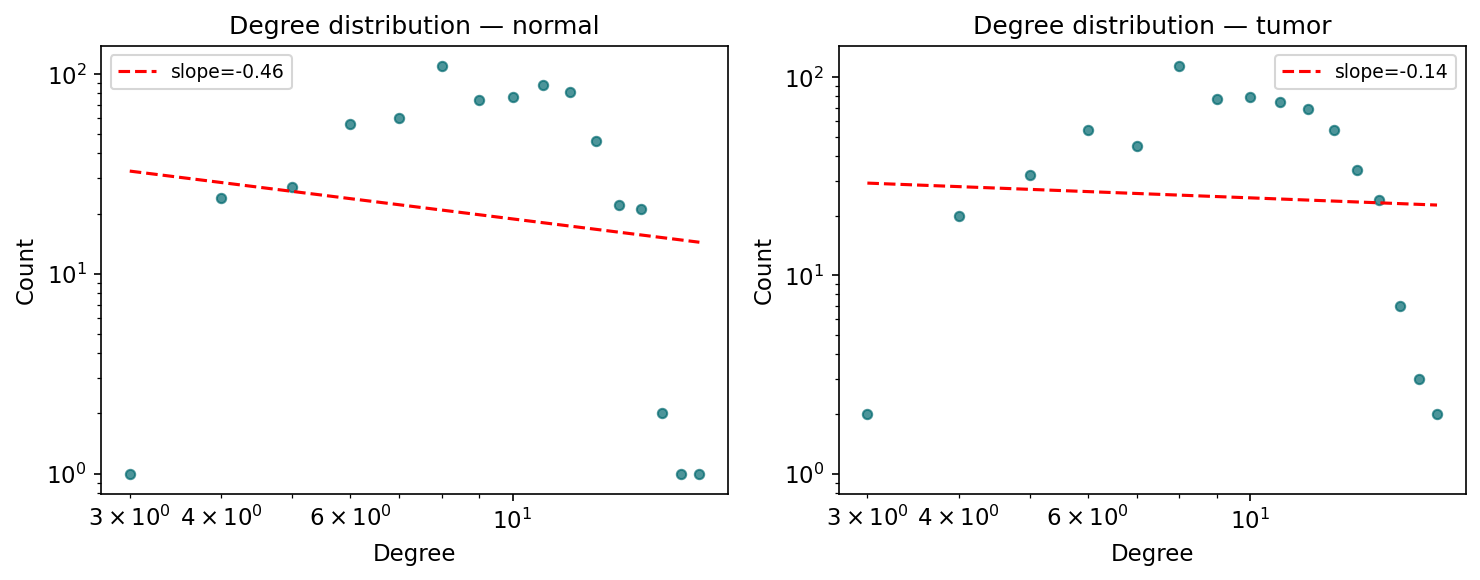

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax,cond in zip(axes,CONDITIONS):
    degrees=[d for _,d in GRAPHS[cond].degree()]
    vals,cnts=np.unique(degrees,return_counts=True)
    ax.scatter(vals,cnts,s=20,alpha=0.7,color='#01696f')
    mask=(vals>0)&(cnts>0)
    if mask.sum()>2:
        coeffs=np.polyfit(np.log(vals[mask]),np.log(cnts[mask]),1)
        xf=np.linspace(vals[mask].min(),vals[mask].max(),100)
        ax.plot(xf,np.exp(np.polyval(coeffs,np.log(xf))),'r--',lw=1.5,label=f'slope={coeffs[0]:.2f}'); ax.legend(fontsize=9)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('Degree'); ax.set_ylabel('Count')
    ax.set_title(f'Degree distribution — {cond}')
plt.tight_layout(); plt.savefig(FIG_DIR/'qc_degree_distribution.png',dpi=300,bbox_inches='tight'); plt.show()

## Step 4 — Global centrality metrics

In [ ]:
def compute_centrality(G, cond):
    nodes=sorted(G.nodes())
    print(f'  [{cond}] betweenness...',end=' ',flush=True)
    betw=nx.betweenness_centrality(G,weight='contact_freq',normalized=True)
    print('closeness...',end=' ',flush=True)
    clos=nx.closeness_centrality(G,distance=lambda u,v,d:1.0/max(d['contact_freq'],1e-9))
    print('eigenvector...',end=' ',flush=True)
    try: eig=nx.eigenvector_centrality(G,max_iter=1000,weight='contact_freq')
    except nx.PowerIterationFailedConvergence: eig=nx.pagerank(G,weight='contact_freq'); print('(fallback→pagerank)',end=' ')
    print('pagerank...',end=' ',flush=True)
    pr=nx.pagerank(G,weight='contact_freq'); kc=nx.core_number(G); print('done.')
    rt=RESTABLE[cond].set_index('resid'); rows=[]
    for resid in nodes:
        r=rt.loc[resid] if resid in rt.index else {}
        strength=sum(d.get('contact_freq',0) for _,_,d in G.edges(resid,data=True))
        rows.append({'resid':resid,'node_idx':int(r.get('node_idx',-1)),'resname':r.get('resname',''),
                     'region':r.get('region','other'),'is_glycosylated':bool(r.get('is_glycosylated',False)),
                     'degree':G.degree(resid),'strength':round(strength,6),
                     'betweenness':round(betw.get(resid,0.0),8),'closeness':round(clos.get(resid,0.0),8),
                     'eigenvector':round(eig.get(resid,0.0),8),'pagerank':round(pr.get(resid,0.0),8),
                     'k_core':int(kc.get(resid,0))})
    return pd.DataFrame(rows)
CENTRALITY: Dict[str,pd.DataFrame]={}
METRICS=['degree','strength','betweenness','closeness','eigenvector','pagerank','k_core']
for cond in CONDITIONS:
    print(f'Computing centrality for {cond}...'); CENTRALITY[cond]=compute_centrality(GRAPHS[cond],cond)
print('Centrality tables ready.')


Computing centrality for normal...
  [normal] betweenness... closeness... eigenvector... pagerank... done.
Computing centrality for tumor...
  [tumor] betweenness... closeness... eigenvector... pagerank... done.
Centrality tables ready.


In [ ]:
cn=CENTRALITY['normal'].set_index('resid')[METRICS]
ct=CENTRALITY['tumor'].set_index('resid')[METRICS]
delta_vals=ct.subtract(cn).reset_index()
meta_cols=CENTRALITY['normal'][['resid','resname','region','is_glycosylated']]
DELTA_DF=delta_vals.merge(meta_cols,on='resid',how='left')
print('Top 5 residues by |Δbetweenness| (tumor − normal):')
print(DELTA_DF.nlargest(5,'betweenness')[['resid','resname','region','betweenness']].to_string(index=False))

Top 5 residues by |Δbetweenness| (tumor − normal):
 resid resname region  betweenness
    53     SER  other     0.144351
   606     VAL  other     0.139867
   608     SER  other     0.120065
   280     LYS    ECD     0.116241
   344     LYS    ECD     0.115593


## Step 4b — Regional subgraph analysis
### 4b-1  Subgraph metrics (ECD & epitope)

In [ ]:
def region_resids_from_table(df, region): return df[df['region']==region]['resid'].tolist()
SUB_STATS={}
for cond in CONDITIONS:
    rt,G=RESTABLE[cond],GRAPHS[cond]
    for region in ['ECD','epitope']:
        resids=region_resids_from_table(rt,region); Gsub=G.subgraph(resids)
        n,m=Gsub.number_of_nodes(),Gsub.number_of_edges(); cc_=list(nx.connected_components(Gsub))
        SUB_STATS[(cond,region)]=dict(n_nodes=n,n_edges=m,density=nx.density(Gsub) if n>1 else 0.0,n_components=len(cc_))
        print(f'  {cond}/{region:8s}: nodes={n}, edges={m}, density={nx.density(Gsub):.4f}, components={len(cc_)}')


  normal/ECD     : nodes=97, edges=355, density=0.0762, components=1
  normal/epitope : nodes=31, edges=115, density=0.2473, components=1
  tumor/ECD     : nodes=97, edges=366, density=0.0786, components=1
  tumor/epitope : nodes=31, edges=123, density=0.2645, components=1


### 4b-2  Centrality within subgraphs (ECD & epitope)

In [ ]:
CENTRALITY_SUB: Dict[str,pd.DataFrame]={}
for cond in CONDITIONS:
    rt,G=RESTABLE[cond],GRAPHS[cond]
    for region in ['ECD','epitope']:
        resids=region_resids_from_table(rt,region); Gsub=G.subgraph(resids).copy()
        if Gsub.number_of_nodes()<3: continue
        try:
            betw=nx.betweenness_centrality(Gsub,weight='contact_freq',normalized=True)
            eig=nx.eigenvector_centrality(Gsub,max_iter=500,weight='contact_freq')
        except Exception:
            betw={nd:0.0 for nd in Gsub.nodes()}; eig={nd:0.0 for nd in Gsub.nodes()}
        clos=nx.closeness_centrality(Gsub,distance=lambda u,v,d:1.0/max(d['contact_freq'],1e-9))
        rows=[]
        for resid in sorted(Gsub.nodes()):
            r=rt.set_index('resid').loc[resid]
            rows.append({'resid':resid,'resname':r['resname'],'region':region,'condition':cond,
                         'betweenness':round(betw.get(resid,0.0),8),'closeness':round(clos.get(resid,0.0),8),
                         'eigenvector':round(eig.get(resid,0.0),8),'degree_sub':Gsub.degree(resid)})
        key=f'{region}_{cond}'; CENTRALITY_SUB[key]=pd.DataFrame(rows)
        print(f'  {key}: {len(rows)} rows computed')


  ECD_normal: 97 rows computed
  epitope_normal: 31 rows computed
  ECD_tumor: 97 rows computed
  epitope_tumor: 31 rows computed


### 4b-3  Inter-region edge matrix

In [ ]:
def inter_region_matrix(G, rt):
    r2r=dict(zip(rt['resid'],rt['region'])); regions=['epitope','ECD','other']
    cm={r:{c:0 for c in regions} for r in regions}; fm={r:{c:0.0 for c in regions} for r in regions}
    for u,v,d in G.edges(data=True):
        ru=r2r.get(u,'other'); rv=r2r.get(v,'other')
        cm[ru][rv]+=1; cm[rv][ru]+=1; fm[ru][rv]+=d.get('contact_freq',0.0); fm[rv][ru]+=d.get('contact_freq',0.0)
    for r in regions: cm[r][r]//=2; fm[r][r]/=2
    return pd.DataFrame(cm,index=regions)[regions], pd.DataFrame(fm,index=regions)[regions]
IR_COUNT,IR_FREQ={},{}
for cond in CONDITIONS: IR_COUNT[cond],IR_FREQ[cond]=inter_region_matrix(GRAPHS[cond],RESTABLE[cond])
IR_COUNT_DELTA=IR_COUNT['tumor']-IR_COUNT['normal']
IR_FREQ_DELTA =IR_FREQ['tumor'] -IR_FREQ['normal']
print('Inter-region edge count — normal:'); print(IR_COUNT['normal'].to_string())
print('\nDelta (tumor − normal):'); print(IR_COUNT_DELTA.to_string())


Inter-region edge count — normal:
         epitope  ECD  other
epitope      115   17      0
ECD           17  355    139
other          0  139   2637

Delta (tumor − normal):
         epitope  ECD  other
epitope        8    0      0
ECD            0   11      7
other          0    7     42


### 4b-4a  Contact frequency profile — Epitope

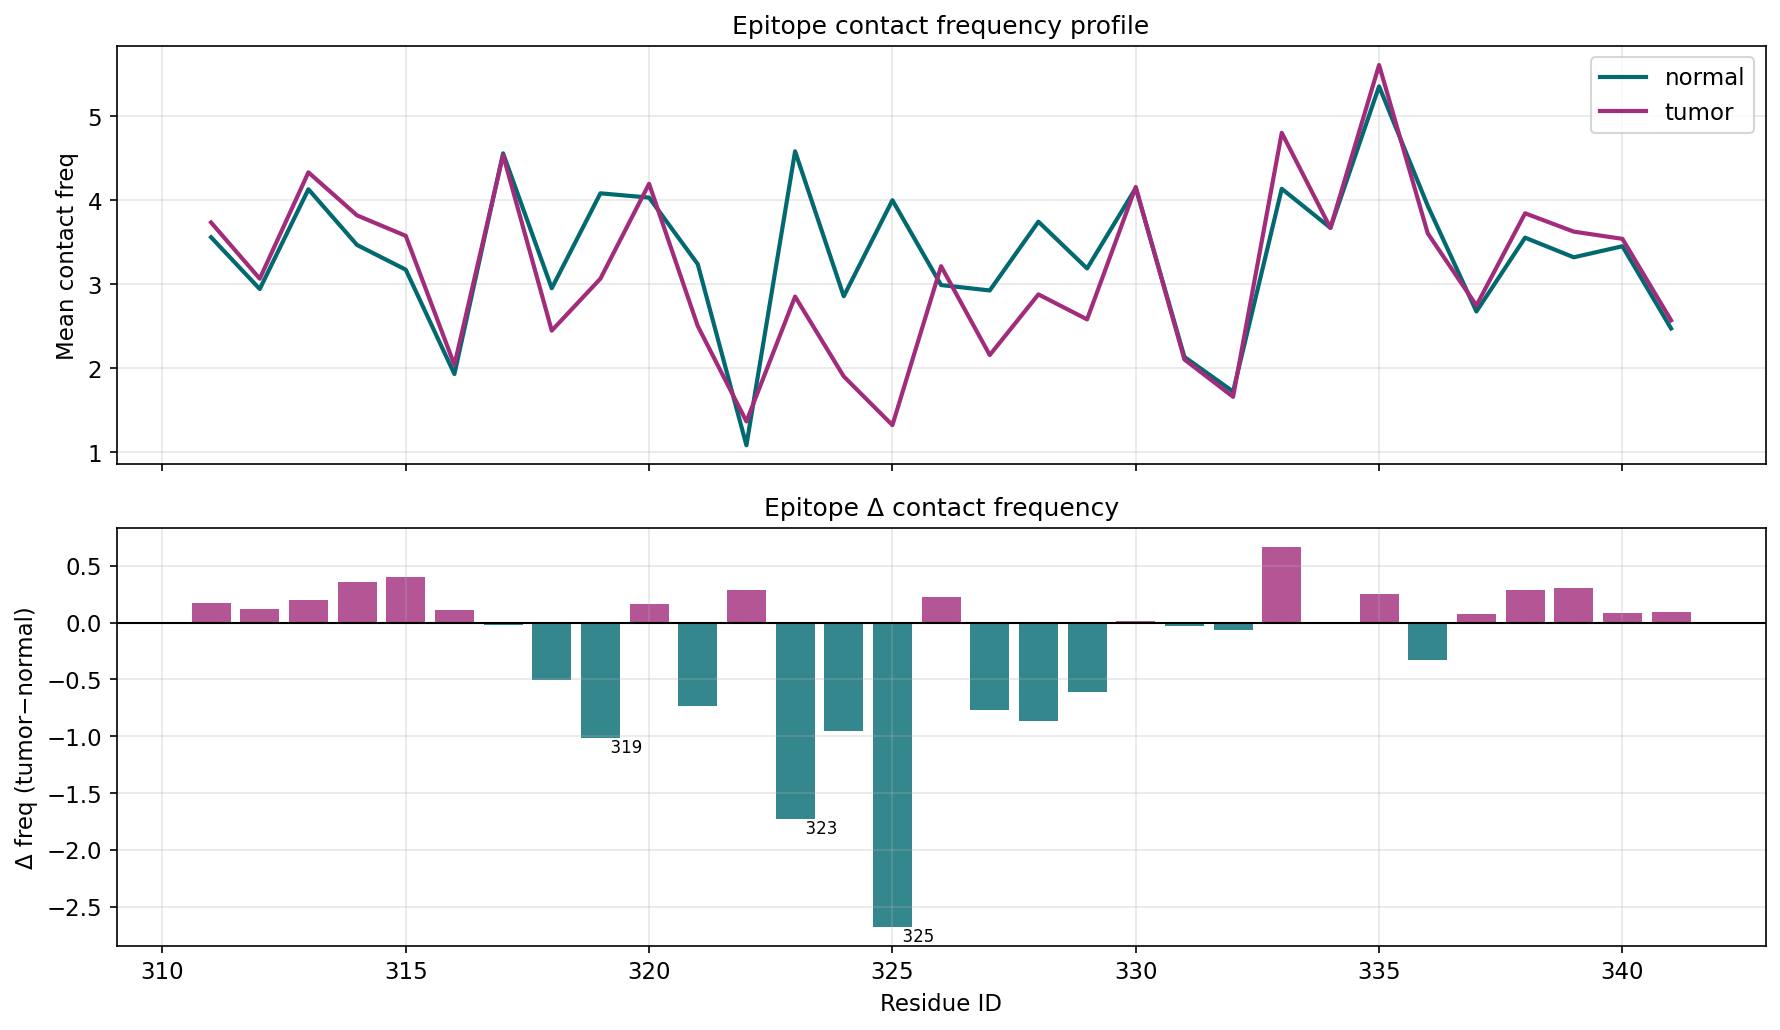

In [ ]:
def contact_profile(G, resids):
    return {r:(float(np.mean([d['contact_freq'] for _,_,d in G.edges(r,data=True)])) if r in G and G.degree(r)>0 else 0.0) for r in resids}

epitope_resids_sorted=sorted(EPITOPE_RESIDS)
PROF_EP={cond: contact_profile(GRAPHS[cond],epitope_resids_sorted) for cond in CONDITIONS}
prof_ep_n=np.array([PROF_EP['normal'].get(r,0.0) for r in epitope_resids_sorted])
prof_ep_t=np.array([PROF_EP['tumor'].get(r,0.0)  for r in epitope_resids_sorted])
prof_ep_d=prof_ep_t-prof_ep_n

fig,axes=plt.subplots(2,1,figsize=(12,7),sharex=True)
ax=axes[0]
ax.plot(epitope_resids_sorted,prof_ep_n,color='#01696f',lw=2,label='normal')
ax.plot(epitope_resids_sorted,prof_ep_t,color='#a12c7b',lw=2,label='tumor')
ax.set_ylabel('Mean contact freq'); ax.set_title('Epitope contact frequency profile'); ax.legend(); ax.grid(alpha=0.3)
ax=axes[1]; colors_ep=['#a12c7b' if d>0 else '#01696f' for d in prof_ep_d]
ax.bar(epitope_resids_sorted,prof_ep_d,color=colors_ep,edgecolor='none',alpha=0.8); ax.axhline(0,color='black',lw=1)
for idx in np.argsort(np.abs(prof_ep_d))[::-1][:3]:
    ax.annotate(f'  {epitope_resids_sorted[idx]}',xy=(epitope_resids_sorted[idx],prof_ep_d[idx]),
                fontsize=8,va='bottom' if prof_ep_d[idx]>=0 else 'top')
ax.set_xlabel('Residue ID'); ax.set_ylabel('Δ freq (tumor−normal)'); ax.set_title('Epitope Δ contact frequency'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR/'epitope_contact_profile.png',dpi=300,bbox_inches='tight'); plt.show()

### 4b-4b  Contact frequency profile — ECD (excl. epitope)

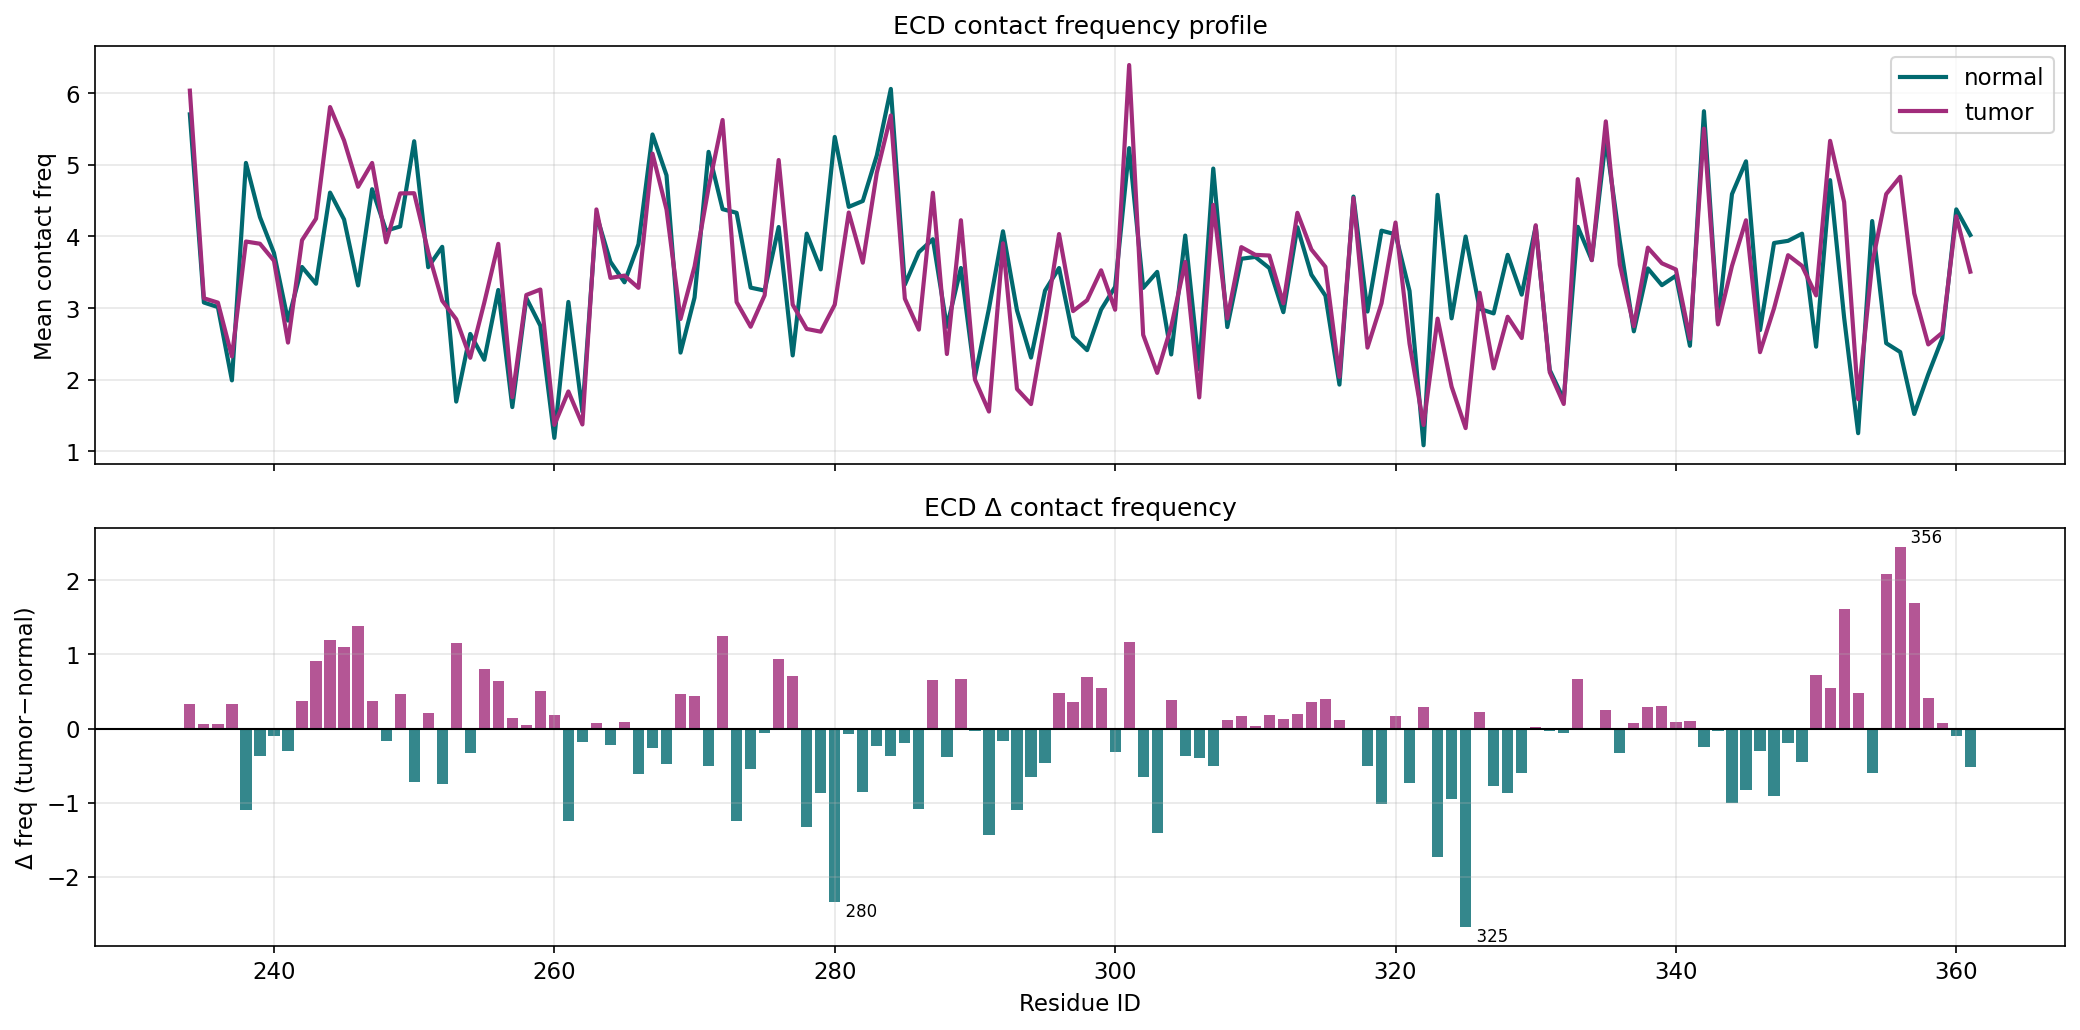

Contact profile CSVs saved.


In [ ]:
ecd_only_sorted=sorted(ECD_RESIDS_ALL)
PROF_ECD={cond: contact_profile(GRAPHS[cond],ecd_only_sorted) for cond in CONDITIONS}
prof_ecd_n=np.array([PROF_ECD['normal'].get(r,0.0) for r in ecd_only_sorted])
prof_ecd_t=np.array([PROF_ECD['tumor'].get(r,0.0)  for r in ecd_only_sorted])
prof_ecd_d=prof_ecd_t-prof_ecd_n

fig,axes=plt.subplots(2,1,figsize=(14,7),sharex=True)
ax=axes[0]
ax.plot(ecd_only_sorted,prof_ecd_n,color='#01696f',lw=2,label='normal')
ax.plot(ecd_only_sorted,prof_ecd_t,color='#a12c7b',lw=2,label='tumor')
ax.set_ylabel('Mean contact freq'); ax.set_title('ECD contact frequency profile'); ax.legend(); ax.grid(alpha=0.3)
ax=axes[1]; colors_ecd=['#a12c7b' if d>0 else '#01696f' for d in prof_ecd_d]
ax.bar(ecd_only_sorted,prof_ecd_d,color=colors_ecd,edgecolor='none',alpha=0.8); ax.axhline(0,color='black',lw=1)
for idx in np.argsort(np.abs(prof_ecd_d))[::-1][:3]:
    ax.annotate(f'  {ecd_only_sorted[idx]}',xy=(ecd_only_sorted[idx],prof_ecd_d[idx]),
                fontsize=8,va='bottom' if prof_ecd_d[idx]>=0 else 'top')
ax.set_xlabel('Residue ID'); ax.set_ylabel('Δ freq (tumor−normal)'); ax.set_title('ECD Δ contact frequency'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR/'ecd_contact_profile.png',dpi=300,bbox_inches='tight'); plt.show()

pd.DataFrame({'resid':epitope_resids_sorted,'mean_freq_normal':prof_ep_n,'mean_freq_tumor':prof_ep_t,'delta':prof_ep_d}
             ).to_csv(OUT_DIR/'epitope_contact_profile.csv',index=False)
pd.DataFrame({'resid':ecd_only_sorted,'mean_freq_normal':prof_ecd_n,'mean_freq_tumor':prof_ecd_t,'delta':prof_ecd_d}
             ).to_csv(OUT_DIR/'ecd_contact_profile.csv',index=False)
print('Contact profile CSVs saved.')


### 4b-5a  Contact maps — Epitope (normal | tumor | Δ)

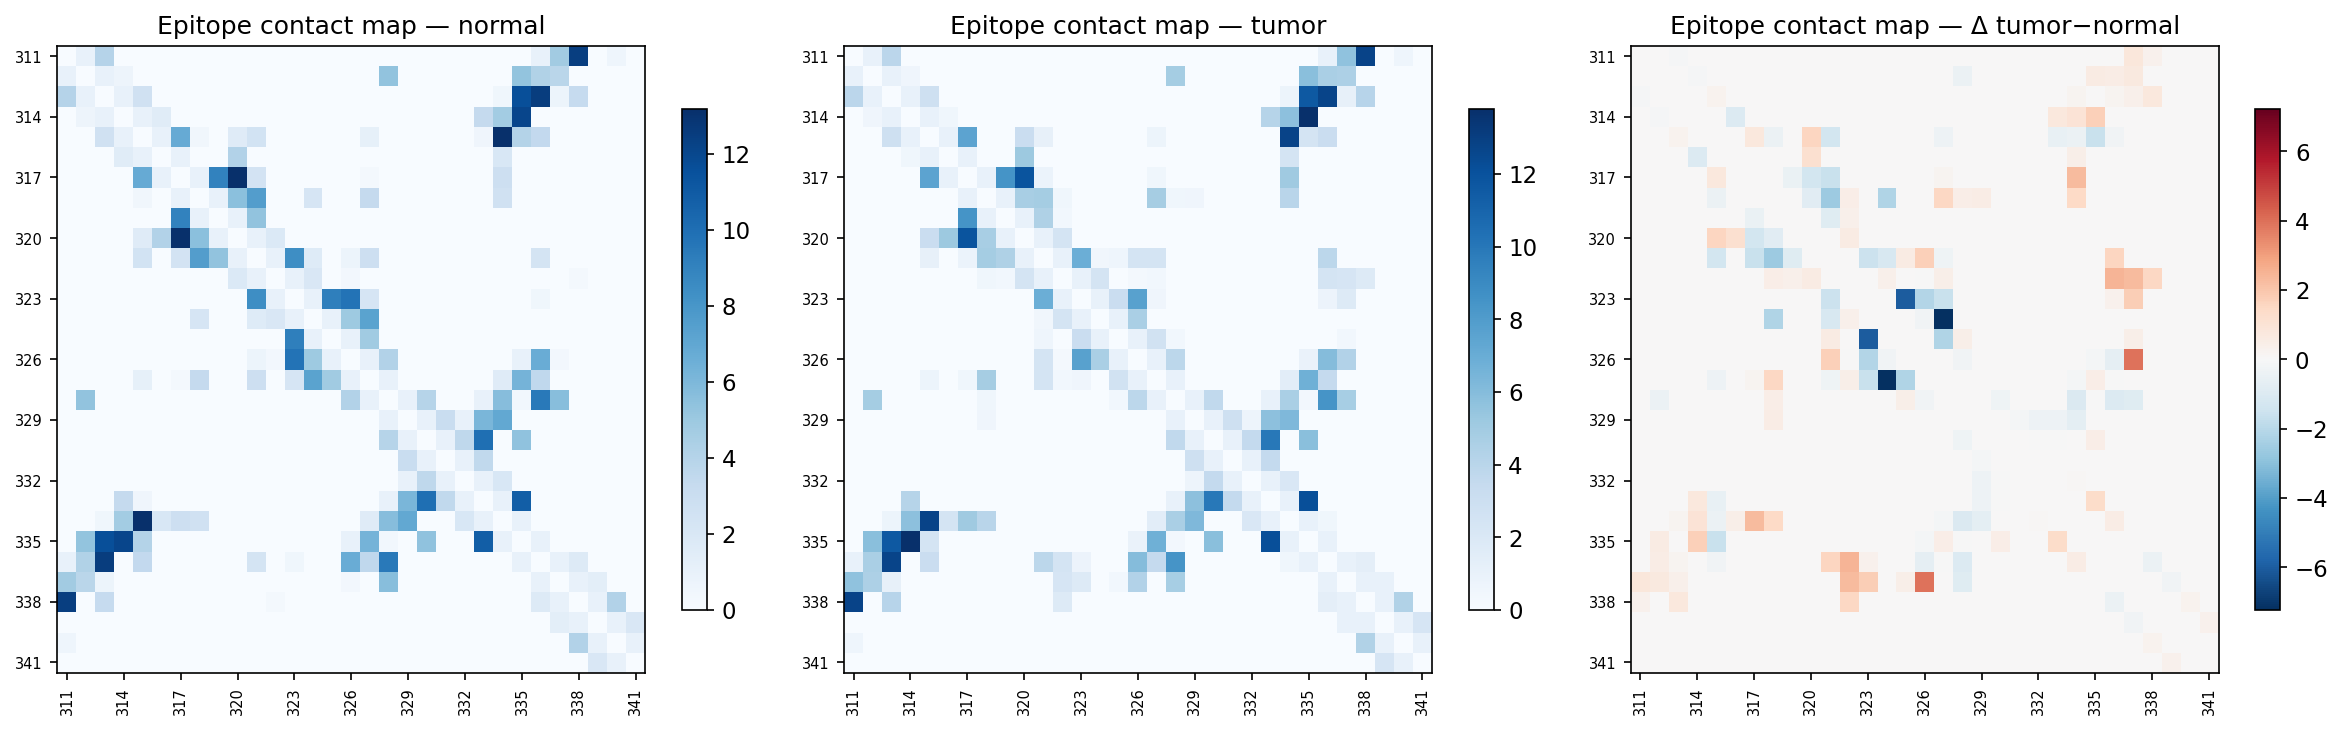

In [ ]:
def contact_map_matrix(G, resids):
    idx={r:i for i,r in enumerate(resids)}; mat=np.zeros((len(resids),len(resids)),dtype=np.float32)
    for r1 in resids:
        for r2 in resids:
            if G.has_edge(r1,r2): mat[idx[r1],idx[r2]]=G[r1][r2]['contact_freq']
    return mat

ep=epitope_resids_sorted
CM_EP={cond: contact_map_matrix(GRAPHS[cond],ep) for cond in CONDITIONS}
CM_EP_DELTA=CM_EP['tumor']-CM_EP['normal']
np.save(OUT_DIR/'epitope_contact_map_normal.npy', CM_EP['normal'])
np.save(OUT_DIR/'epitope_contact_map_tumor.npy',  CM_EP['tumor'])

tick_ep=max(1,len(ep)//10)
fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,(mat,title,cmap) in zip(axes,[(CM_EP['normal'],'normal','Blues'),(CM_EP['tumor'],'tumor','Blues'),(CM_EP_DELTA,'Δ tumor−normal','RdBu_r')]):
    vmax=np.abs(mat).max() or 1.0
    kw=dict(vmin=-vmax,vmax=vmax) if 'Δ' in title else dict(vmin=0,vmax=vmax)
    im=ax.imshow(mat,cmap=cmap,aspect='auto',**kw)
    ax.set_xticks(range(0,len(ep),tick_ep)); ax.set_xticklabels(ep[::tick_ep],rotation=90,fontsize=7)
    ax.set_yticks(range(0,len(ep),tick_ep)); ax.set_yticklabels(ep[::tick_ep],fontsize=7)
    ax.set_title(f'Epitope contact map — {title}'); plt.colorbar(im,ax=ax,shrink=0.8)
plt.tight_layout(); plt.savefig(FIG_DIR/'epitope_contact_maps.png',dpi=300,bbox_inches='tight'); plt.show()

### 4b-5b  Contact maps — ECD (normal | tumor | Δ)

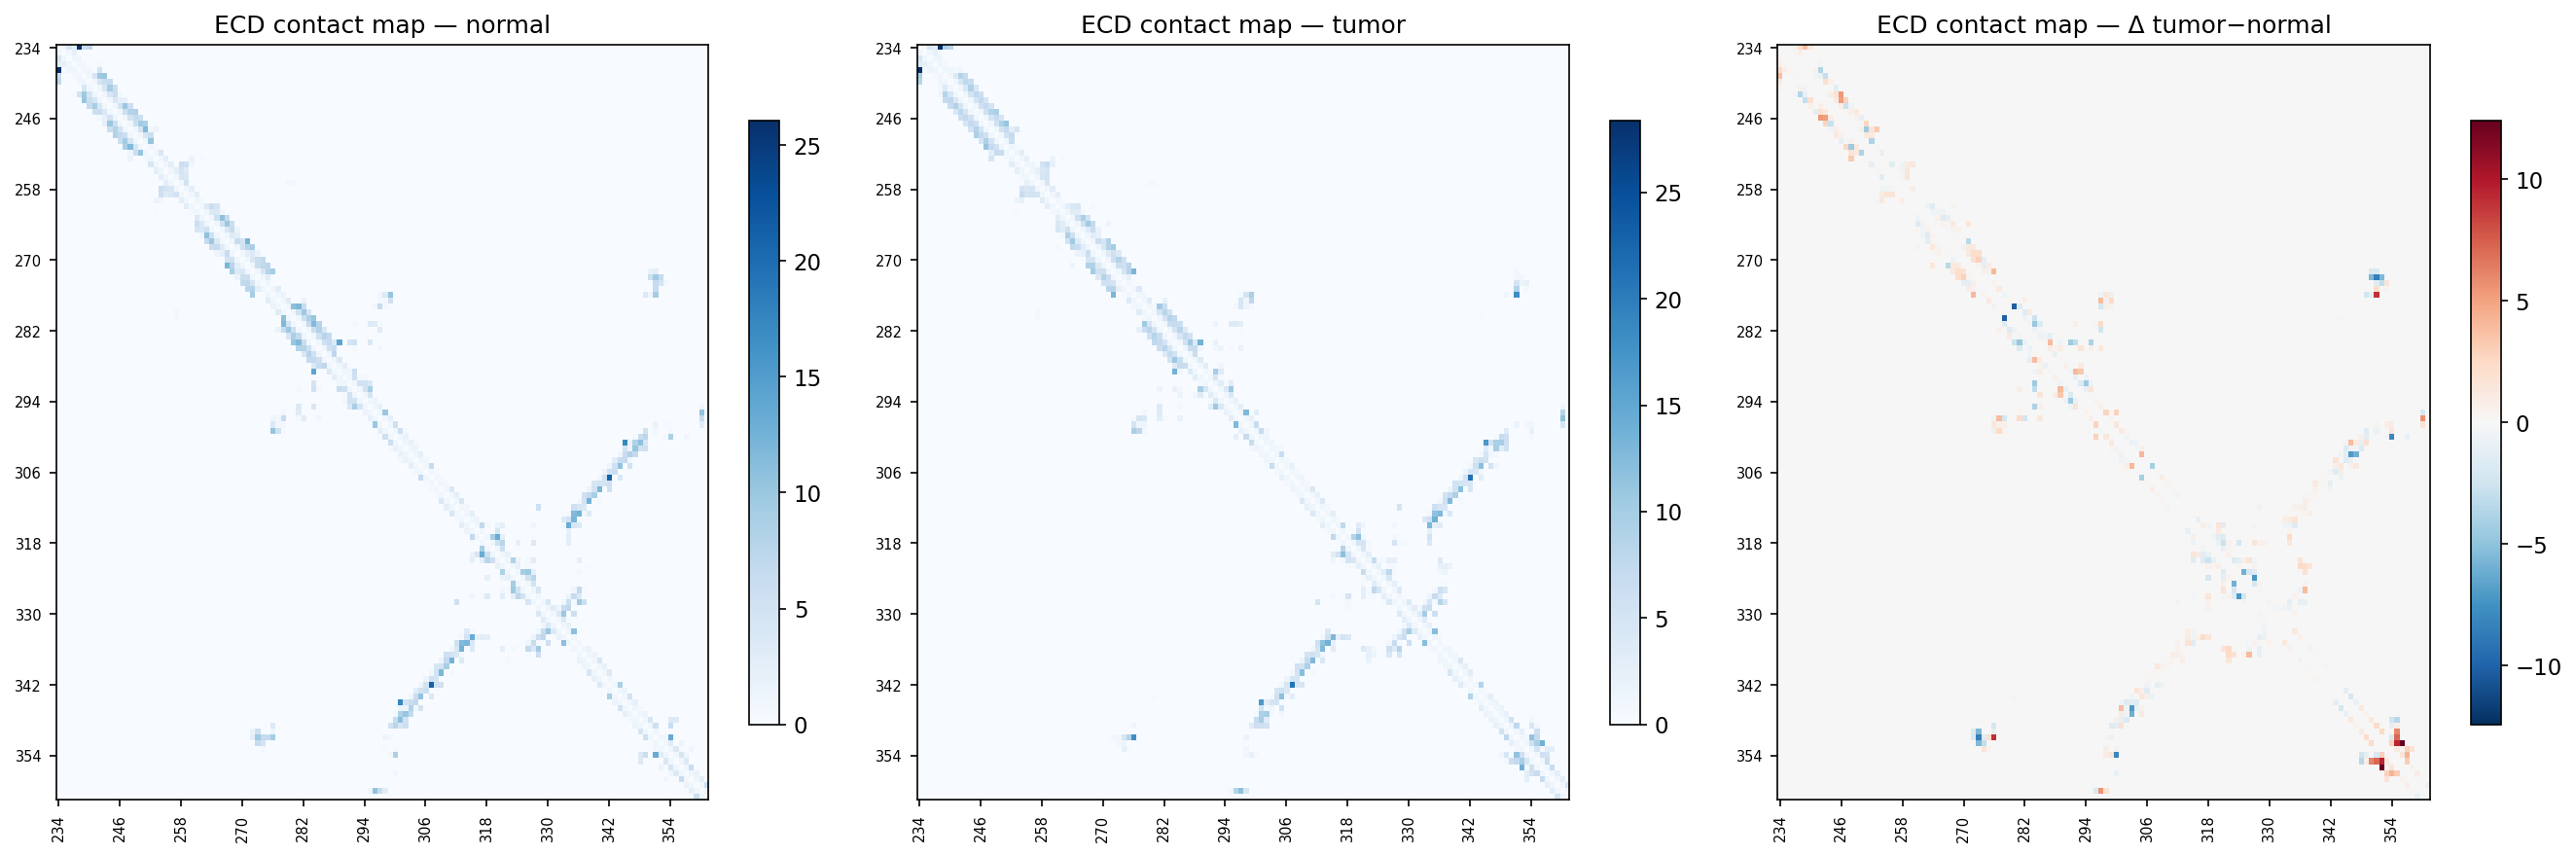

In [ ]:
CM_ECD={cond: contact_map_matrix(GRAPHS[cond],ecd_only_sorted) for cond in CONDITIONS}
CM_ECD_DELTA=CM_ECD['tumor']-CM_ECD['normal']
np.save(OUT_DIR/'ecd_contact_map_normal.npy', CM_ECD['normal'])
np.save(OUT_DIR/'ecd_contact_map_tumor.npy',  CM_ECD['tumor'])

tick_ecd=max(1,len(ecd_only_sorted)//10)
fig,axes=plt.subplots(1,3,figsize=(18,6))
for ax,(mat,title,cmap) in zip(axes,[(CM_ECD['normal'],'normal','Blues'),(CM_ECD['tumor'],'tumor','Blues'),(CM_ECD_DELTA,'Δ tumor−normal','RdBu_r')]):
    vmax=np.abs(mat).max() or 1.0
    kw=dict(vmin=-vmax,vmax=vmax) if 'Δ' in title else dict(vmin=0,vmax=vmax)
    im=ax.imshow(mat,cmap=cmap,aspect='auto',**kw)
    ax.set_xticks(range(0,len(ecd_only_sorted),tick_ecd)); ax.set_xticklabels(ecd_only_sorted[::tick_ecd],rotation=90,fontsize=7)
    ax.set_yticks(range(0,len(ecd_only_sorted),tick_ecd)); ax.set_yticklabels(ecd_only_sorted[::tick_ecd],fontsize=7)
    ax.set_title(f'ECD contact map — {title}'); plt.colorbar(im,ax=ax,shrink=0.8)
plt.tight_layout(); plt.savefig(FIG_DIR/'ecd_contact_maps.png',dpi=300,bbox_inches='tight'); plt.show()

### 4b-6a  Residue-level statistics — Epitope

In [ ]:
hotspot_rows=[]
for resid in epitope_resids_sorted:
    fn=[d['contact_freq'] for _,_,d in GRAPHS['normal'].edges(resid,data=True)]
    ft=[d['contact_freq'] for _,_,d in GRAPHS['tumor'].edges(resid,data=True)]
    mn=np.mean(fn) if fn else 0.0; mt=np.mean(ft) if ft else 0.0
    try: _,pval=mannwhitneyu(fn,ft,alternative='two-sided') if (fn and ft) else (np.nan,1.0)
    except: pval=1.0
    rn=RESTABLE['normal'].set_index('resid').at[resid,'resname'] if resid in RESTABLE['normal']['resid'].values else ''
    hotspot_rows.append({'resid':resid,'resname':rn,'mean_freq_normal':round(mn,5),
                         'mean_freq_tumor':round(mt,5),'delta':round(mt-mn,5),'p_raw':pval})
hotspot_df=pd.DataFrame(hotspot_rows)
_,padj,_,_=multipletests(hotspot_df['p_raw'].fillna(1.0),method='fdr_bh')
hotspot_df['p_adj']=padj; hotspot_df['significant']=hotspot_df['p_adj']<0.05
print('Epitope hotspots (FDR < 0.05):')
sig=hotspot_df[hotspot_df['significant']].sort_values('delta',key=abs,ascending=False)
print(sig[['resid','resname','mean_freq_normal','mean_freq_tumor','delta','p_adj']].to_string(index=False) if len(sig) else '  (none at FDR<0.05)')
print(f'\nTotal epitope residues tested: {len(hotspot_df)}')


Epitope hotspots (FDR < 0.05):
  (none at FDR<0.05)

Total epitope residues tested: 31


### 4b-6b  Residue-level statistics — ECD (excl. epitope)

In [ ]:
ecd_hotspot_rows=[]
for resid in ecd_only_sorted:
    fn=[d['contact_freq'] for _,_,d in GRAPHS['normal'].edges(resid,data=True)]
    ft=[d['contact_freq'] for _,_,d in GRAPHS['tumor'].edges(resid,data=True)]
    mn=np.mean(fn) if fn else 0.0; mt=np.mean(ft) if ft else 0.0
    try: _,pval=mannwhitneyu(fn,ft,alternative='two-sided') if (fn and ft) else (np.nan,1.0)
    except: pval=1.0
    rn=RESTABLE['normal'].set_index('resid').at[resid,'resname'] if resid in RESTABLE['normal']['resid'].values else ''
    ecd_hotspot_rows.append({'resid':resid,'resname':rn,'mean_freq_normal':round(mn,5),
                              'mean_freq_tumor':round(mt,5),'delta':round(mt-mn,5),'p_raw':pval})
ecd_hotspot_df=pd.DataFrame(ecd_hotspot_rows)
_,padj_ecd,_,_=multipletests(ecd_hotspot_df['p_raw'].fillna(1.0),method='fdr_bh')
ecd_hotspot_df['p_adj']=padj_ecd; ecd_hotspot_df['significant']=ecd_hotspot_df['p_adj']<0.05
print('ECD hotspots (FDR < 0.05):')
sig_ecd=ecd_hotspot_df[ecd_hotspot_df['significant']].sort_values('delta',key=abs,ascending=False)
print(sig_ecd[['resid','resname','mean_freq_normal','mean_freq_tumor','delta','p_adj']].to_string(index=False) if len(sig_ecd) else '  (none at FDR<0.05)')
print(f'\nTotal ECD residues tested: {len(ecd_hotspot_df)}')

ECD hotspots (FDR < 0.05):
  (none at FDR<0.05)

Total ECD residues tested: 128


## Step 5 — Statistical tests (MWU · FDR-BH · Cohen's d · Bootstrap CI)

In [ ]:
def cohens_d(a, b):
    n1,n2=len(a),len(b)
    if n1<2 or n2<2: return 0.0
    s=np.sqrt(((n1-1)*np.var(a,ddof=1)+(n2-1)*np.var(b,ddof=1))/(n1+n2-2))
    return (np.mean(a)-np.mean(b))/s if s>1e-12 else 0.0

def bootstrap_ci(values, n_boot=1000, ci=0.95):
    if len(values)<2: return float(np.mean(values)),float(np.mean(values)),float(np.mean(values))
    means=[np.mean(np.random.choice(values,len(values),replace=True)) for _ in range(n_boot)]
    return float(np.mean(values)),float(np.percentile(means,(1-ci)/2*100)),float(np.percentile(means,(1+ci)/2*100))

np.random.seed(42)
STAT_ROWS=[]
for metric in METRICS:
    for cond in CONDITIONS:
        df=CENTRALITY[cond]
        groups={'epitope':df[df['region']=='epitope'][metric].values,
                'ECD_all':df[df['region'].isin(['ECD','epitope'])][metric].values,
                'other'  :df[df['region']=='other'][metric].values}
        for g1,g2,label in [('epitope','other','epitope vs other'),('ECD_all','other','ECD(+ep) vs other')]:
            a,b=groups[g1],groups[g2]
            if len(a)<2 or len(b)<2: continue
            _,pval=mannwhitneyu(a,b,alternative='two-sided'); cd=cohens_d(a,b)
            m_a,lo_a,hi_a=bootstrap_ci(a); m_b,lo_b,hi_b=bootstrap_ci(b)
            STAT_ROWS.append({'condition':cond,'metric':metric,'comparison':label,
                'U_pval':pval,'cohens_d':round(cd,4),
                'mean_g1':round(m_a,6),'CI95_lo_g1':round(lo_a,6),'CI95_hi_g1':round(hi_a,6),
                'mean_g2':round(m_b,6),'CI95_lo_g2':round(lo_b,6),'CI95_hi_g2':round(hi_b,6)})
STAT_DF=pd.DataFrame(STAT_ROWS)
_,padj,_,_=multipletests(STAT_DF['U_pval'],method='fdr_bh')
STAT_DF['FDR']=padj
STAT_DF['sig']=STAT_DF['FDR'].apply(lambda p:'***' if p<0.001 else('**' if p<0.01 else('*' if p<0.05 else 'ns')))
print('Significant comparisons (FDR<0.05):')
print(STAT_DF[STAT_DF['FDR']<0.05][['condition','metric','comparison','cohens_d','FDR','sig']].to_string(index=False))

Significant comparisons (FDR<0.05):
condition      metric        comparison  cohens_d          FDR sig
   normal      degree  epitope vs other   -0.5793 3.484957e-03  **
   normal      degree ECD(+ep) vs other   -0.3340 8.781206e-04 ***
    tumor      degree  epitope vs other   -0.4284 2.380385e-02   *
    tumor      degree ECD(+ep) vs other   -0.2497 1.327632e-02   *
   normal    strength  epitope vs other   -0.4969 5.256868e-03  **
   normal    strength ECD(+ep) vs other   -0.2933 2.280622e-03  **
    tumor    strength  epitope vs other   -0.5175 4.162664e-03  **
    tumor    strength ECD(+ep) vs other   -0.2629 4.341329e-03  **
   normal betweenness ECD(+ep) vs other   -0.0793 3.448338e-02   *
    tumor betweenness ECD(+ep) vs other   -0.1929 1.327632e-02   *
   normal   closeness  epitope vs other   -1.7871 2.814323e-13 ***
   normal   closeness ECD(+ep) vs other   -0.6314 2.362093e-13 ***
    tumor   closeness  epitope vs other   -1.5225 5.463063e-12 ***
    tumor   closeness ECD(

## Step 6 — Community detection (Louvain)

In [ ]:
import networkx.algorithms.community as nx_comm

PARTITIONS: Dict[str, dict] = {}
MODULARITY: Dict[str, float] = {}
COMMUNITIES: Dict[str, Dict[int, list]] = {}

for cond in CONDITIONS:
    G = GRAPHS[cond]
    # Louvain через networkx (>=3.0)
    communities = nx_comm.louvain_communities(G, weight='contact_freq', seed=42)
    partition = {}
    for cid, members in enumerate(communities):
        for resid in members:
            partition[resid] = cid
    Q = nx_comm.modularity(G, communities, weight='contact_freq')
    PARTITIONS[cond] = partition
    MODULARITY[cond] = Q
    comm_map = {}
    for resid, cid in partition.items():
        comm_map.setdefault(cid, []).append(resid)
    COMMUNITIES[cond] = comm_map
    print(f'{cond}: Q={Q:.4f}, n_communities={len(comm_map)}, largest={max(len(v) for v in comm_map.values())} residues')

labels_n = [PARTITIONS['normal'].get(r, -1) for r in sorted(GRAPHS['normal'].nodes())]
labels_t = [PARTITIONS['tumor'].get(r, -1)  for r in sorted(GRAPHS['normal'].nodes())]
NMI = normalized_mutual_info_score(labels_n, labels_t)
ARI = adjusted_rand_score(labels_n, labels_t)
print(f'\nNMI(normal,tumor) = {NMI:.4f}')
print(f'ARI(normal,tumor) = {ARI:.4f}')

normal: Q=0.7914, n_communities=16, largest=76 residues
tumor: Q=0.7923, n_communities=17, largest=79 residues

NMI(normal,tumor) = 0.7885
ARI(normal,tumor) = 0.6231


In [ ]:
def community_enrichment(comm_map, resid_set, all_resids, label):
    N=len(all_resids); K=len(resid_set & all_resids); rows=[]
    for cid,members in comm_map.items():
        n=len(members); k=len(set(members)&resid_set)
        tab=[[k,n-k],[K-k,N-n-K+k]]
        try: _,p=fisher_exact(tab,alternative='greater')
        except: p=1.0
        rows.append({'community':cid,'n_members':n,f'n_{label}':k,'p_fisher':round(p,5)})
    df=pd.DataFrame(rows).sort_values('p_fisher')
    _,padj2,_,_=multipletests(df['p_fisher'],method='fdr_bh'); df['p_adj']=padj2
    return df
all_r=set(RESTABLE['normal']['resid'])
ENRICH={}
for cond in CONDITIONS:
    print(f'\n=== Epitope enrichment — {cond} ===')
    ENRICH[cond]=community_enrichment(COMMUNITIES[cond],EPITOPE_RESIDS,all_r,'epitope')
    sig_e=ENRICH[cond][ENRICH[cond]['p_adj']<0.05]
    print(sig_e.head(5).to_string(index=False) if len(sig_e) else '  (none at FDR<0.05)')
for cond in CONDITIONS:
    CENTRALITY[cond]['community']=(CENTRALITY[cond]['resid'].map(PARTITIONS[cond]).fillna(-1).astype(int))
print('\nCommunity assignments added to CENTRALITY tables.')



=== Epitope enrichment — normal ===
 community  n_members  n_epitope  p_fisher  p_adj
         6         40         31       0.0    0.0

=== Epitope enrichment — tumor ===
 community  n_members  n_epitope  p_fisher  p_adj
         6         36         31       0.0    0.0

Community assignments added to CENTRALITY tables.


## Step 7 — Allosteric pathways

In [ ]:
# def inv_freq(u, v, d): return 1.0 / max(d.get('contact_freq',1e-9),1e-9)

# def find_allosteric_paths(G, source_resids, target_resids):
#     paths=[]
#     for src in source_resids:
#         if src not in G: continue
#         for tgt in target_resids:
#             if tgt not in G or src==tgt: continue
#             try:
#                 p=nx.shortest_path(G,src,tgt,weight=inv_freq)
#                 L=nx.shortest_path_length(G,src,tgt,weight=inv_freq)
#                 paths.append({'src':src,'tgt':tgt,'path':p,'length':round(L,4),'n_hops':len(p)-1})
#             except nx.NetworkXNoPath: pass
#     return paths

# epitope_list=list(EPITOPE_RESIDS)
# ALLOSTERIC: Dict[str,list]={}
# for cond in CONDITIONS:
#     paths=find_allosteric_paths(GRAPHS[cond],epitope_list,PHOSPHATE_SITE_RESIDS)
#     ALLOSTERIC[cond]=paths
#     if paths:
#         L=[p['length'] for p in paths]; H=[p['n_hops'] for p in paths]
#         print(f'{cond}: {len(paths)} paths | mean_length={np.mean(L):.3f} | mean_hops={np.mean(H):.1f}')
#     else: print(f'{cond}: no paths (check PHOSPHATE_SITE_RESIDS)')

# if ALLOSTERIC['normal'] and ALLOSTERIC['tumor']:
#     inter_n=set(r for p in ALLOSTERIC['normal'] for r in p['path'][1:-1])
#     inter_t=set(r for p in ALLOSTERIC['tumor']  for r in p['path'][1:-1])
#     print(f'\nIntersection normal∩tumor intermediates: {sorted(inter_n & inter_t)}')
#     print(f'normal only : {sorted(inter_n - inter_t)}')
#     print(f'tumor only  : {sorted(inter_t - inter_n)}')

## Step 8 — Protein–lipid & protein–glycan proximity

In [ ]:
GLYCAN_ANCHOR_RESIDS = set()
for cond in CONDITIONS:
    gdf = GLYCAN_NODES[cond]
    if len(gdf) and 'anchor_resid' in gdf.columns:
        GLYCAN_ANCHOR_RESIDS |= set(gdf['anchor_resid'].dropna().astype(int))
print(f'Glycan anchor resids: {sorted(GLYCAN_ANCHOR_RESIDS)}')

Glycan anchor resids: [295, 308]


In [ ]:
LIPID_NODES: Dict[str,pd.DataFrame]={}; GLYCAN_NODES: Dict[str,pd.DataFrame]={}
for cond in CONDITIONS:
    lp=LOCAL_EXPORT/f'lipid_nodes_{cond}.csv'; gp=LOCAL_EXPORT/f'glycan_nodes_{cond}.csv'
    LIPID_NODES[cond]=pd.read_csv(lp) if lp.exists() else pd.DataFrame()
    GLYCAN_NODES[cond]=pd.read_csv(gp) if gp.exists() else pd.DataFrame()
    print(f'{cond}: lipid_nodes={len(LIPID_NODES[cond])}, glycan_nodes={len(GLYCAN_NODES[cond])}')
PROX_ROWS=[]
for cond in CONDITIONS:
    df=CENTRALITY[cond]
    top50=set(df.nlargest(50,'betweenness')['resid'])
    glyc_resids=set(df[df['is_glycosylated']]['resid'])
    ecd_ep=set(df[df['region'].isin(['ECD','epitope'])]['resid'])
    glycan_sites=top50 & set(GLYCAN_ANCHOR_RESIDS)
    print(f'\n{cond} top-50 hubs:')
    print(f'  is_glycosylated overlap : {sorted(top50 & glyc_resids)}')
    print(f'  ECD/epitope overlap     : {len(top50 & ecd_ep)}')
    print(f'  glycan anchors in top50 : {sorted(glycan_sites)}')
    PROX_ROWS.append({'condition':cond,'n_top50_glycosylated':len(top50 & glyc_resids),
                      'n_top50_ECD_epitope':len(top50 & ecd_ep),'n_top50_glycan_sites':len(glycan_sites)})
print(); print(pd.DataFrame(PROX_ROWS).to_string(index=False))

normal: lipid_nodes=800, glycan_nodes=2
tumor: lipid_nodes=788, glycan_nodes=2

normal top-50 hubs:
  is_glycosylated overlap : [308]
  ECD/epitope overlap     : 9
  glycan anchors in top50 : [308]

tumor top-50 hubs:
  is_glycosylated overlap : [308]
  ECD/epitope overlap     : 7
  glycan anchors in top50 : [308]

condition  n_top50_glycosylated  n_top50_ECD_epitope  n_top50_glycan_sites
   normal                     1                    9                     1
    tumor                     1                    7                     1


## Step 8b — Non-protein contact metrics

Per-residue summary, region-level aggregation и differential analysis normal vs tumor.  
Экспорт: `np_contact_summary.csv`, `np_contact_region.csv`, `np_contact_differential.csv`.

In [ ]:
# =====================================================================
# CELL 3B-NPM  ·  Non-protein contact metrics  (Step 8b)
#                 Вставить ПОСЛЕ Step 8 (protein-lipid / glycan proximity)
# =====================================================================
# Outputs:
#   NP_SUMMARY_DF   — per-residue summary (to CSV)
#   NP_REGION_DF    — region-level aggregation (to CSV)
#   NP_DIFF_DF      — differential analysis normal vs tumor (to CSV)
# =====================================================================

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# ── 1. Per-residue summary ────────────────────────────────────────────
np_rows = []
for cond in CONDITIONS:
    rt  = RESTABLE[cond]
    npedg = NP_CONTACT_EDGES[cond]
    if len(npedg) == 0:
        continue
    for resid, grp in npedg.groupby("protein_resid"):
        row = rt[rt["resid"] == resid]
        region  = row["region"].values[0]  if len(row) else "other"
        resname = row["resname"].values[0] if len(row) else "UNK"
        for ntype, sg in grp.groupby("node_type"):
            np_rows.append(dict(
                condition    = cond,
                resid        = int(resid),
                resname      = resname,
                region       = region,
                node_type    = ntype,
                n_contacts   = len(sg),
                min_dist_A   = float(sg["distance_A"].min()),
                mean_dist_A  = float(sg["distance_A"].mean()),
            ))

NP_SUMMARY_DF = pd.DataFrame(np_rows)
NP_SUMMARY_DF.to_csv(OUT_DIR / "np_contact_summary.csv", index=False)
print(f"[NPM] np_contact_summary.csv  rows={len(NP_SUMMARY_DF)}")

# ── 2. Region-level aggregation ───────────────────────────────────────
if len(NP_SUMMARY_DF):
    NP_REGION_DF = (NP_SUMMARY_DF
        .groupby(["condition", "region", "node_type"])
        .agg(n_residues=("resid", "nunique"),
             total_contacts=("n_contacts", "sum"),
             mean_min_dist=("min_dist_A", "mean"))
        .reset_index()
        .sort_values(["condition", "region", "node_type"]))
    NP_REGION_DF.to_csv(OUT_DIR / "np_contact_region.csv", index=False)
    print("[NPM] np_contact_region.csv")
    print(NP_REGION_DF.to_string(index=False))
else:
    NP_REGION_DF = pd.DataFrame()
    print("[NPM] No non-protein contacts found — NP_REGION_DF empty.")

# ── 3. Differential analysis normal vs tumor ─────────────────────────
diff_rows = []
for node_type in (NP_SUMMARY_DF["node_type"].unique() if len(NP_SUMMARY_DF) else []):
    sub = NP_SUMMARY_DF[NP_SUMMARY_DF["node_type"] == node_type]
    resids_all = set(sub["resid"].unique())
    for resid in sorted(resids_all):
        fn = sub[(sub["resid"] == resid) & (sub["condition"] == "normal")]["n_contacts"].values
        ft = sub[(sub["resid"] == resid) & (sub["condition"] == "tumor")]["n_contacts"].values
        mn = float(fn.mean()) if len(fn) else 0.0
        mt = float(ft.mean()) if len(ft) else 0.0
        try:
            _, pval = mannwhitneyu(fn, ft, alternative="two-sided") \
                      if len(fn) and len(ft) else (np.nan, 1.0)
        except Exception:
            pval = 1.0
        diff_rows.append(dict(
            resid=resid, node_type=node_type,
            mean_normal=round(mn, 4), mean_tumor=round(mt, 4),
            delta=round(mt - mn, 4), pval=pval,
        ))

NP_DIFF_DF = pd.DataFrame(diff_rows)
if len(NP_DIFF_DF):
    NP_DIFF_DF.to_csv(OUT_DIR / "np_contact_differential.csv", index=False)
    print(f"[NPM] np_contact_differential.csv  rows={len(NP_DIFF_DF)}")
    sig = NP_DIFF_DF[NP_DIFF_DF["pval"] < 0.05].sort_values("delta", key=abs, ascending=False)
    if len(sig):
        print(f"[NPM] Nominally significant residues (p<0.05): {len(sig)}")
        print(sig[["resid","node_type","mean_normal","mean_tumor","delta","pval"]]
              .head(20).to_string(index=False))
    else:
        print("[NPM] No nominally significant differential contacts.")


[NPM] np_contact_summary.csv  rows=426
[NPM] np_contact_region.csv
condition region node_type  n_residues  total_contacts  mean_min_dist
   normal    ECD    glycan           7               7       5.023998
   normal    ECD     lipid          30              44       4.217128
   normal  other     lipid         163             247       4.107212
    tumor    ECD     lipid          14              18       3.165455
    tumor  other     lipid         212             388       1.880295
[NPM] np_contact_differential.csv  rows=298
[NPM] No nominally significant differential contacts.


## Step 9 — Temporal RIN analysis (sliding window)

Строит RIN для каждого окна `[t, t+W]`.  
**Параметры** (редактировать в начале ячейки): `TEMP_WINDOW`, `TEMP_STEP`, `TEMP_MIN_FREQ`.  
Входные данные: `contact_edges_perframe_{cond}.parquet` (Phase3A CELL 3A-PERFRAME).  
Экспорт: `temporal_rin_{cond}.csv`.

In [ ]:
# =====================================================================
# CELL 3B-TEMP  ·  Temporal / sliding-window RIN analysis  (Step 9)
# =====================================================================
# Builds a per-window RIN from per-frame contacts exported by Phase3A.
# For each sliding window [t, t+W] computes core topological metrics:
#   modularity, betweenness, density, n_edges, mean_degree, n_communities
#
# Parameters (edit here):
TEMP_WINDOW   = 10   # window width in frames
TEMP_STEP     =  10   # step (50 % overlap → smoother time-series)
TEMP_MIN_FREQ = 0.25  # contact_freq threshold within window
#                       (lower than consensus 0.3 — smaller effective N)
# =====================================================================

import numpy as np
import pandas as pd
import networkx as nx
from tqdm.auto import tqdm
import warnings

# ── 1. Load per-frame contacts ─────────────────────────────────────
PERFRAME: dict[str, pd.DataFrame] = {}
for cond in CONDITIONS:
    p = LOCAL_EXPORT / f"contact_edges_perframe_{cond}.parquet"
    if p.exists():
        PERFRAME[cond] = pd.read_parquet(p)
        nf = PERFRAME[cond]["frame"].nunique()
        print(f"[{cond}] loaded {len(PERFRAME[cond]):,} rows | {nf} frames")
    else:
        warnings.warn(f"[WARN] {p.name} not found — run CELL 3A-PERFRAME first")

if not PERFRAME:
    raise FileNotFoundError("No per-frame contact files found. Run Phase3A CELL 3A-PERFRAME.")


# ── 2. Helpers ─────────────────────────────────────────────────────
def build_window_graph(subset: pd.DataFrame, n_frames: int,
                       min_freq: float) -> nx.Graph:
    if subset.empty:
        return nx.Graph()
    freq = (subset.groupby(["resid_i", "resid_j"])
                  .size()
                  .div(n_frames)
                  .reset_index(name="contact_freq"))
    freq = freq[freq["contact_freq"] >= min_freq]
    G = nx.Graph()
    for _, row in freq.iterrows():
        G.add_edge(row.resid_i, row.resid_j, contact_freq=row.contact_freq)
    return G


def graph_metrics(G: nx.Graph) -> dict:
    if G.number_of_nodes() == 0:
        return {k: np.nan for k in [
            "n_nodes","n_edges","density","mean_degree",
            "modularity","n_communities",
            "betweenness_mean","betweenness_max",
            "closeness_mean","strength_mean"]}

    bet  = nx.betweenness_centrality(G, weight="contact_freq", normalized=True)
    clo  = nx.closeness_centrality(G)
    deg  = dict(G.degree())
    str_ = {n: sum(d.get("contact_freq",0) for _,_,d in G.edges(n, data=True))
            for n in G.nodes()}

    try:
        import community as community_louvain
        partition = community_louvain.best_partition(G, random_state=42)
        modularity = community_louvain.modularity(partition, G)
        n_comm     = len(set(partition.values()))
    except Exception:
        modularity, n_comm = np.nan, np.nan

    return {
        "n_nodes":          G.number_of_nodes(),
        "n_edges":          G.number_of_edges(),
        "density":          nx.density(G),
        "mean_degree":      np.mean(list(deg.values())),
        "modularity":       modularity,
        "n_communities":    n_comm,
        "betweenness_mean": np.mean(list(bet.values())),
        "betweenness_max":  np.max(list(bet.values())),
        "closeness_mean":   np.mean(list(clo.values())),
        "strength_mean":    np.mean(list(str_.values())),
    }


# ── 3. Sliding-window loop ─────────────────────────────────────────
TEMPORAL_RESULTS: dict[str, pd.DataFrame] = {}

for cond, pfdf in PERFRAME.items():
    all_frames = sorted(pfdf["frame"].unique())
    n_total    = len(all_frames)
    rows       = []

    if n_total < TEMP_WINDOW:
        warnings.warn(f"[{cond}] only {n_total} frames < TEMP_WINDOW={TEMP_WINDOW}; skipping")
        continue

    starts = range(0, n_total - TEMP_WINDOW + 1, TEMP_STEP)
    for s in tqdm(starts, desc=f"[{cond}] windows"):
        win_frames = all_frames[s: s + TEMP_WINDOW]
        subset     = pfdf[pfdf["frame"].isin(win_frames)]
        G_win      = build_window_graph(subset, len(win_frames), TEMP_MIN_FREQ)
        m          = graph_metrics(G_win)
        m["frame_start"] = win_frames[0]
        m["frame_end"]   = win_frames[-1]
        m["frame_mid"]   = win_frames[len(win_frames)//2]
        m["cond"]        = cond
        rows.append(m)

    TEMPORAL_RESULTS[cond] = pd.DataFrame(rows)
    print(f"[{cond}] {len(rows)} windows done")

# ── 4. Export ──────────────────────────────────────────────────────
for cond, df in TEMPORAL_RESULTS.items():
    out = OUT_DIR / f"temporal_rin_{cond}.csv"
    df.to_csv(out, index=False)
    print(f"  → {out.name}")

[normal] loaded 201,152 rows | 301 frames
[tumor] loaded 205,219 rows | 301 frames


[normal] windows:   0%|          | 0/30 [00:00<?, ?it/s]

[normal] 30 windows done


[tumor] windows:   0%|          | 0/30 [00:00<?, ?it/s]

[tumor] 30 windows done
  → temporal_rin_normal.csv
  → temporal_rin_tumor.csv


### Step 9b — Temporal RIN: visualisation

Time-series 6 метрик (raw + rolling mean + dashed global mean),  
Δ(tumor − normal) с fill_between.  
Экспорт: `fig_temporal_rin.pdf`, `fig_temporal_rin_delta.pdf`.

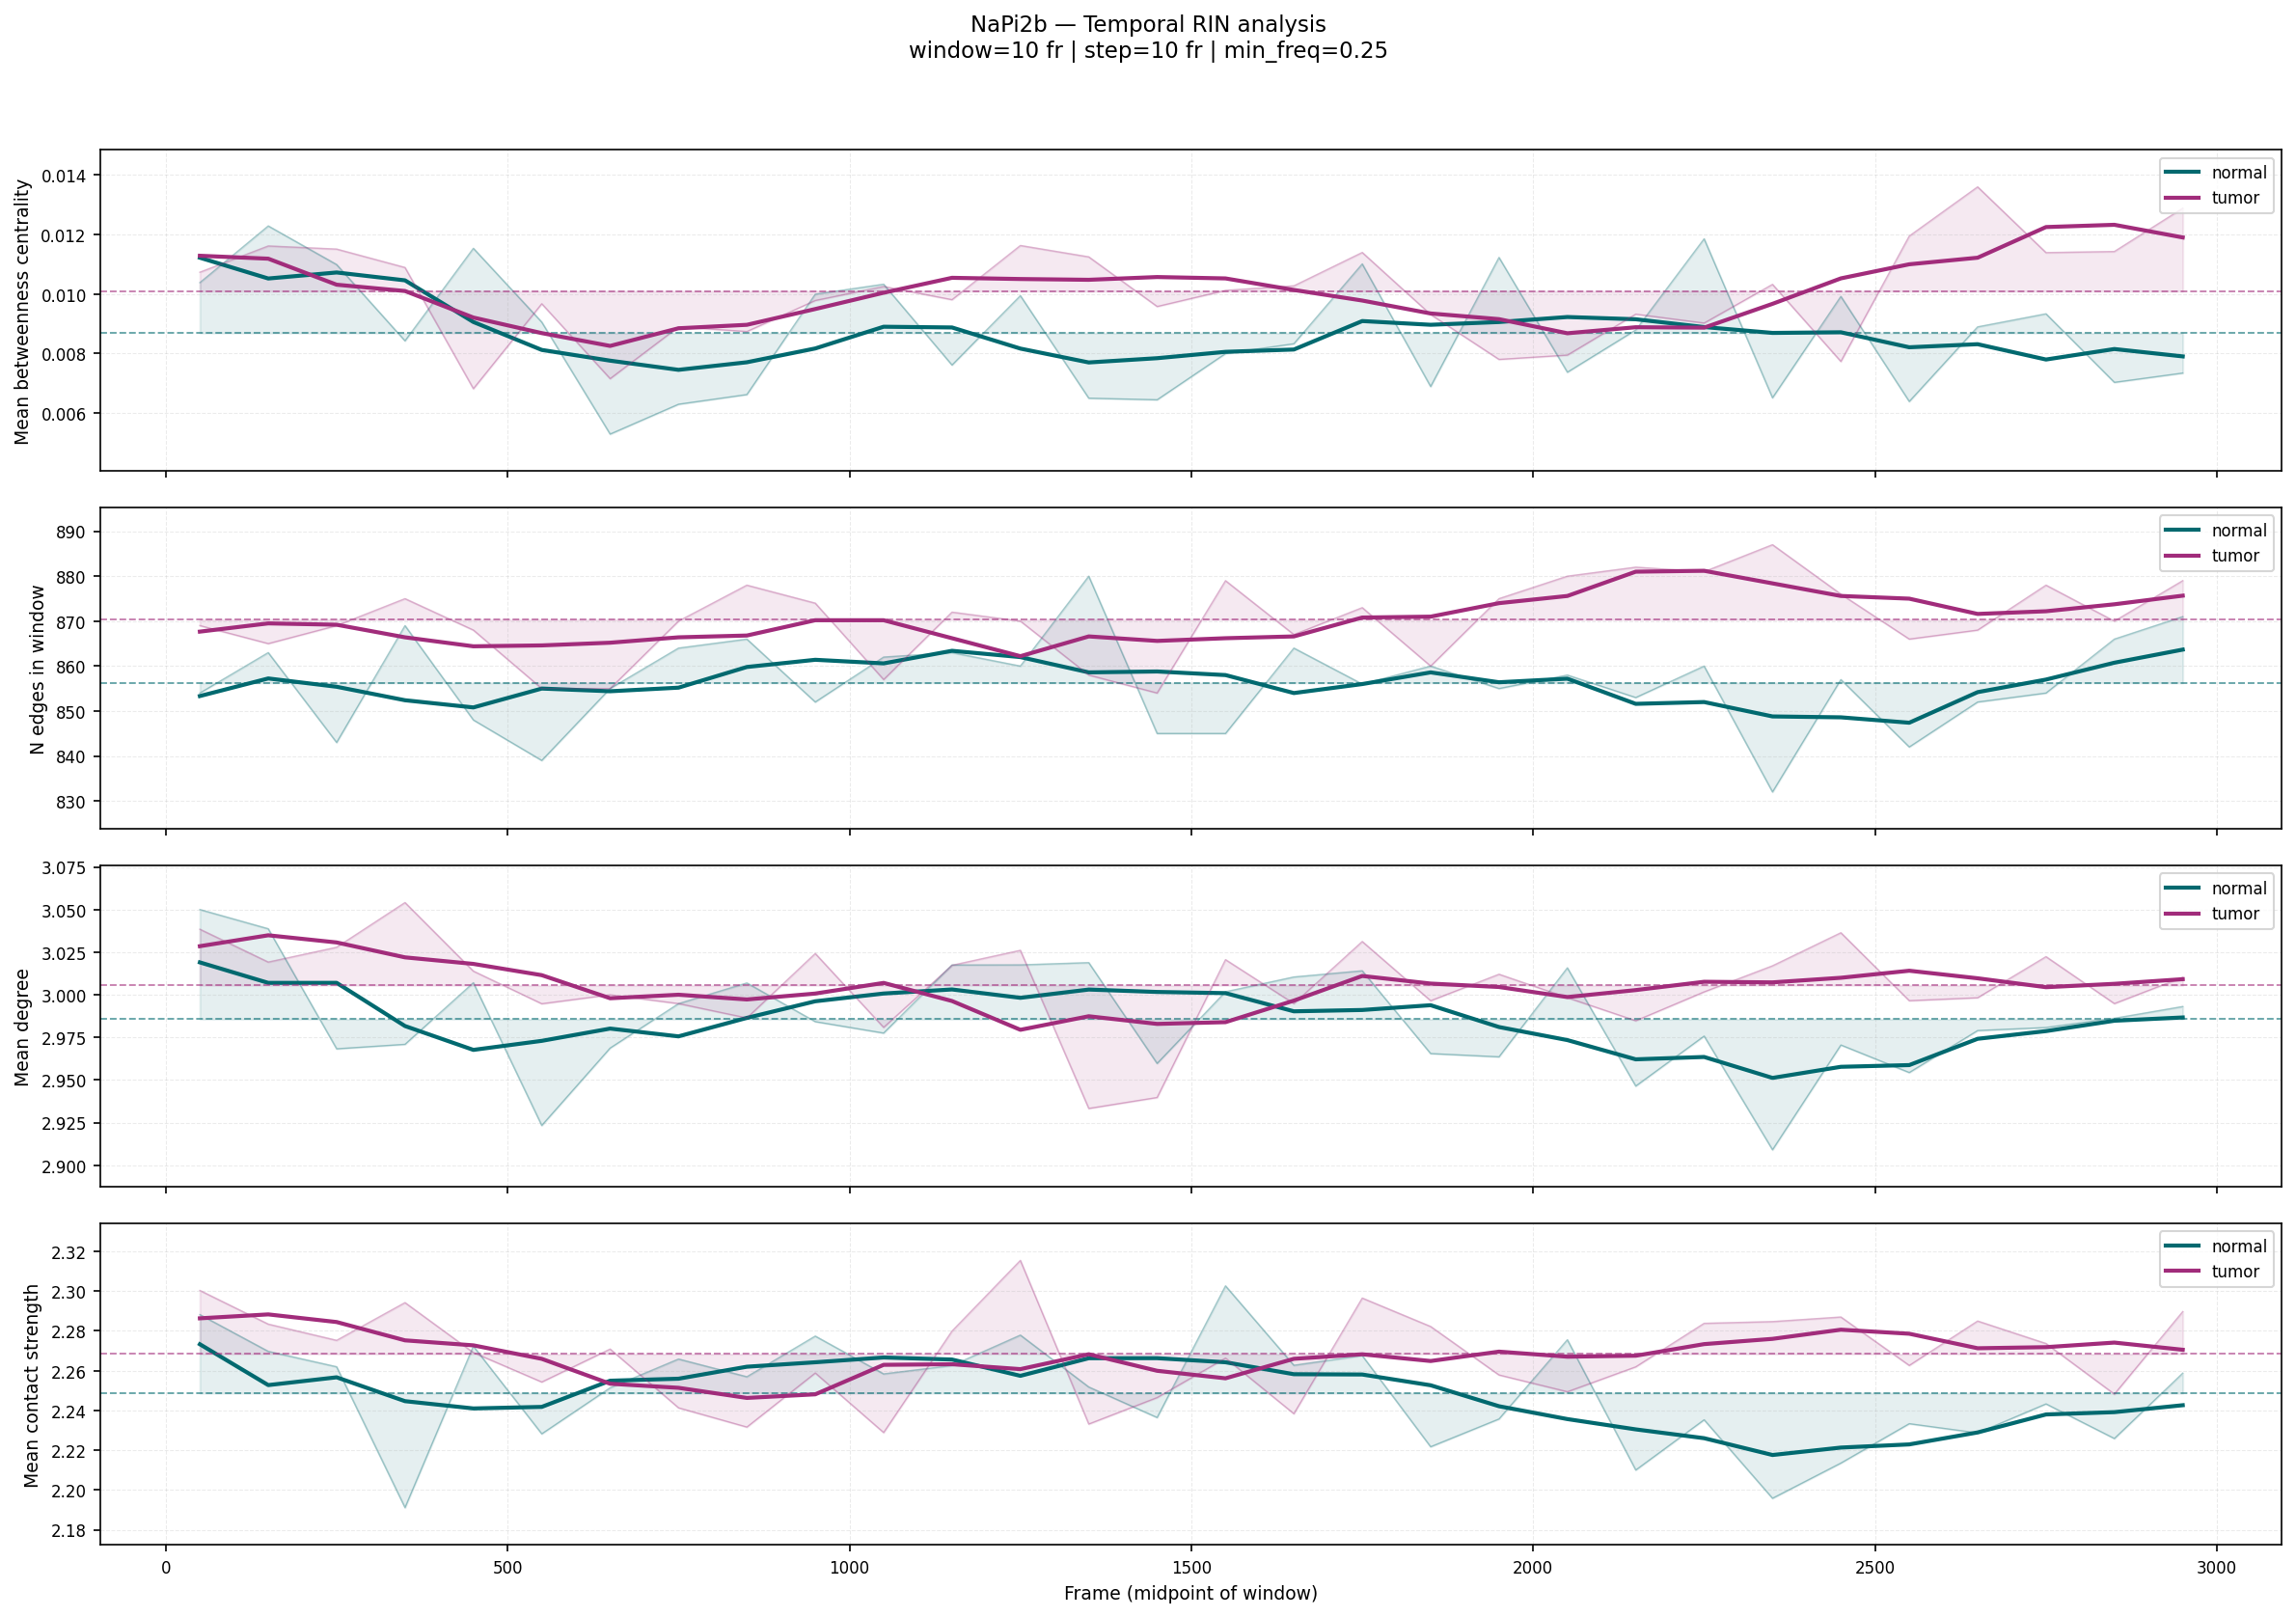

→ saved: /content/phase3b_outputs/figures/fig_temporal_rin.png
→ saved: /content/phase3b_outputs/figures/fig_temporal_rin.pdf


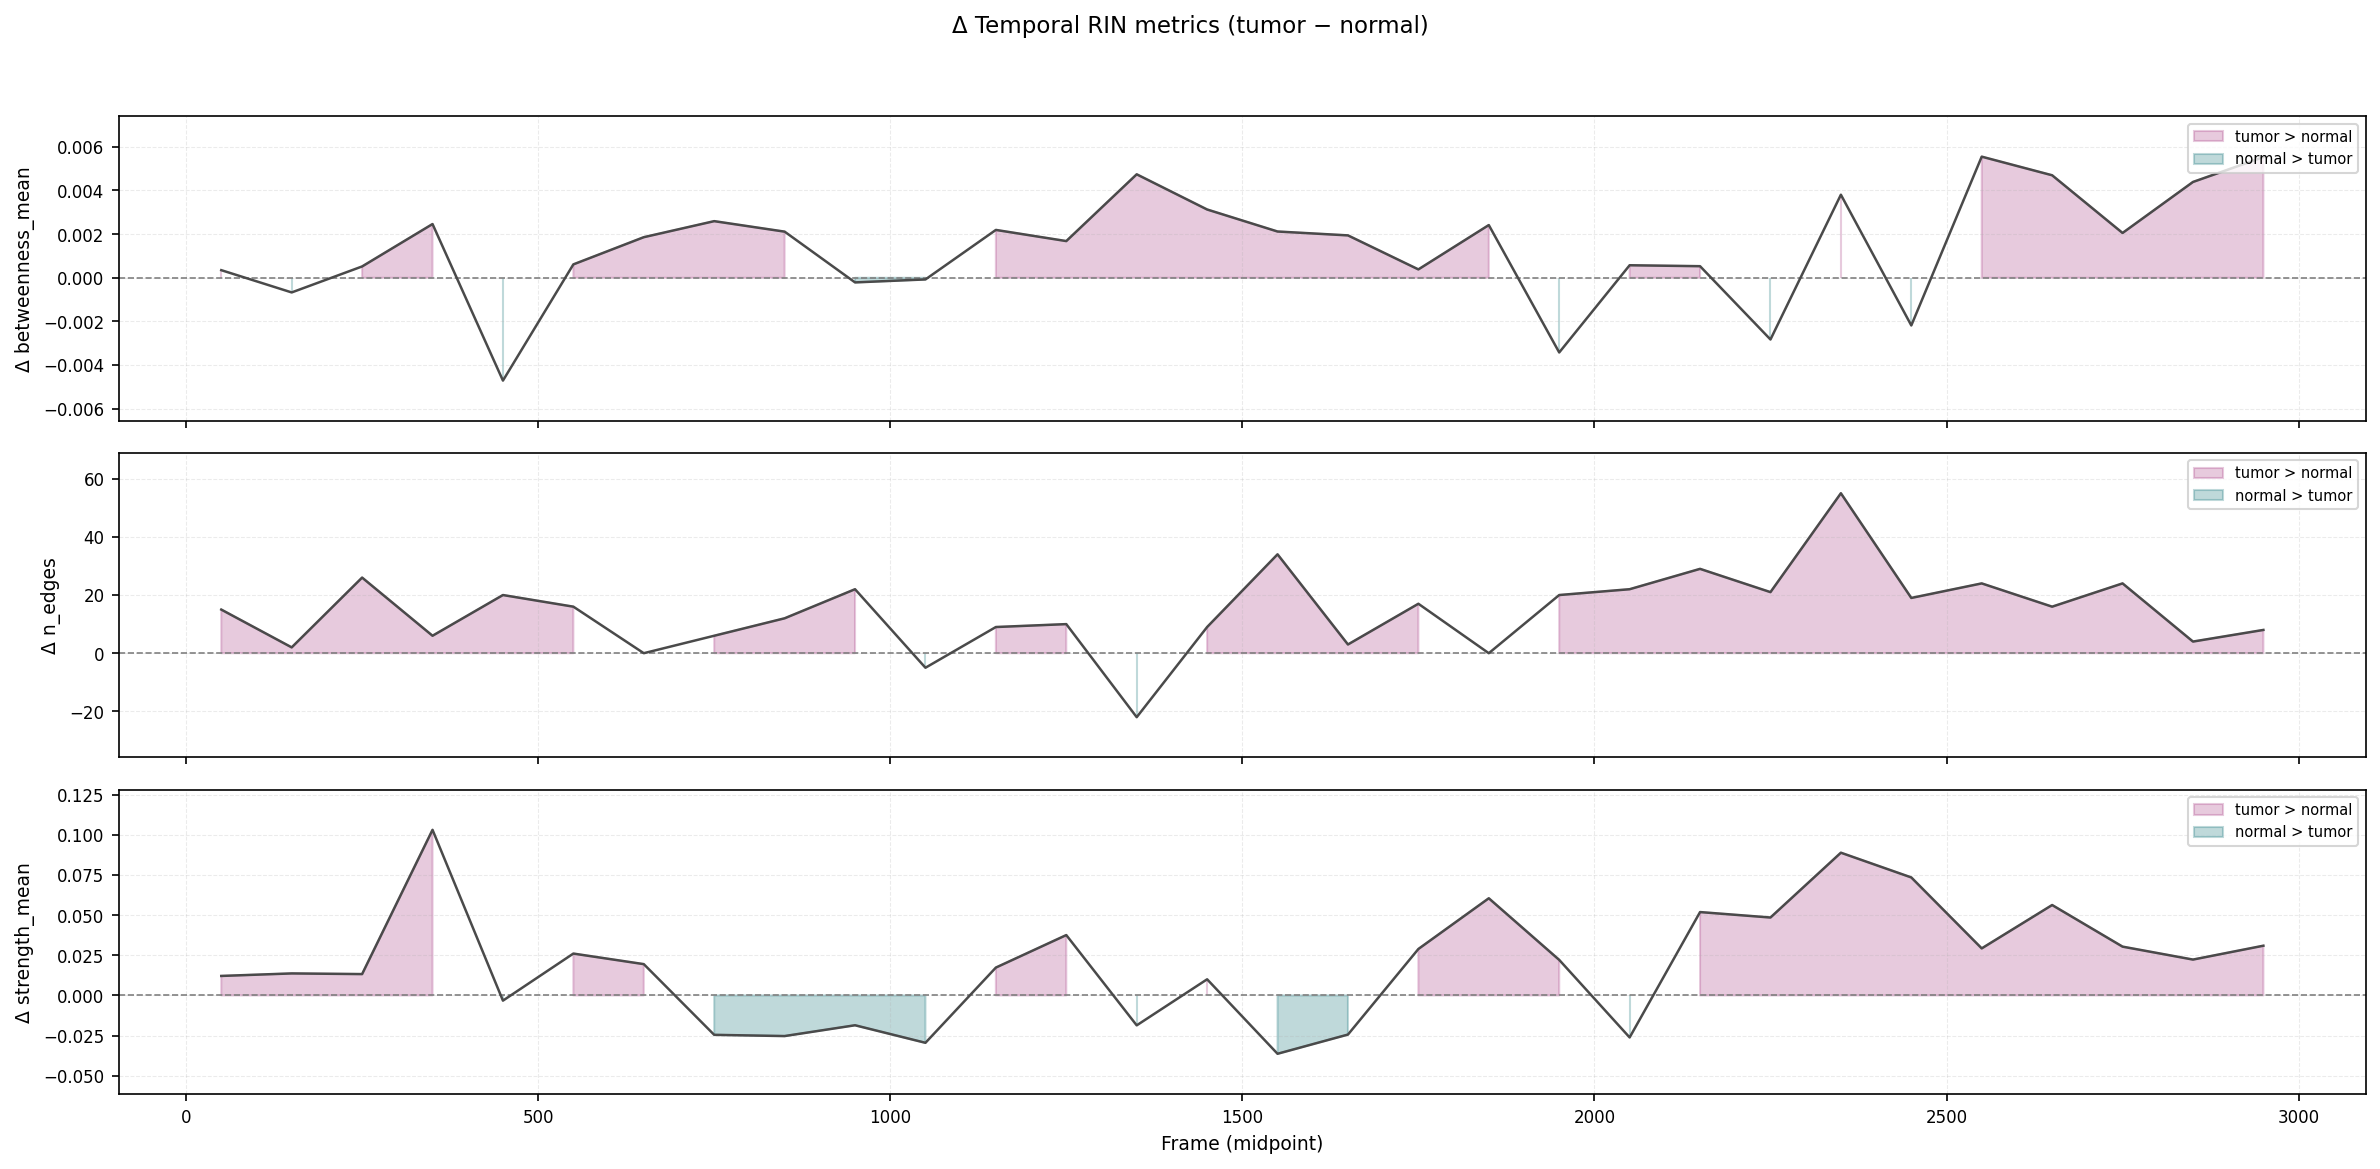

→ saved: /content/phase3b_outputs/figures/fig_temporal_rin_delta.png
→ saved: /content/phase3b_outputs/figures/fig_temporal_rin_delta.pdf


In [ ]:
# =====================================================================
# CELL 3B-TEMP-VIZ · Temporal RIN plots only
# autoscaled y-axis, saved to FIG_DIR
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if not TEMPORAL_RESULTS:
    print("[SKIP] TEMPORAL_RESULTS is empty — run CELL 3B-TEMP first")

else:
    COLORS = {"normal": "#01696f", "tumor": "#a12c7b"}

    metrics_to_plot = [
        ("modularity", "Modularity Q"),
        ("betweenness_mean", "Mean betweenness centrality"),
        ("n_edges", "N edges in window"),
        ("mean_degree", "Mean degree"),
        ("n_communities", "N communities (Louvain)"),
        ("strength_mean", "Mean contact strength"),
    ]

    def metric_has_data(metric, results_dict):
        for _, df in results_dict.items():
            if metric in df.columns:
                vals = pd.to_numeric(df[metric], errors="coerce").to_numpy(dtype=float)
                if np.isfinite(vals).any():
                    return True
        return False

    def get_ylim_from_series(series_list, pad_frac=0.12):
        vals = []
        for arr in series_list:
            arr = np.asarray(arr, dtype=float)
            arr = arr[np.isfinite(arr)]
            if arr.size:
                vals.append(arr)
        if not vals:
            return None

        allv = np.concatenate(vals)
        ymin = np.min(allv)
        ymax = np.max(allv)

        if np.isclose(ymin, ymax):
            center = float(ymin)
            pad = max(abs(center) * 0.05, 1e-3)
            return center - pad, center + pad

        yr = ymax - ymin
        pad = yr * pad_frac
        return ymin - pad, ymax + pad

    valid_metrics = [(m, lbl) for m, lbl in metrics_to_plot if metric_has_data(m, TEMPORAL_RESULTS)]

    if not valid_metrics:
        print("[SKIP] No valid temporal metrics to plot")

    else:
        fig, axes = plt.subplots(
            len(valid_metrics), 1,
            figsize=(16, 2.8 * len(valid_metrics)),
            sharex=True
        )

        if len(valid_metrics) == 1:
            axes = [axes]

        for ax, (metric, label) in zip(axes, valid_metrics):
            plotted_any = False
            y_for_limits = []

            for cond, df in TEMPORAL_RESULTS.items():
                if metric not in df.columns:
                    continue

                sub = df[["frame_mid", metric]].copy()
                sub[metric] = pd.to_numeric(sub[metric], errors="coerce")
                sub = sub.dropna(subset=["frame_mid", metric]).sort_values("frame_mid")

                if sub.empty:
                    continue

                x = sub["frame_mid"].to_numpy(dtype=float)
                y = sub[metric].to_numpy(dtype=float)
                color = COLORS.get(cond, "gray")

                y_smooth = pd.Series(y).rolling(5, center=True, min_periods=1).mean().to_numpy()
                mean_y = np.nanmean(y)

                # Заливка относительно средней, а не от 0
                if np.isfinite(mean_y):
                    ax.fill_between(x, y, mean_y, alpha=0.10, color=color)
                    ax.axhline(mean_y, color=color, ls="--", lw=0.9, alpha=0.6)

                ax.plot(x, y, color=color, lw=0.7, alpha=0.30)
                ax.plot(x, y_smooth, color=color, lw=2.0, label=cond)

                y_for_limits.extend([y, y_smooth])
                plotted_any = True

            ax.set_ylabel(label, fontsize=9)
            ax.tick_params(labelsize=8)
            ax.grid(alpha=0.25, linestyle="--", linewidth=0.5)

            ylim = get_ylim_from_series(y_for_limits, pad_frac=0.15)
            if ylim is not None:
                ax.set_ylim(*ylim)

            if plotted_any:
                ax.legend(fontsize=8, loc="upper right")
            else:
                ax.text(
                    0.5, 0.5, f"No valid data for {metric}",
                    transform=ax.transAxes,
                    ha="center", va="center",
                    fontsize=10, color="gray"
                )

        axes[-1].set_xlabel("Frame (midpoint of window)", fontsize=9)

        fig.suptitle(
            f"NaPi2b — Temporal RIN analysis\n"
            f"window={TEMP_WINDOW} fr | step={TEMP_STEP} fr | min_freq={TEMP_MIN_FREQ}",
            fontsize=11, y=0.995
        )
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.savefig(FIG_DIR / "fig_temporal_rin.png", dpi=300, bbox_inches="tight")
        plt.savefig(FIG_DIR / "fig_temporal_rin.pdf", dpi=300, bbox_inches="tight")
        plt.show()
        print(f"→ saved: {FIG_DIR / 'fig_temporal_rin.png'}")
        print(f"→ saved: {FIG_DIR / 'fig_temporal_rin.pdf'}")

    if "normal" in TEMPORAL_RESULTS and "tumor" in TEMPORAL_RESULTS:
        dn = TEMPORAL_RESULTS["normal"].copy().set_index("frame_mid")
        dt = TEMPORAL_RESULTS["tumor"].copy().set_index("frame_mid")
        common = dn.index.intersection(dt.index).sort_values()

        if len(common) == 0:
            print("[SKIP] No common frame_mid values for delta plot")

        else:
            delta_metrics_raw = [
                ("modularity", "Δ modularity"),
                ("betweenness_mean", "Δ betweenness_mean"),
                ("n_edges", "Δ n_edges"),
                ("strength_mean", "Δ strength_mean"),
            ]

            valid_delta_metrics = []
            for m, lbl in delta_metrics_raw:
                if m not in dn.columns or m not in dt.columns:
                    continue

                delta = (
                    pd.to_numeric(dt.loc[common, m], errors="coerce")
                    - pd.to_numeric(dn.loc[common, m], errors="coerce")
                )

                if np.isfinite(delta.to_numpy(dtype=float)).any():
                    valid_delta_metrics.append((m, lbl))

            if not valid_delta_metrics:
                print("[SKIP] No valid delta metrics to plot")

            else:
                fig2, axes2 = plt.subplots(
                    len(valid_delta_metrics), 1,
                    figsize=(16, 2.6 * len(valid_delta_metrics)),
                    sharex=True
                )

                if len(valid_delta_metrics) == 1:
                    axes2 = [axes2]

                for ax, (m, lbl) in zip(axes2, valid_delta_metrics):
                    delta = (
                        pd.to_numeric(dt.loc[common, m], errors="coerce")
                        - pd.to_numeric(dn.loc[common, m], errors="coerce")
                    ).astype(float)

                    valid_mask = np.isfinite(delta.to_numpy())
                    x = common.to_numpy(dtype=float)[valid_mask]
                    y = delta.to_numpy(dtype=float)[valid_mask]

                    if len(y) == 0:
                        ax.text(
                            0.5, 0.5, f"No valid data for {m}",
                            transform=ax.transAxes,
                            ha="center", va="center",
                            fontsize=10, color="gray"
                        )
                        continue

                    ax.axhline(0, color="gray", lw=0.8, ls="--")
                    ax.fill_between(x, y, 0, where=(y > 0), color="#a12c7b", alpha=0.25, label="tumor > normal")
                    ax.fill_between(x, y, 0, where=(y < 0), color="#01696f", alpha=0.25, label="normal > tumor")
                    ax.plot(x, y, color="#4a4a4a", lw=1.2)

                    ylim = get_ylim_from_series([y], pad_frac=0.18)
                    if ylim is not None:
                        ax.set_ylim(*ylim)

                    ax.set_ylabel(lbl, fontsize=9)
                    ax.tick_params(labelsize=8)
                    ax.grid(alpha=0.25, linestyle="--", linewidth=0.5)
                    ax.legend(fontsize=7, loc="upper right")

                axes2[-1].set_xlabel("Frame (midpoint)", fontsize=9)
                fig2.suptitle("Δ Temporal RIN metrics (tumor − normal)", fontsize=11, y=0.995)
                plt.tight_layout(rect=[0, 0, 1, 0.97])
                plt.savefig(FIG_DIR / "fig_temporal_rin_delta.png", dpi=300, bbox_inches="tight")
                plt.savefig(FIG_DIR / "fig_temporal_rin_delta.pdf", dpi=300, bbox_inches="tight")
                plt.show()
                print(f"→ saved: {FIG_DIR / 'fig_temporal_rin_delta.png'}")
                print(f"→ saved: {FIG_DIR / 'fig_temporal_rin_delta.pdf'}")

### Step 9c — Temporal RIN: convergence & divergence statistics

Coefficient of Variation, MWU стационарности (первая/вторая половина),  
первый фрейм расхождения tumor–normal > 2σ.  
Экспорт: `temporal_convergence.csv`, `temporal_divergence.csv`.

In [ ]:
# =====================================================================
# CELL 3B-TEMP-STAT  ·  Temporal RIN — convergence & divergence stats
# =====================================================================
# 1. Convergence check: coefficient of variation (CV) per metric
# 2. MWU test: first half vs second half of trajectory (stationarity)
# 3. Point of divergence: first frame where |tumor−normal| > 2σ(normal)
# 4. Export: temporal_convergence.csv, temporal_divergence.csv
# =====================================================================

import numpy as np
import pandas as pd
from scipy import stats

if not TEMPORAL_RESULTS:
    print("[SKIP] TEMPORAL_RESULTS is empty")
else:
    METRICS_STAT = ["modularity","betweenness_mean","n_edges",
                    "mean_degree","strength_mean","density"]

    # ── 1. Convergence: CV + stationarity MWU ─────────────────────
    conv_rows = []
    for cond, df in TEMPORAL_RESULTS.items():
        half = len(df) // 2
        for m in METRICS_STAT:
            if m not in df.columns:
                continue
            vals = df[m].dropna().values
            if len(vals) < 4:
                continue
            cv = np.std(vals) / (np.mean(vals) + 1e-12)
            first_h = vals[:half]
            second_h = vals[half:]
            stat, pval = stats.mannwhitneyu(first_h, second_h, alternative="two-sided")
            conv_rows.append({
                "condition": cond,
                "metric":    m,
                "mean":      np.mean(vals),
                "std":       np.std(vals),
                "cv":        cv,
                "mwu_stat":  stat,
                "mwu_pval":  pval,
                "converged": pval > 0.05,   # H0: same distribution
            })

    df_conv = pd.DataFrame(conv_rows)
    df_conv.to_csv(OUT_DIR / "temporal_convergence.csv", index=False)
    print("\n=== Convergence summary ===")
    print(df_conv[["condition","metric","cv","mwu_pval","converged"]].to_string(index=False))

    # ── 2. Divergence: first frame where tumor deviates > 2σ normal ─
    div_rows = []
    if "normal" in TEMPORAL_RESULTS and "tumor" in TEMPORAL_RESULTS:
        dn = TEMPORAL_RESULTS["normal"].set_index("frame_mid")
        dt = TEMPORAL_RESULTS["tumor"].set_index("frame_mid")
        common = dn.index.intersection(dt.index)

        for m in METRICS_STAT:
            if m not in dn.columns or m not in dt.columns:
                continue
            n_vals  = dn.loc[common, m].values
            t_vals  = dt.loc[common, m].values
            mu_n    = np.nanmean(n_vals)
            sig_n   = np.nanstd(n_vals)
            delta   = np.abs(t_vals - n_vals)
            thresh  = 2.0 * sig_n

            diverge_idx = np.where(delta > thresh)[0]
            first_frame = int(common[diverge_idx[0]]) if len(diverge_idx) > 0 else None
            frac_div    = len(diverge_idx) / len(common) if len(common) > 0 else 0

            div_rows.append({
                "metric":              m,
                "normal_mean":         round(mu_n, 5),
                "normal_std":          round(sig_n, 5),
                "divergence_threshold": round(thresh, 5),
                "first_divergence_frame": first_frame,
                "fraction_diverged":   round(frac_div, 3),
            })

        df_div = pd.DataFrame(div_rows)
        df_div.to_csv(OUT_DIR / "temporal_divergence.csv", index=False)
        print("\n=== Divergence (tumor vs normal, 2σ threshold) ===")
        print(df_div.to_string(index=False))

    print("\n→ temporal_convergence.csv, temporal_divergence.csv saved")


=== Convergence summary ===
condition           metric       cv  mwu_pval  converged
   normal betweenness_mean 0.221996  0.868226       True
   normal          n_edges 0.011814  0.589283       True
   normal      mean_degree 0.010382  0.171069       True
   normal    strength_mean 0.011781  0.074496       True
   normal          density 0.017110  0.245485       True
    tumor betweenness_mean 0.160420  0.618670       True
    tumor          n_edges 0.009917  0.007399      False
    tumor      mean_degree 0.008406  1.000000       True
    tumor    strength_mean 0.009669  0.406787       True
    tumor          density 0.014844  0.071153       True

=== Divergence (tumor vs normal, 2σ threshold) ===
          metric  normal_mean  normal_std  divergence_threshold  first_divergence_frame  fraction_diverged
      modularity          NaN         NaN                   NaN                     NaN              0.000
betweenness_mean      0.00869     0.00193               0.00386               

## Visualisations
### Fig 1 — Δ Centrality heatmap (per-metric z-score)

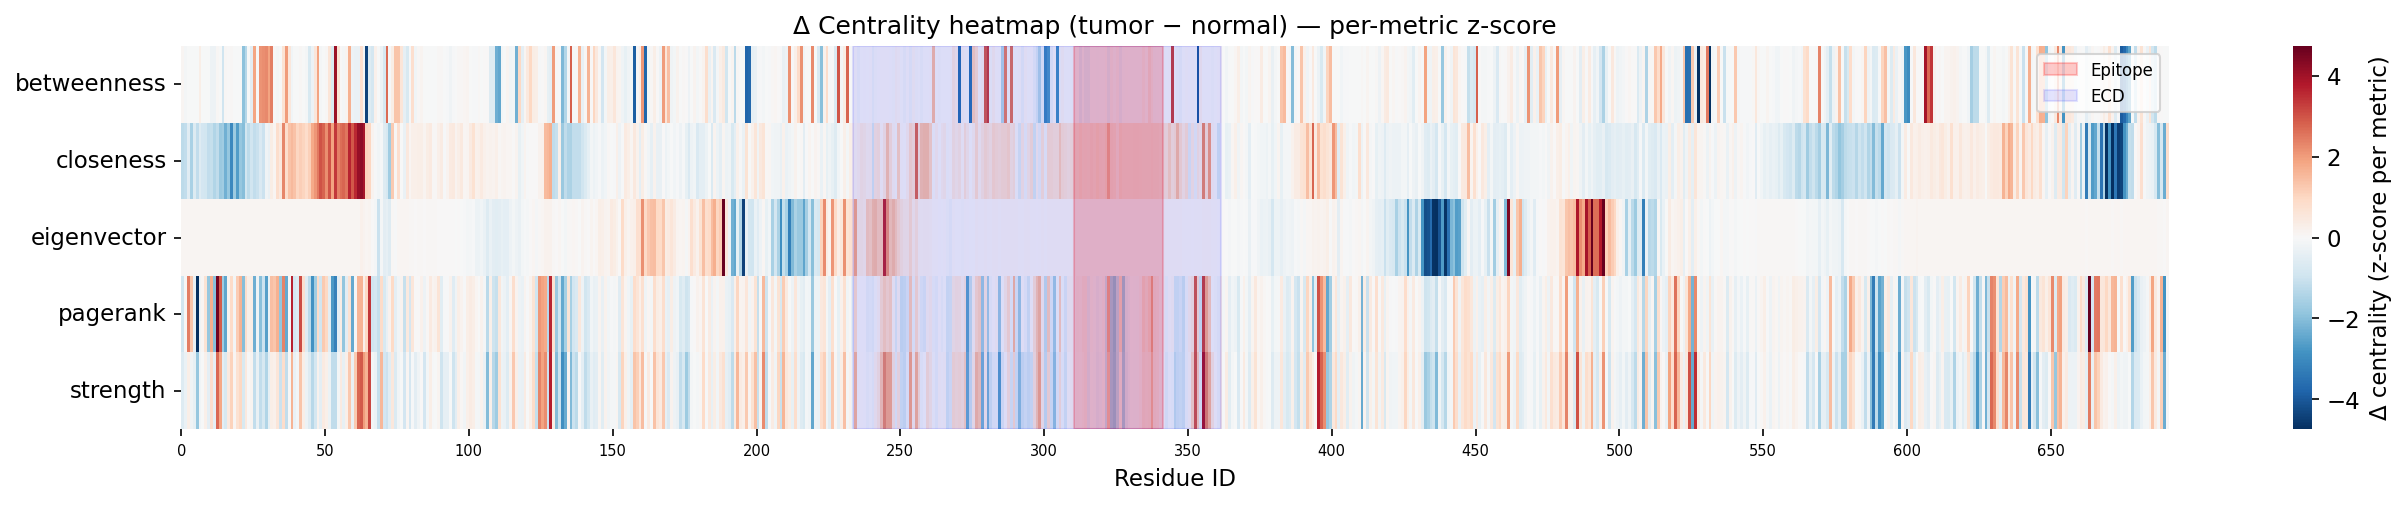

In [ ]:
metrics_viz=['betweenness','closeness','eigenvector','pagerank','strength']
delta_heat=DELTA_DF.sort_values('resid').set_index('resid')[metrics_viz].astype(float)

# Per-metric z-score normalisation (avoids strength dominating the colour scale)
delta_heat_T=delta_heat.T.copy()
delta_heat_znorm=delta_heat_T.apply(lambda row: (row-row.mean())/(row.std()+1e-12), axis=1)

fig,ax=plt.subplots(figsize=(18,3.5))
vmax=float(np.abs(delta_heat_znorm.values).max())*0.6
sns.heatmap(delta_heat_znorm,cmap='RdBu_r',center=0,vmin=-vmax,vmax=vmax,ax=ax,
            xticklabels=False,yticklabels=True,cbar_kws={'label':'Δ centrality (z-score per metric)'})
ax.set_xlabel('Residue ID')
ax.set_title('Δ Centrality heatmap (tumor − normal) — per-metric z-score')
resids_s=delta_heat.index.tolist()
xs_ep =[i for i,r in enumerate(resids_s) if r in EPITOPE_RESIDS]
xs_ecd=[i for i,r in enumerate(resids_s) if r in ECD_RESIDS_ALL]
if xs_ep:  ax.axvspan(min(xs_ep)-0.5, max(xs_ep)+0.5, alpha=0.20,color='red', label='Epitope')
if xs_ecd: ax.axvspan(min(xs_ecd)-0.5,max(xs_ecd)+0.5,alpha=0.10,color='blue',label='ECD')
tick_step=50; tp=[i for i,r in enumerate(resids_s) if r%tick_step==0]
ax.set_xticks(tp); ax.set_xticklabels([resids_s[i] for i in tp],fontsize=7)
ax.legend(loc='upper right',fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/'fig1_delta_centrality_heatmap.png',dpi=300,bbox_inches='tight'); plt.show()


### Fig 2 — Volcano plot

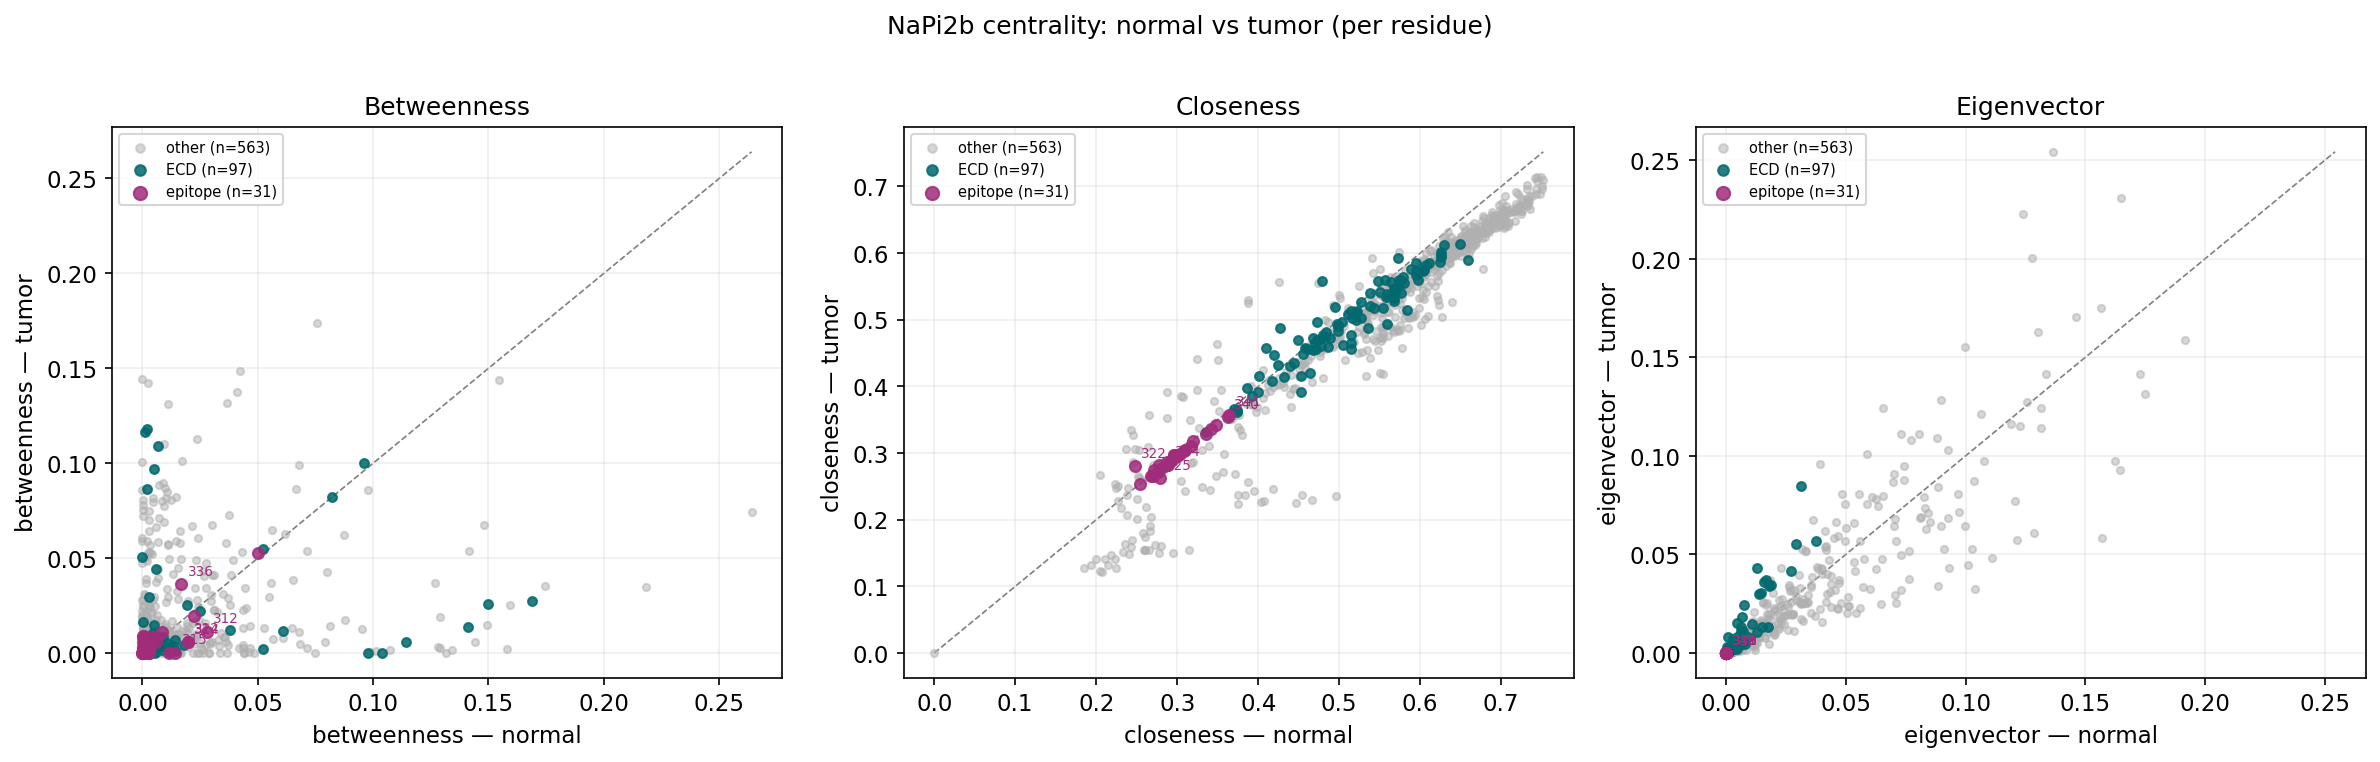

Saved fig2_scatter_normal_vs_tumor.png


In [ ]:
# Fig 2 — Scatter: centrality normal vs tumor (per residue)
# Точка выше диагонали → остаток усиливается в опухоли, ниже → ослабевает

metrics_scatter = ['betweenness', 'closeness', 'eigenvector']
region_color = {'epitope': '#a12c7b', 'ECD': '#01696f', 'other': '#b0b0b0'}
region_zorder = {'other': 1, 'ECD': 2, 'epitope': 3}
region_size   = {'other': 12, 'ECD': 18, 'epitope': 28}

cn = CENTRALITY['normal'].set_index('resid')
ct = CENTRALITY['tumor'].set_index('resid')
shared = sorted(set(cn.index) & set(ct.index))

def get_region(resid):
    if resid in EPITOPE_RESIDS: return 'epitope'
    if resid in ECD_RESIDS_ALL: return 'ECD'
    return 'other'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, m in zip(axes, metrics_scatter):
    vn = np.array([cn.at[r, m] for r in shared])
    vt = np.array([ct.at[r, m] for r in shared])
    regions = [get_region(r) for r in shared]

    # Рисуем от фона к переднему плану
    for reg in ['other', 'ECD', 'epitope']:
        idx = [i for i, rg in enumerate(regions) if rg == reg]
        ax.scatter(
            vn[idx], vt[idx],
            c=region_color[reg], s=region_size[reg],
            alpha=0.5 if reg == 'other' else 0.85,
            zorder=region_zorder[reg],
            label=f'{reg} (n={len(idx)})'
        )

    # Диагональ y = x
    vmin = min(vn.min(), vt.min())
    vmax = max(vn.max(), vt.max())
    ax.plot([vmin, vmax], [vmin, vmax], 'k--', lw=0.8, alpha=0.5, zorder=0)

    # Аннотировать топ-5 по |Δ| в эпитопе
    ep_idx = [i for i, rg in enumerate(regions) if rg == 'epitope']
    if ep_idx:
        ep_delta = np.abs(vt[ep_idx] - vn[ep_idx])
        top5 = sorted(ep_idx, key=lambda i: abs(vt[i]-vn[i]), reverse=True)[:5]
        for i in top5:
            ax.annotate(
                str(shared[i]),
                (vn[i], vt[i]),
                fontsize=6.5, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points',
                color='#a12c7b'
            )

    ax.set_xlabel(f'{m} — normal')
    ax.set_ylabel(f'{m} — tumor')
    ax.set_title(m.capitalize())
    ax.legend(fontsize=7, markerscale=1.2)
    ax.grid(alpha=0.2)

plt.suptitle('NaPi2b centrality: normal vs tumor (per residue)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_scatter_normal_vs_tumor.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig2_scatter_normal_vs_tumor.png')

### Fig 3 — Community bar along sequence

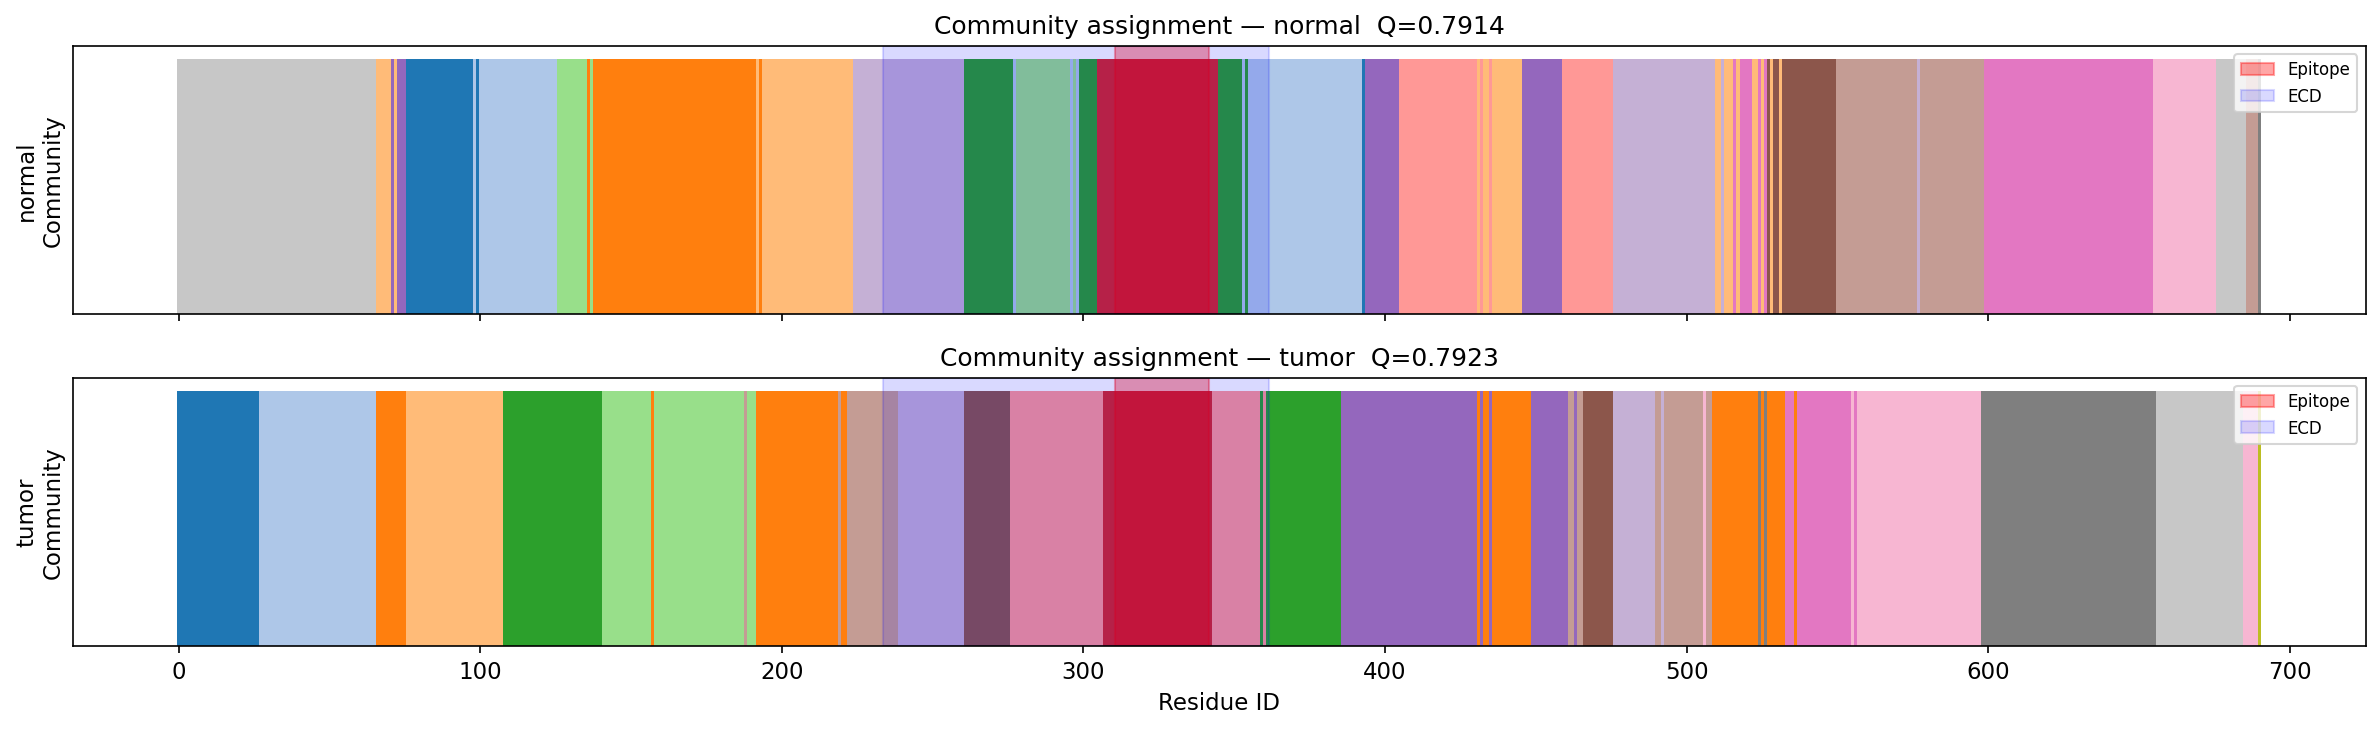

In [ ]:
fig,axes=plt.subplots(2,1,figsize=(16,5),sharex=True)
cmap_comm=plt.get_cmap('tab20')
for ax,cond in zip(axes,CONDITIONS):
    df=CENTRALITY[cond].sort_values('resid')
    resids_c=df['resid'].values; comms_c=df['community'].values
    colors_c=[cmap_comm(int(c)%20) for c in comms_c]
    ax.bar(resids_c,np.ones(len(resids_c)),color=colors_c,width=1.0,linewidth=0)
    ep_xs=[r for r in resids_c if r in EPITOPE_RESIDS]
    ecd_xs=[r for r in resids_c if r in ECD_RESIDS_ALL]
    if ep_xs:  ax.axvspan(min(ep_xs)-0.5, max(ep_xs)+0.5, alpha=0.35,color='red', label='Epitope')
    if ecd_xs: ax.axvspan(min(ecd_xs)-0.5,max(ecd_xs)+0.5,alpha=0.15,color='blue',label='ECD')
    ax.set_ylabel(f'{cond}\nCommunity'); ax.set_yticks([])
    ax.legend(loc='upper right',fontsize=8)
    ax.set_title(f'Community assignment — {cond}  Q={MODULARITY[cond]:.4f}')
axes[-1].set_xlabel('Residue ID')
plt.tight_layout(); plt.savefig(FIG_DIR/'fig3_community_bar.png',dpi=300,bbox_inches='tight'); plt.show()

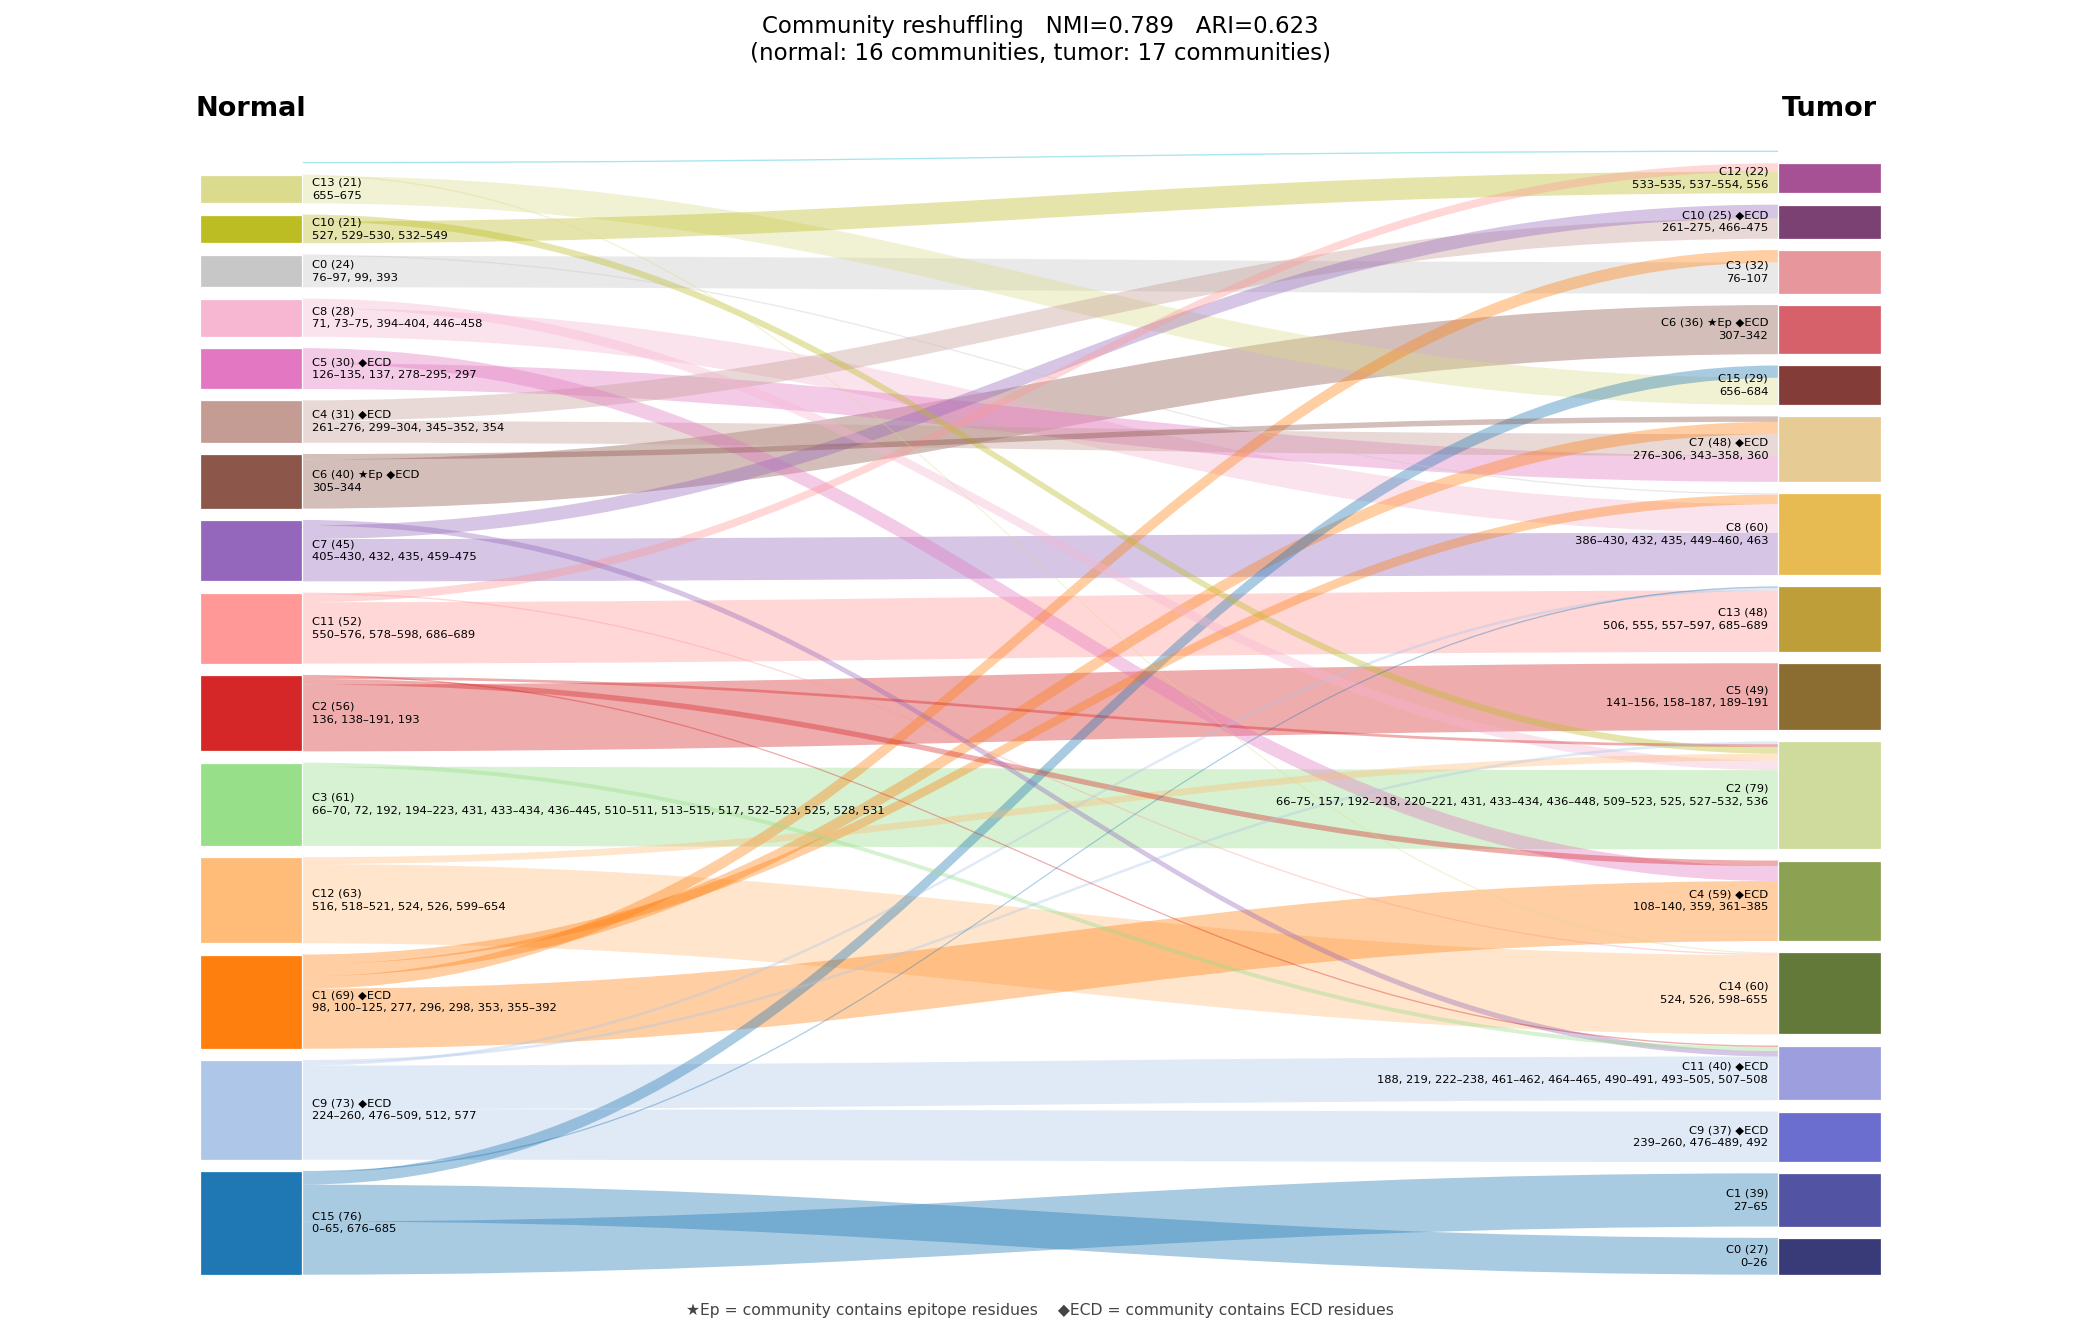

Saved: /content/phase3b_outputs/figures/fig3b_alluvial.png
Saved: /content/phase3b_outputs/figures/fig3b_alluvial.pdf


In [ ]:
# Fig 3b — Alluvial: community reshuffling normal → tumor

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from collections import Counter

part_n = PARTITIONS['normal']
part_t = PARTITIONS['tumor']
shared_r = sorted(set(part_n) & set(part_t))

transitions = Counter((part_n[r], part_t[r]) for r in shared_r)
size_n = Counter(part_n[r] for r in shared_r)
size_t = Counter(part_t[r] for r in shared_r)
total = len(shared_r)

gap = 0.012

# Левая сторона — по убыванию размера
comms_n = sorted(size_n, key=lambda c: -size_n[c])

# Временно вычислить Y левой стороны
_y_n_tmp = {}
_cur = 0.0
for c in comms_n:
    _y_n_tmp[c] = _cur + (size_n[c] / total) / 2
    _cur += size_n[c] / total + gap

# Правая сторона — по средневзвешенной Y входящих потоков
def weighted_y_t(ct):
    total_flow = 0
    weighted_sum = 0.0
    for (cn, ct2), count in transitions.items():
        if ct2 == ct:
            weighted_sum += _y_n_tmp[cn] * count
            total_flow += count
    return weighted_sum / total_flow if total_flow else 0.0

comms_t = sorted(size_t, key=weighted_y_t)

cmap_n = plt.get_cmap('tab20')
cmap_t = plt.get_cmap('tab20b')
color_n = {c: cmap_n(i / max(len(comms_n), 1)) for i, c in enumerate(comms_n)}
color_t = {c: cmap_t(i / max(len(comms_t), 1)) for i, c in enumerate(comms_t)}

# Вычислить стартовые Y для каждого сообщества
def calc_y(comms, sizes):
    y = {}
    cur = 0.0
    for c in comms:
        y[c] = cur
        cur += sizes[c] / total + gap
    return y

y_n = calc_y(comms_n, size_n)
y_t = calc_y(comms_t, size_t)
y_max = max(
    max(y_n[c] + size_n[c] / total for c in comms_n),
    max(y_t[c] + size_t[c] / total for c in comms_t)
)

fig, ax = plt.subplots(figsize=(14, 9))

# Потоки
y_n_cursor = dict(y_n)
y_t_cursor = dict(y_t)

for (cn, ct), count in sorted(transitions.items(), key=lambda x: -x[1]):
    h = count / total
    y0 = y_n_cursor[cn]
    y1 = y_t_cursor[ct]

    verts = [
        (0.14, y0),
        (0.45, y0), (0.55, y1), (0.86, y1),
        (0.86, y1 + h),
        (0.55, y1 + h), (0.45, y0 + h), (0.14, y0 + h),
        (0.14, y0),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CLOSEPOLY,
    ]

    col = (*color_n[cn][:3], 0.38)
    ax.add_patch(mpatches.PathPatch(Path(verts, codes), fc=col, ec='none', zorder=2))

    y_n_cursor[cn] += h
    y_t_cursor[ct] += h

def comm_ranges(partition, comm_id):
    resids = sorted(r for r, c in partition.items() if c == comm_id)
    if not resids:
        return ''
    ranges = []
    start = prev = resids[0]
    for r in resids[1:]:
        if r == prev + 1:
            prev = r
        else:
            ranges.append(f'{start}–{prev}' if start != prev else str(start))
            start = prev = r
    ranges.append(f'{start}–{prev}' if start != prev else str(start))
    return ', '.join(ranges)

def comm_badge(partition, comm_id):
    resids = set(r for r, c in partition.items() if c == comm_id)
    badge = ''
    if resids & EPITOPE_RESIDS:
        badge += ' ★Ep'
    if resids & ECD_ONLY:
        badge += ' ◆ECD'
    return badge

# Блоки слева
for c in comms_n:
    h = size_n[c] / total
    yc = y_n[c]
    ax.add_patch(mpatches.Rectangle(
        (0.09, yc), 0.05, h,
        fc=color_n[c], ec='white', lw=0.6, zorder=4
    ))
    if h > 0.02:
        label = f'C{c} ({size_n[c]}){comm_badge(part_n, c)}\n{comm_ranges(part_n, c)}'
        ax.text(
            0.145, yc + h / 2, label,
            ha='left', va='center', fontsize=5.5,
            clip_on=False, zorder=5, linespacing=1.4
        )

# Блоки справа
for c in comms_t:
    h = size_t[c] / total
    yc = y_t[c]
    ax.add_patch(mpatches.Rectangle(
        (0.86, yc), 0.05, h,
        fc=color_t[c], ec='white', lw=0.6, zorder=4
    ))
    if h > 0.02:
        label = f'C{c} ({size_t[c]}){comm_badge(part_t, c)}\n{comm_ranges(part_t, c)}'
        ax.text(
            0.855, yc + h / 2, label,
            ha='right', va='center', fontsize=5.5,
            clip_on=False, zorder=5, linespacing=1.4
        )

# Подпись
ax.text(
    0.5, -0.03,
    '★Ep = community contains epitope residues    ◆ECD = community contains ECD residues',
    ha='center', va='top', fontsize=7.5, color='#444444',
    transform=ax.transData, clip_on=False
)

# Заголовки сторон
pad = 0.03
ax.text(0.115, y_max + pad, 'Normal', ha='center', va='bottom',
        fontsize=13, fontweight='bold')
ax.text(0.885, y_max + pad, 'Tumor', ha='center', va='bottom',
        fontsize=13, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(-0.01, y_max + pad + 0.04)
ax.axis('off')
ax.set_title(
    f'Community reshuffling   NMI={NMI:.3f}   ARI={ARI:.3f}\n'
    f'(normal: {len(comms_n)} communities, tumor: {len(comms_t)} communities)',
    fontsize=11, pad=12
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3b_alluvial.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig3b_alluvial.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIG_DIR / 'fig3b_alluvial.png'}")
print(f"Saved: {FIG_DIR / 'fig3b_alluvial.pdf'}")

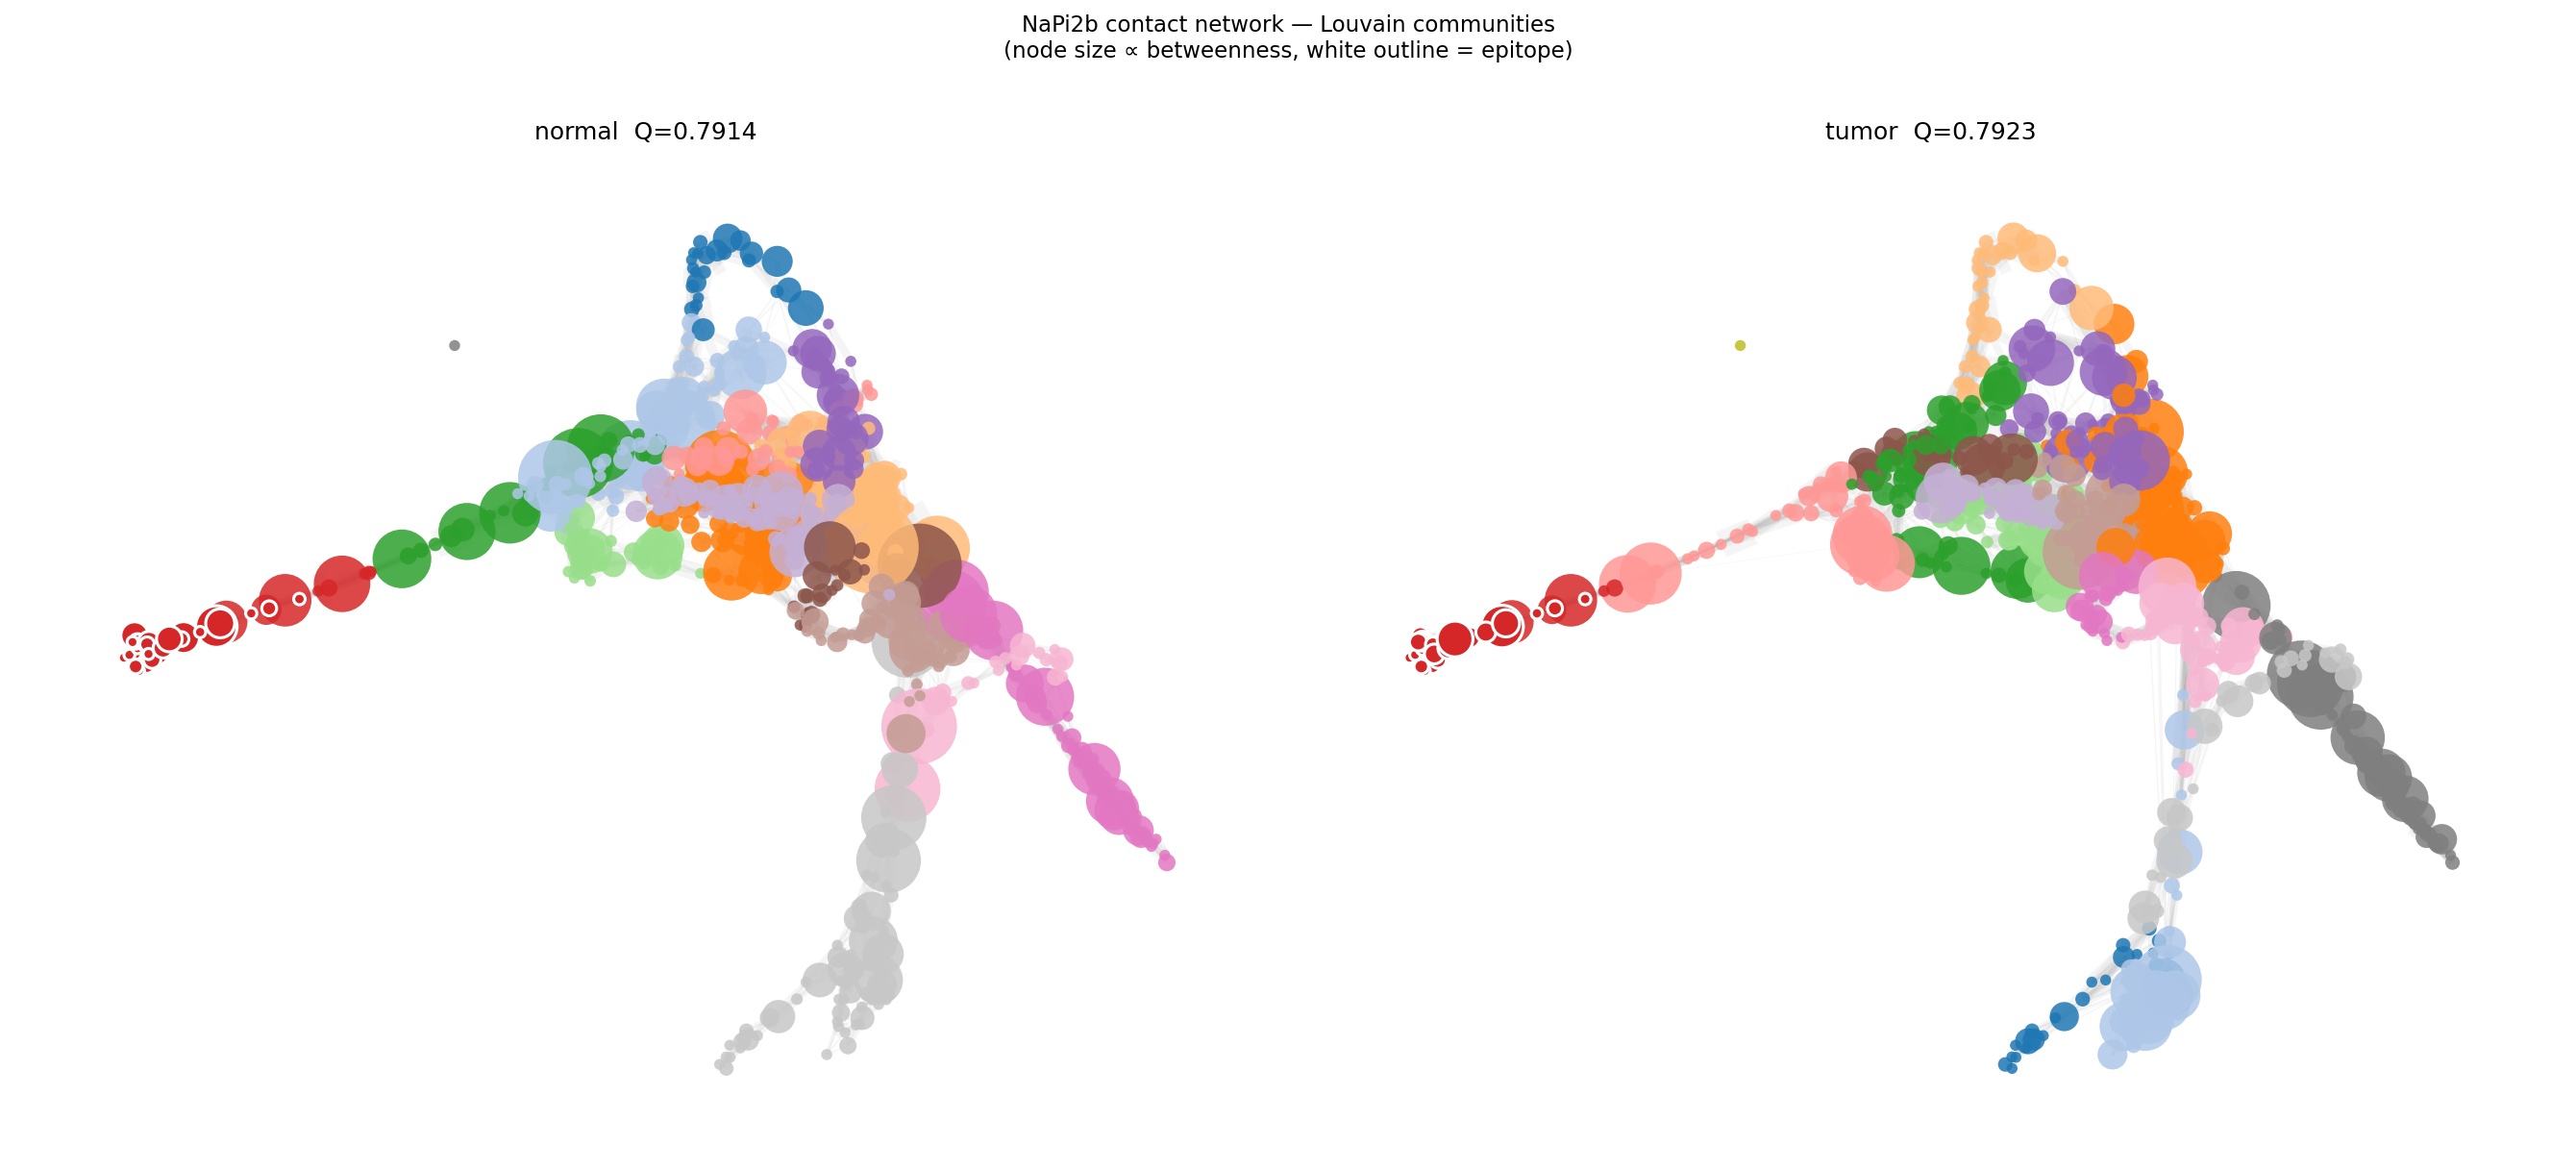

In [ ]:
# Fig 3c — Network spring layout, colored by community
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
cmap_comm = plt.get_cmap('tab20')

# Один layout для обоих условий (для сравнимости)
pos = nx.spring_layout(GRAPHS['normal'], weight='contact_freq',
                       seed=42, k=0.15, iterations=60)

for ax, cond in zip(axes, CONDITIONS):
    G = GRAPHS[cond]
    part = PARTITIONS[cond]
    cent = CENTRALITY[cond].set_index('resid')

    node_colors, node_sizes, edge_alphas = [], [], []
    for n in G.nodes():
        c = part.get(n, -1)
        node_colors.append(cmap_comm(c % 20 / 20))
        bw = float(cent.at[n, 'betweenness']) if n in cent.index else 0
        node_sizes.append(30 + bw * 8000)

    # Рёбра
    edges = list(G.edges(data=True))
    edge_w = [d.get('contact_freq', 0.3) for _, _, d in edges]

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.08,
                           width=[w*0.8 for w in edge_w], edge_color='#888888')
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors, node_size=node_sizes,
                           alpha=0.85, linewidths=0)

    # Эпитоп — белая обводка
    ep_nodes = [n for n in G.nodes() if n in EPITOPE_RESIDS]
    nx.draw_networkx_nodes(G, pos, nodelist=ep_nodes, ax=ax,
                           node_color=[node_colors[list(G.nodes()).index(n)] for n in ep_nodes],
                           node_size=[30 + float(cent.at[n,'betweenness'] if n in cent.index else 0)*8000
                                      for n in ep_nodes],
                           edgecolors='white', linewidths=1.5, alpha=1.0)

    ax.set_title(f'{cond}  Q={MODULARITY[cond]:.4f}', fontsize=12)
    ax.axis('off')

plt.suptitle('NaPi2b contact network — Louvain communities\n'
             '(node size ∝ betweenness, white outline = epitope)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/'fig3c_network_communities.png', dpi=300, bbox_inches='tight')
plt.show()

### Fig 4 — Subgraph top-30 betweenness (normal | tumor)

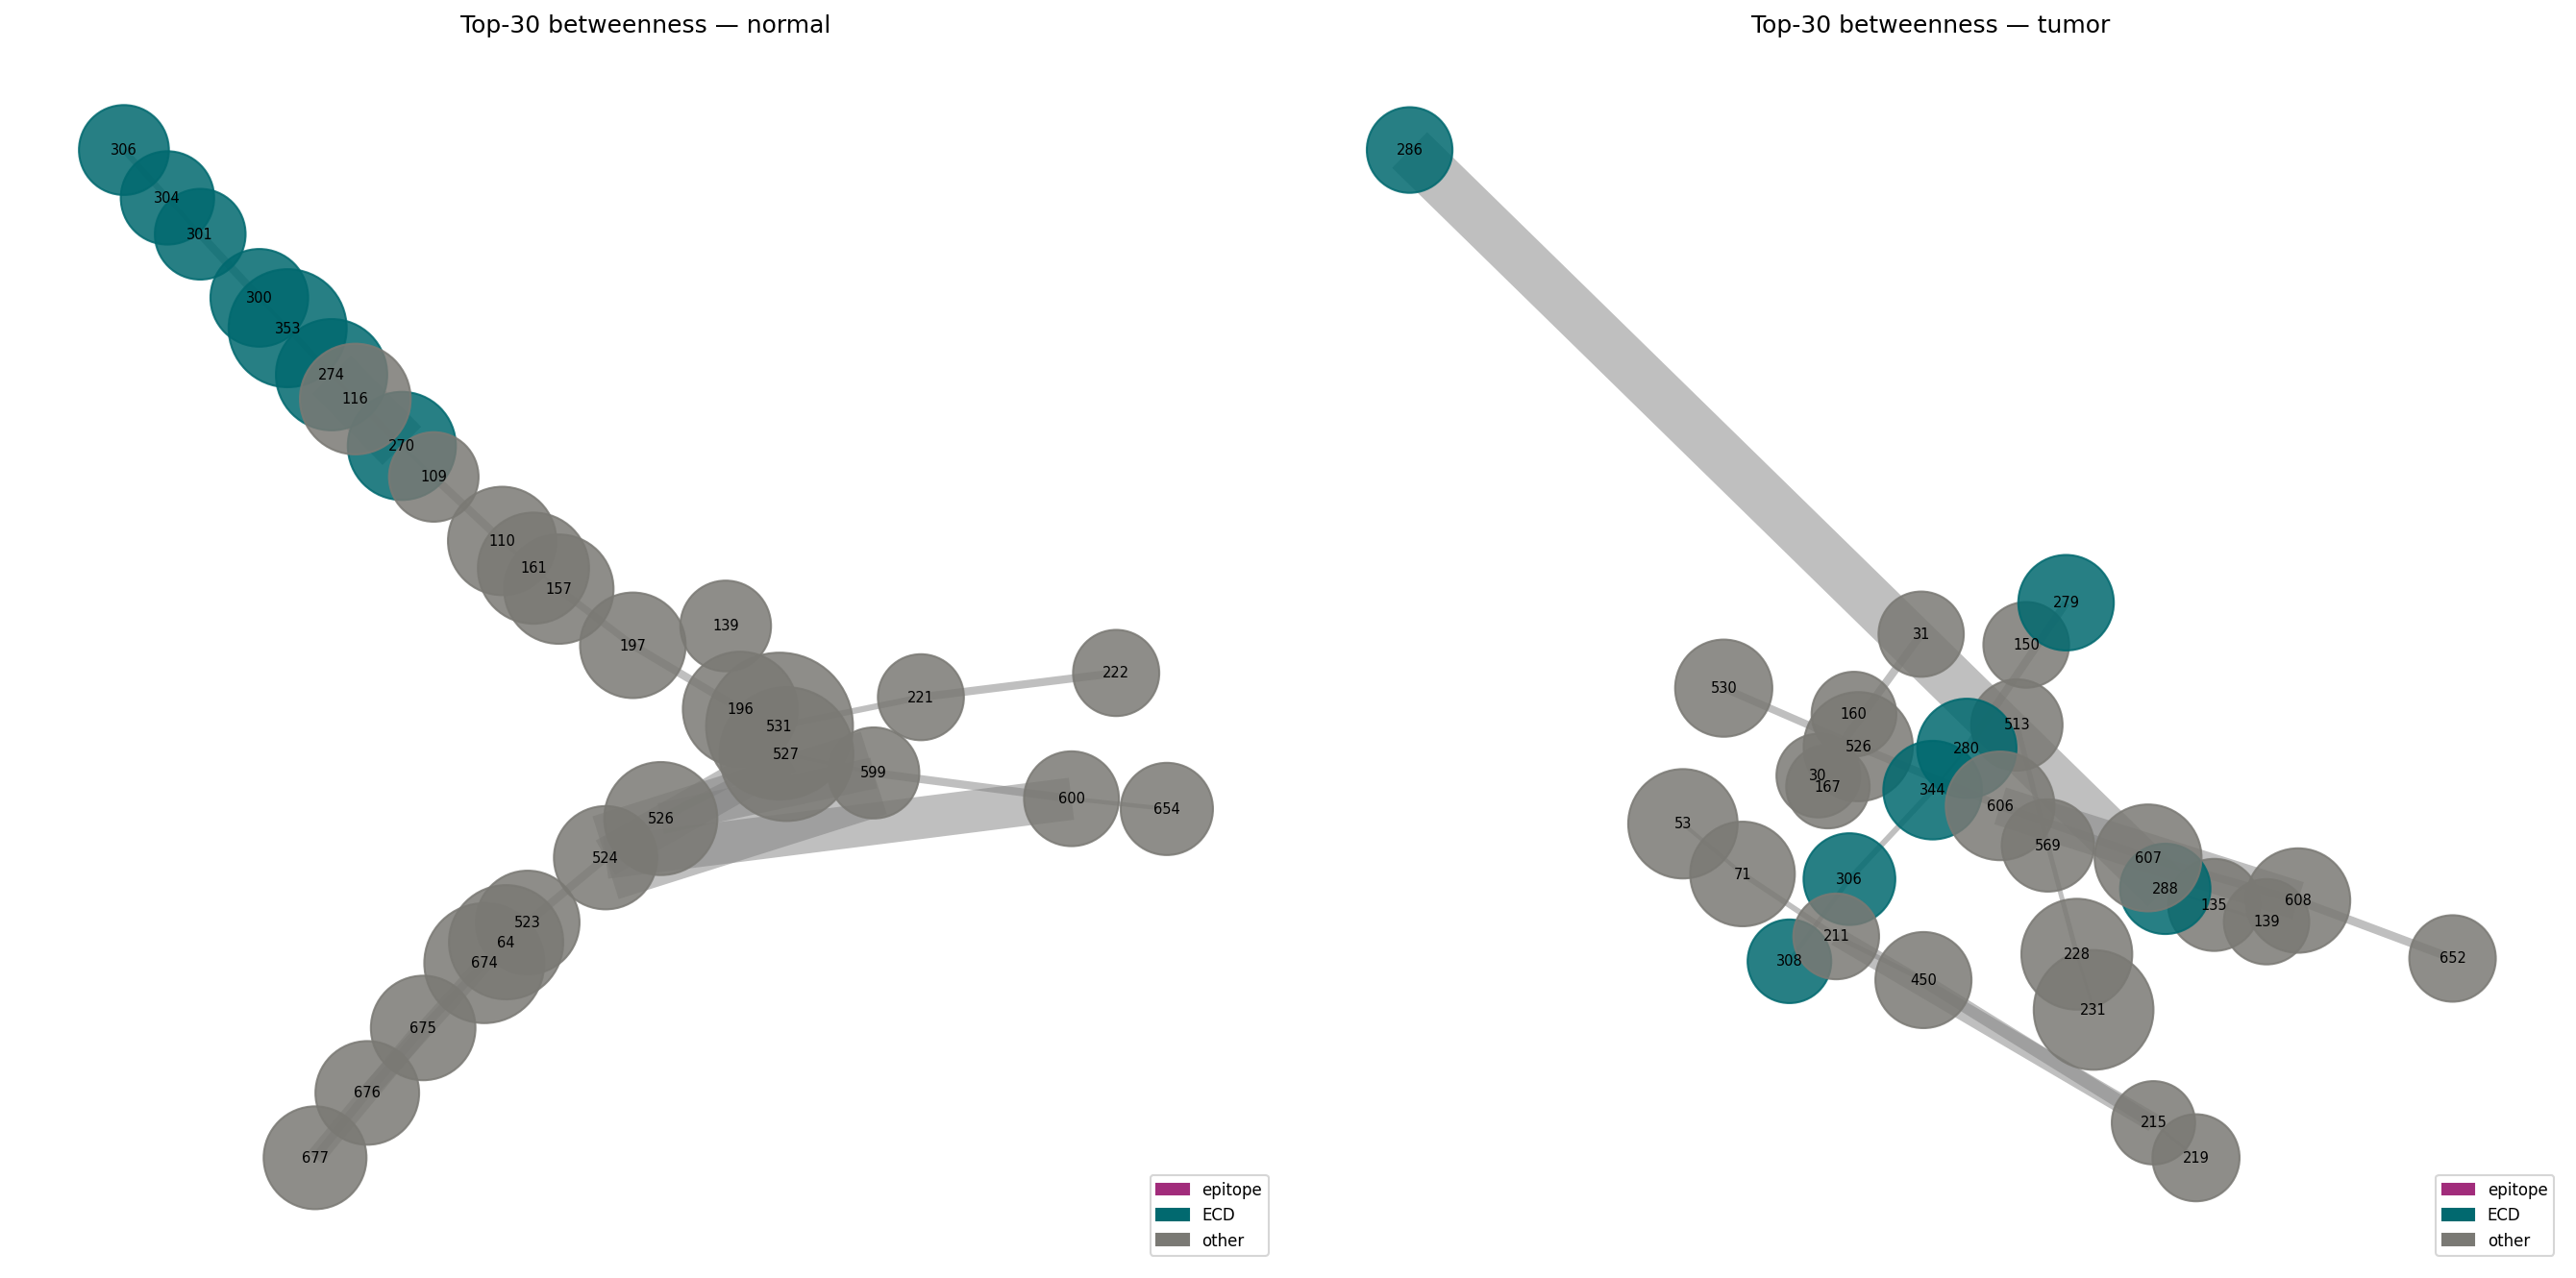

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(18,9))
region_color={'epitope':'#a12c7b','ECD':'#01696f','other':'#7a7974'}
for ax,cond in zip(axes,CONDITIONS):
    df=CENTRALITY[cond]
    top30=df.nlargest(30,'betweenness')['resid'].tolist()
    Gsub=GRAPHS[cond].subgraph(top30).copy()
    pos=nx.kamada_kawai_layout(Gsub,weight='contact_freq')
    ri=df.set_index('resid')
    ns=[ri.at[n,'betweenness']*20000+100 for n in Gsub.nodes()]
    nc_=[region_color.get(ri.at[n,'region'],'#7a7974') for n in Gsub.nodes()]
    ew=[Gsub[u][v]['contact_freq']*4 for u,v in Gsub.edges()]
    nx.draw_networkx_nodes(Gsub,pos,ax=ax,node_size=ns,node_color=nc_,alpha=0.85)
    nx.draw_networkx_edges(Gsub,pos,ax=ax,width=ew,alpha=0.5,edge_color='gray')
    nx.draw_networkx_labels(Gsub,pos,ax=ax,labels={n:str(n) for n in Gsub.nodes()},font_size=7)
    ax.set_title(f'Top-30 betweenness — {cond}',fontsize=12); ax.axis('off')
    patches=[mpatches.Patch(color=v,label=k) for k,v in region_color.items()]
    ax.legend(handles=patches,fontsize=8,loc='lower right')
plt.tight_layout(); plt.savefig(FIG_DIR/'fig4_subgraph_top30.png',dpi=300,bbox_inches='tight'); plt.show()

### Fig 5 — Allosteric pathway subgraph

In [ ]:
# for cond in CONDITIONS:
#     paths=ALLOSTERIC[cond]
#     if not paths: print(f'{cond}: no paths to visualise'); continue
#     all_nodes=sorted(set(r for p in paths for r in p['path']))
#     Gp=GRAPHS[cond].subgraph(all_nodes).copy()
#     pos=nx.kamada_kawai_layout(Gp,weight='contact_freq')
#     src_set=set(p['src'] for p in paths); tgt_set=set(p['tgt'] for p in paths)
#     nc_=['#a12c7b' if n in src_set else '#da7101' if n in tgt_set else '#01696f' for n in Gp.nodes()]
#     path_edges={(min(a,b),max(a,b)) for p in paths for a,b in zip(p['path'][:-1],p['path'][1:])}
#     ec=['#a12c7b' if (min(u,v),max(u,v)) in path_edges else '#d4d1ca' for u,v in Gp.edges()]
#     ew2=[2.5 if (min(u,v),max(u,v)) in path_edges else 0.8 for u,v in Gp.edges()]
#     fig,ax=plt.subplots(figsize=(10,8))
#     nx.draw_networkx_nodes(Gp,pos,ax=ax,node_color=nc_,node_size=300,alpha=0.9)
#     nx.draw_networkx_edges(Gp,pos,ax=ax,edge_color=ec,width=ew2,alpha=0.7)
#     nx.draw_networkx_labels(Gp,pos,ax=ax,labels={n:str(n) for n in Gp.nodes()},font_size=7)
#     lp=[mpatches.Patch(color='#a12c7b',label='Epitope source'),
#         mpatches.Patch(color='#da7101',label='Phosphate target'),
#         mpatches.Patch(color='#01696f',label='Intermediate')]
#     ax.legend(handles=lp,fontsize=9); ax.set_title(f'Allosteric path — {cond}'); ax.axis('off')
#     plt.tight_layout(); plt.savefig(FIG_DIR/f'fig5_allosteric_{cond}.png',dpi=300,bbox_inches='tight'); plt.show()

### Fig 6 — Intra-subgraph betweenness: ECD & Epitope

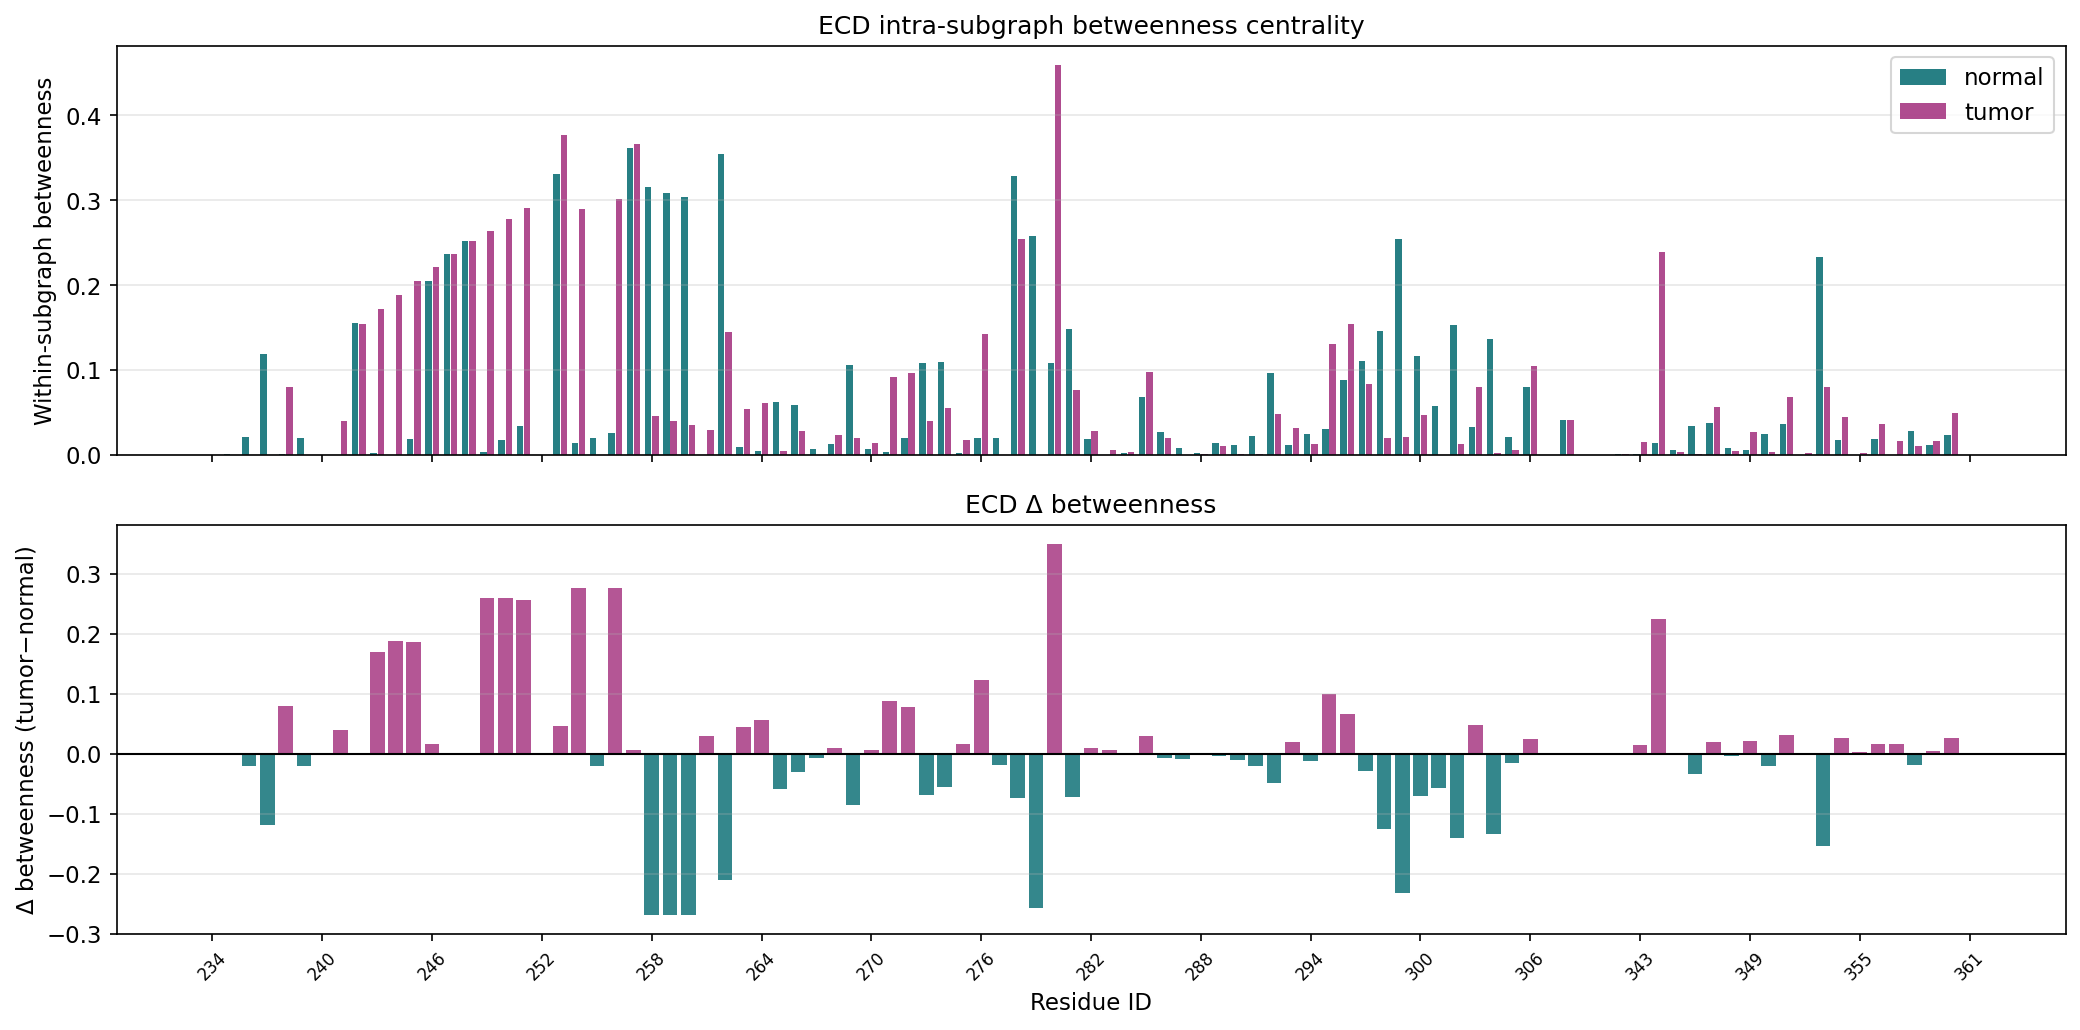

Saved fig6_ECD_subgraph_betweenness.png


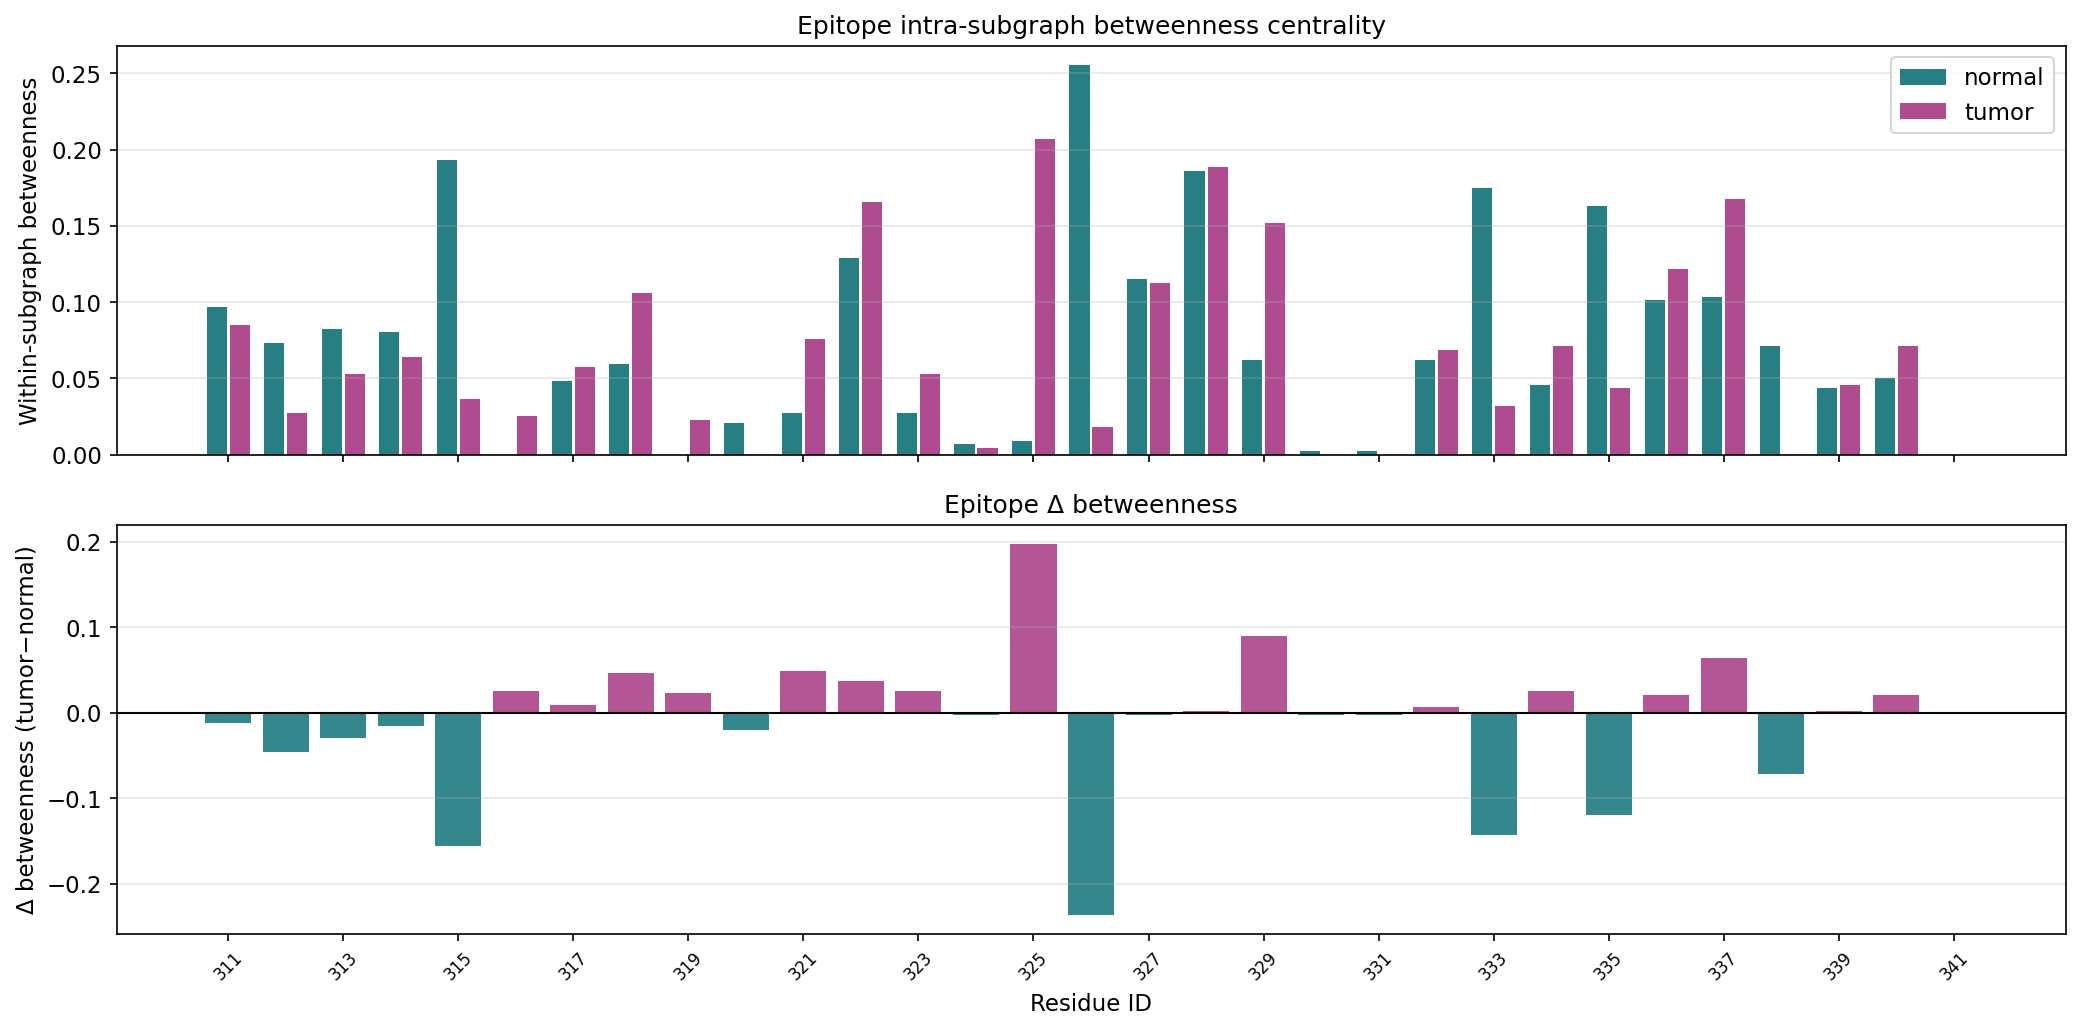

Saved fig6_epitope_subgraph_betweenness.png


In [ ]:
for region, label in [('ECD','ECD'), ('epitope','Epitope')]:
    key_n, key_t = f'{region}_normal', f'{region}_tumor'
    if key_n not in CENTRALITY_SUB or key_t not in CENTRALITY_SUB:
        print(f'Skipping {region}: no data'); continue
    csn=CENTRALITY_SUB[key_n].set_index('resid')
    cst=CENTRALITY_SUB[key_t].set_index('resid')
    shared=sorted(set(csn.index)&set(cst.index))
    bn=csn.loc[shared,'betweenness'].values
    bt=cst.loc[shared,'betweenness'].values
    delta_b=bt-bn; x=np.arange(len(shared))

    fig,axes=plt.subplots(2,1,figsize=(14,7),sharex=True)
    ax=axes[0]
    ax.bar(x-0.2,bn,0.35,color='#01696f',label='normal',alpha=0.85)
    ax.bar(x+0.2,bt,0.35,color='#a12c7b',label='tumor', alpha=0.85)
    ax.set_ylabel('Within-subgraph betweenness')
    ax.set_title(f'{label} intra-subgraph betweenness centrality'); ax.legend(); ax.grid(axis='y',alpha=0.3)

    ax=axes[1]
    ax.bar(x,delta_b,color=['#a12c7b' if d>0 else '#01696f' for d in delta_b],alpha=0.8)
    ax.axhline(0,color='black',lw=1)
    step=max(1,len(shared)//15)
    ax.set_xticks(x[::step]); ax.set_xticklabels([str(shared[i]) for i in range(0,len(shared),step)],rotation=45,fontsize=8)
    ax.set_xlabel('Residue ID'); ax.set_ylabel('Δ betweenness (tumor−normal)')
    ax.set_title(f'{label} Δ betweenness'); ax.grid(axis='y',alpha=0.3)

    plt.tight_layout()
    fname=f'fig6_{region}_subgraph_betweenness.png'
    plt.savefig(FIG_DIR/fname,dpi=300,bbox_inches='tight'); plt.show()
    print(f'Saved {fname}')


## Export all artefacts

In [ ]:
# =====================================================================
# CELL 3B-EXPORTS · save all analysis artifacts
# =====================================================================

import json
import pandas as pd
from pathlib import Path as FSPath

OUT_DIR = FSPath(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Global centrality
for cond in CONDITIONS:
    CENTRALITY[cond].to_csv(OUT_DIR / f'centrality_{cond}.csv', index=False)
DELTA_DF.to_csv(OUT_DIR / 'centrality_delta.csv', index=False)

# 2. Subgraph centrality
for key, df in CENTRALITY_SUB.items():
    df.to_csv(OUT_DIR / f'centrality_sub_{key}.csv', index=False)

# 3. Community
for cond in CONDITIONS:
    (
        pd.DataFrame([{'resid': r, 'community': c} for r, c in PARTITIONS[cond].items()])
        .sort_values('resid')
        .to_csv(OUT_DIR / f'community_{cond}.csv', index=False)
    )

# 4. Inter-region matrices
for cond in CONDITIONS:
    IR_COUNT[cond].to_csv(OUT_DIR / f'interregion_edge_count_{cond}.csv')
    IR_FREQ[cond].to_csv(OUT_DIR / f'interregion_edge_freq_{cond}.csv')
IR_COUNT_DELTA.to_csv(OUT_DIR / 'interregion_edge_count_delta.csv')
IR_FREQ_DELTA.to_csv(OUT_DIR / 'interregion_edge_freq_delta.csv')

# 5. Hotspot analyses
hotspot_df.to_csv(OUT_DIR / 'epitope_hotspots.csv', index=False)
ecd_hotspot_df.to_csv(OUT_DIR / 'ecd_hotspots.csv', index=False)

# 6. Contact profiles
pd.DataFrame({
    'resid': epitope_resids_sorted,
    'mean_freq_normal': prof_ep_n,
    'mean_freq_tumor': prof_ep_t,
    'delta': prof_ep_d
}).to_csv(OUT_DIR / 'epitope_contact_profile.csv', index=False)

pd.DataFrame({
    'resid': ecd_only_sorted,
    'mean_freq_normal': prof_ecd_n,
    'mean_freq_tumor': prof_ecd_t,
    'delta': prof_ecd_d
}).to_csv(OUT_DIR / 'ecd_contact_profile.csv', index=False)

# 7. Statistics
STAT_DF.to_csv(OUT_DIR / 'statistics_mwu_fdr.csv', index=False)

# 8. topology_stats.json
topo = {}
for cond in CONDITIONS:
    qs = QC_STATS[cond]
    topo[cond] = {
        'n_nodes': qs['n_nodes'],
        'n_edges': qs['n_edges'],
        'density': round(qs['density'], 6),
        'n_components': qs['n_components'],
        'giant_component_frac': round(qs['giant_frac'], 4),
        'n_edges_per_type': qs['edge_type_counts'],
        'modularity_louvain': round(MODULARITY[cond], 4),
    }

topo['NMI'] = round(NMI, 4)
topo['ARI'] = round(ARI, 4)

with open(OUT_DIR / 'topology_stats.json', 'w', encoding='utf-8') as f:
    json.dump(topo, f, indent=2, ensure_ascii=False)

# 9. allosteric_paths.json
# ap = {
#     cond: [
#         {
#             'src': p['src'],
#             'tgt': p['tgt'],
#             'path_resids': p['path'],
#             'length': p['length'],
#             'n_hops': p['n_hops']
#         }
#         for p in ALLOSTERIC[cond]
#     ]
#     for cond in CONDITIONS
# }
# with open(OUT_DIR / 'allosteric_paths.json', 'w', encoding='utf-8') as f:
#     json.dump(ap, f, indent=2, ensure_ascii=False)

# 10. B-factor PDB (delta betweenness)
def write_bfactor_pdb(delta_df, out_path):
    out_path = FSPath(out_path)

    req_cols = {'resid', 'betweenness'}
    missing = req_cols - set(delta_df.columns)
    if missing:
        raise ValueError(f"DELTA_DF is missing required columns: {missing}")

    df = delta_df.copy()
    df = df[['resid'] + ([c for c in ['resname'] if c in df.columns]) + ['betweenness']].copy()
    df['resid'] = pd.to_numeric(df['resid'], errors='coerce')
    df['betweenness'] = pd.to_numeric(df['betweenness'], errors='coerce')
    df = df.dropna(subset=['resid', 'betweenness']).copy()
    df['resid'] = df['resid'].astype(int)

    if 'resname' not in df.columns:
        df['resname'] = 'ALA'
    else:
        df['resname'] = df['resname'].fillna('ALA').astype(str).str.upper().str[:3]

    lines = []
    for i, row in enumerate(df.sort_values('resid').itertuples(index=False), start=1):
        resid = int(row.resid)
        rn = row.resname
        bfac = float(row.betweenness)

        lines.append(
            f"ATOM  {i:5d}  CA  {rn:>3s} A{resid:4d}    "
            f"{0.000:8.3f}{0.000:8.3f}{0.000:8.3f}"
            f"{1.00:6.2f}{bfac:6.2f}           C\n"
        )

    out_path.write_text(''.join(lines), encoding='utf-8')

write_bfactor_pdb(DELTA_DF, OUT_DIR / 'napi2b_delta_bfactor.pdb')

# 11. RING-compatible TSV
ring = []
for cond in CONDITIONS:
    ri = RESTABLE[cond].set_index('resid')

    for u, v, d in GRAPHS[cond].edges(data=True):
        rnu = ri.at[u, 'resname'] if u in ri.index and 'resname' in ri.columns else ''
        rnv = ri.at[v, 'resname'] if v in ri.index and 'resname' in ri.columns else ''

        ring.append({
            'residue_i': f'{rnu}:{u}:A',
            'residue_j': f'{rnv}:{v}:A',
            'contact_freq': round(d.get('contact_freq', 0), 5),
            'interaction_type': d.get('edge_type', ''),
            'condition': cond
        })

pd.DataFrame(ring).to_csv(OUT_DIR / 'ring_compatible.tsv', sep='\t', index=False)

print('\n=== All exports complete ===')
for fp in sorted(OUT_DIR.glob('*')):
    print(f'  {fp.name}')

# 12. Copy figures from FIG_DIR to OUT_DIR (for publication bundle)
from pathlib import Path as FSPath
import shutil

FIG_DIR = FSPath(FIG_DIR)
OUT_DIR = FSPath(OUT_DIR)

# какие расширения считаем фигурами
FIG_EXTS = {".png", ".pdf", ".svg"}

n_copied = 0
for fp in sorted(FIG_DIR.glob("*")):
    if fp.suffix.lower() in FIG_EXTS:
        dst = OUT_DIR / fp.name
        shutil.copy2(fp, dst)
        n_copied += 1

print(f"\n=== Figures copied from FIG_DIR to OUT_DIR: {n_copied} files ===")
for fp in sorted(OUT_DIR.glob("fig*.png")):
    print(f"  {fp.name}")


=== All exports complete ===
  centrality_delta.csv
  centrality_normal.csv
  centrality_sub_ECD_normal.csv
  centrality_sub_ECD_tumor.csv
  centrality_sub_epitope_normal.csv
  centrality_sub_epitope_tumor.csv
  centrality_tumor.csv
  community_normal.csv
  community_tumor.csv
  ecd_contact_map_normal.npy
  ecd_contact_map_tumor.npy
  ecd_contact_profile.csv
  ecd_hotspots.csv
  epitope_contact_map_normal.npy
  epitope_contact_map_tumor.npy
  epitope_contact_profile.csv
  epitope_hotspots.csv
  fig_temporal_rin.pdf
  fig_temporal_rin.png
  fig_temporal_rin_delta.pdf
  fig_temporal_rin_delta.png
  figures
  interregion_edge_count_delta.csv
  interregion_edge_count_normal.csv
  interregion_edge_count_tumor.csv
  interregion_edge_freq_delta.csv
  interregion_edge_freq_normal.csv
  interregion_edge_freq_tumor.csv
  napi2b_delta_bfactor.pdb
  np_contact_differential.csv
  np_contact_region.csv
  np_contact_summary.csv
  ring_compatible.tsv
  statistics_mwu_fdr.csv
  temporal_convergence.cs

## Step 11 — Upload results → Yandex Disk

In [ ]:
# Step 11. Upload Phase3B outputs → Yandex Disk

import time

YADISK_PHASE3B_ROOT    = f'disk:/{YADISK_BASE}/results/phase3B'
YADISK_PHASE3B_OUT_DIR = f'{YADISK_PHASE3B_ROOT}/phase3boutputs'
YADISK_PHASE3B_FIG_DIR = f'{YADISK_PHASE3B_ROOT}/phase3boutputs/figures'

def yadisk_ensure_dir(remote_path: str) -> None:
    '''Create remote directory and all missing parents (disk:/ path).'''
    # Split after 'disk:/'
    base = 'disk:/'
    rest = remote_path[len(base):]
    parts = rest.split('/')
    for i in range(1, len(parts) + 1):
        partial = base + '/'.join(parts[:i])
        try:
            if not client.exists(partial):
                client.mkdir(partial)
        except Exception:
            pass  # might already exist or be root

def yadisk_upload(local_path: Path, remote_path: str, overwrite: bool = True) -> None:
    t0 = time.time()
    client.upload(str(local_path), remote_path, overwrite=overwrite)
    dt = time.time() - t0
    size_mb = local_path.stat().st_size / 1024**2
    print(f'  ok  {local_path.name:<50s}  {size_mb:.2f} MB  {dt:.1f} s')

# Ensure remote directories exist
for remote_dir in [YADISK_PHASE3B_ROOT, YADISK_PHASE3B_OUT_DIR, YADISK_PHASE3B_FIG_DIR]:
    yadisk_ensure_dir(remote_dir)
    print(f'  dir  {remote_dir}')

# Collect files: CSV, NPY, JSON, PDB, TSV from OUT_DIR + PNG from FIG_DIR
files_to_upload = []
for ext in ['.csv', '.npy', '.json', '.pdb', '.tsv']:
    files_to_upload += list(OUT_DIR.glob(f'*{ext}'))
files_to_upload += list(FIG_DIR.glob('*.png'))

if not files_to_upload:
    print('No output files found — run Steps 1–10 first.')
else:
    uploaded = []; failed = []

    for local_file in sorted(files_to_upload):
        if local_file.parent == FIG_DIR:
            remote_file = f'{YADISK_PHASE3B_FIG_DIR}/{local_file.name}'
        else:
            remote_file = f'{YADISK_PHASE3B_OUT_DIR}/{local_file.name}'

        try:
            yadisk_upload(local_file, remote_file, overwrite=True)
            uploaded.append(local_file.name)
        except Exception as e:
            print(f'  ERROR  {local_file.name}: {e}')
            failed.append(local_file.name)

    print('=' * 60)
    print('PHASE3B UPLOAD SUMMARY')
    print('=' * 60)
    print(f'  Uploaded : {len(uploaded)}')
    print(f'  Failed   : {len(failed)}')
    if failed:
        print('  Failed files:')
        for f in failed: print(f'    - {f}')
    print()
    print(f'  Yandex Disk path: {YADISK_PHASE3B_OUT_DIR}')

  dir  disk:/NAPI2B-ST-GNN/results/phase3B
  dir  disk:/NAPI2B-ST-GNN/results/phase3B/phase3boutputs
  dir  disk:/NAPI2B-ST-GNN/results/phase3B/phase3boutputs/figures
  ok  centrality_delta.csv                                0.08 MB  3.1 s
  ok  centrality_normal.csv                               0.05 MB  2.6 s
  ok  centrality_sub_ECD_normal.csv                       0.00 MB  2.2 s
  ok  centrality_sub_ECD_tumor.csv                        0.00 MB  2.1 s
  ok  centrality_sub_epitope_normal.csv                   0.00 MB  2.1 s
  ok  centrality_sub_epitope_tumor.csv                    0.00 MB  2.9 s
  ok  centrality_tumor.csv                                0.05 MB  2.6 s
  ok  community_normal.csv                                0.00 MB  2.2 s
  ok  community_tumor.csv                                 0.00 MB  2.0 s
  ok  ecd_contact_map_normal.npy                          0.06 MB  2.7 s
  ok  ecd_contact_map_tumor.npy                           0.06 MB  2.5 s
  ok  ecd_contact_profile.csv 